In [1]:
SUPER = False

if (SUPER): 
    import matplotlib
    matplotlib.use('Agg')

What is left: 
* Investigate VisDrone
* Get printer specs, set DPI and gamut values in CONFIG
* Create printer Gamut.numpy
* Add more diverse models to blackbox: RT-DETR, YOLO-NAS, or a Faster R-CNN

# CloakHat Patch Generation Pipeline

## 1: Conda Setup

* Conda is the main env manager, pip is for Python packages
* PyTorch is the main AI/ML library
* NVIDIA CUDA is for GPU acceleration
* PyTorch3D is for rendering the hat
* ipykernel allows JupyterLab to use the Conda env
* Ultralytics has YOLO models
* opencv-python-headless is for image processing
* matplotlib is for plots
* tqdm is for progress bars
* NumPy is for data manipulation

### Option 1:

Activate <br>
`conda env create -f environment.yaml` <br>
`conda activate cloakhat` <br>

Apply the kernel <br>
`python -m ipykernel install --user --name cloakhat --display-name "Python (cloakhat)"`

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

### Option 2: 

Set up the environment

`conda create -n cloakhat python=3.10 -y` <br>
`conda activate cloakhat`

PyTorch with CUDA. Also ipykernel. <br>
`conda install pytorch ipykernel pytorch-cuda=11.8 -c pytorch -c nvidia -y`<br>

PyTorch3D for differentiable rendering <br>
`conda install -c pytorch3d pytorch3d -y`

Detection models <br>
`pip install ultralytics`

Other stuff <br>
`pip install opencv-python-headless matplotlib tqdm numpy sahi pandas reportlab`

Apply the kernel <br>
`python -m ipykernel install --user --name cloakhat --display-name "Python (cloakhat)"`

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

### Option 3: 

Run the bash <br>
`bash LabSetup.sh`

Activate the kernel <br>
`conda activate cloakhat` <br>

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

## 2: Python Setup

Get the libraries we need

In [2]:
#Deep learning stuff
import torch
import torch.nn as nn
import torch.nn.functional as F

#Data manipulation
import numpy as np

#Image processing
import cv2

#Plotting
import matplotlib.pyplot as plt

#Working with the file system
from pathlib import Path

#Progress bars
from tqdm import tqdm

#Better logging than print statements
import logging

#JSON utilities
import json

#PyTorch3d utilities
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (look_at_view_transform, FoVPerspectiveCameras, RasterizationSettings, MeshRasterizer, SoftPhongShader, TexturesUV, PointLights)

#Gets YOLO models
from ultralytics import YOLO

#Logging with timestamps
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(message)s')
logger = logging.getLogger(__name__)

#Check what device is being used (especially if we want GPU) and log it
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Device: {device}")

2026-03-29 22:48:33,116 | Device: cuda


## 3: Config

Control variables

In [20]:
CONFIG = {
    'dataset_dir': './data8/drone_footage', #Drone footage/image samples
    'output_dir': './outputs9', #Where out outputs will go (textures, evaluations, stuff like that)
    
    'mesh_path': './assets/Bucket_Hat.obj', #Hat mesh
    'sweater_mesh_path': './assets/Sweater.obj', #Sweater mesh
    'mannequin_facing_degrees': 0.0, #Where it is facing. Was 0.0
    
    #Generator
    'latent_channels': 128, #Channels
    'latent_size': 9, #Spatial size of latent input
    #(so the latent is 128x9x9)
    'texture_size': 288, #Output texture size from generator
    #(so the latent becomes a texture that is 3x288x288)
    
    #Viewpoint sampling
    'scale_jitter': 0.1, #Fraction of scale variation
    'hat_heading_jitter': 180,
    'hat_pitch_jitter': 5.0,
    'sweater_heading_jitter': 15,
    'sweater_pitch_jitter': 3.0,

    'num_workers': 4, #for DataLoader
    'det_conf_floor': 0.001, #Minimum confidence for detector loss
    
    #Training Stage 1
    #'stage1_epochs': 150, #100 epochs
    'stage1_batch_size': 4, #8 batch minibatch gradient descent
    'stage1_lr': 2e-4, #learning rate
    
    #Training Stage 2  
    'stage2_batch_size': 4,
    #'stage2_iterations': 10000, #Now we optimize the single tensor
    'stage2_lr': 0.005, #Bigger learning rate
    'stage2_generator_lr': 5e-5,
    'local_latent_size': 9, #Size of optimizable latent pattern. Bigger than 9x9 (input), so tile seamlessly
    
    #Loss weights
    'lambda_tv': 0.1, #Total variation - makes the textures smoother/less noisy/able to be printed
    'lambda_nps': 0.01, #Non-printability score - penalize colors that can't print well
    'lambda_info': 0.5, #Mutual information (Stage 1 only) - ensures latent is correlated to the texture
    
    #T-SEA Stuff
    'cutout_prob': 0.5, #90% of the time, 
    'cutout_ratio': 0.15, #cut off 40% of the hat
    'shakedrop_prob': 0.5, #50% of the time, mess with the model (for self-ensemble)
    
    #Rendering
    'render_size': 512, #Output 256x256 images
    'image_size': 1920, #Standardized input image size for all frames
    'detector_input_size': 640,
    
    #Printer specifications (GET FROM FABLAB)
    'printer': {
        'dpi': 300,
        #'mesh_unit_to_inches': None, #CALIBRATE: how many inches = 1 unit in the .obj file. None to auto-estimate.
        'hat_mesh_unit_to_inches': 11.006,
        'sweater_mesh_unit_to_inches': 28.0,
        'seam_allowance_inches': 0.25, #Extra border for cutting
        'max_saturation': 0.85,
        'max_brightness': 0.95,
        'min_brightness': 0.08,
        'nps_threshold': 0.70, #Saturation * brightness threshold (penalize when saturation × brightness > 0.7)
        'gamut_samples_path': './assets/printer_gamut.npy',
    },
    
    #Attack config (white, gray, black)
    'attack_mode': 'white',
    'visdrone_model_path': 'runs/detect/yolov8m-visdrone/weights/best.pt',

    #SAHI evaluation settings
    'sahi_slice_size': 960,
    'sahi_overlap': 0.3,
    'sahi_train_configs': [
        {'slice': 640,  'overlap': 0.15},
        {'slice': 768,  'overlap': 0.20},
        {'slice': 960,  'overlap': 0.15},
        {'slice': 960,  'overlap': 0.30},
        {'slice': 1920, 'overlap': 0.0},   #fullframe
    ],

    #Interleaved training phases
    'training_phases': [
        {'bn_size': 128, 's1_epochs': 1, 's2_iters': 1},
        #{'bn_size': 64,  's1_epochs': 50, 's2_iters': 5000},
        #{'bn_size': 96,  's1_epochs': 50, 's2_iters': 5000},
        #{'bn_size': 128, 's1_epochs': 50, 's2_iters': 5000},
    ],
    
    #Deployment ensemble
    'deployment_ensemble': [
        {'model': 'yolov8m', 'pipeline': 'fullframe'},
        #{'model': 'yolov8m', 'pipeline': 'sahi', 'slice': 1280, 'overlap': 0.15},
        #{'model': 'yolov8m', 'pipeline': 'sahi', 'slice': 960,  'overlap': 0.15},
    ],

    #My trick
    'freq_bottleneck': {
        'stage1': [(0, 64), (50, 96), (100, 128)],  #(start_epoch, size)
        'stage2': 128,
    },

    #Train test split
    'test_split': 0.2, 
}

if (SUPER):
    CONFIG['num_workers'] = 6
    CONFIG['stage1_batch_size'] = 4
    CONFIG['stage2_batch_size'] = 4
    #CONFIG['stage2_iterations'] = 15000

#Make sure the folder exists
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)

## 4: Dataset Preparation

Prepare the dataset

2026-03-29 22:48:33,366 | Loaded 3265 frames from ./data8/drone_footage (split=train)
2026-03-29 22:48:33,431 | Loaded 816 frames from ./data8/drone_footage (split=test)
2026-03-29 22:48:33,495 | Loaded 4081 frames from ./data8/drone_footage (split=all)
2026-03-29 22:48:33,496 | Train: 3265, Test: 816, All: 4081
2026-03-29 22:48:33,497 | Dataset composition:
2026-03-29 22:48:33,501 |   Train (3265 frames):
2026-03-29 22:48:33,502 |     sand: 1927 (59.0%)
2026-03-29 22:48:33,503 |     snow: 1338 (41.0%)
2026-03-29 22:48:33,506 |     distance: 2.1–15.5m (mean=7.5m, median=6.9m)
2026-03-29 22:48:33,507 |     bins: 2-5m:1007, 5-8m:984, 8-12m:790, 12-20m:484
2026-03-29 22:48:33,509 |   Test (816 frames):
2026-03-29 22:48:33,510 |     sand: 464 (56.9%)
2026-03-29 22:48:33,511 |     snow: 352 (43.1%)
2026-03-29 22:48:33,512 |     distance: 2.1–15.4m (mean=7.4m, median=6.8m)
2026-03-29 22:48:33,513 |     bins: 2-5m:248, 5-8m:255, 8-12m:198, 12-20m:115
2026-03-29 22:48:33,516 |   All (4081 fram

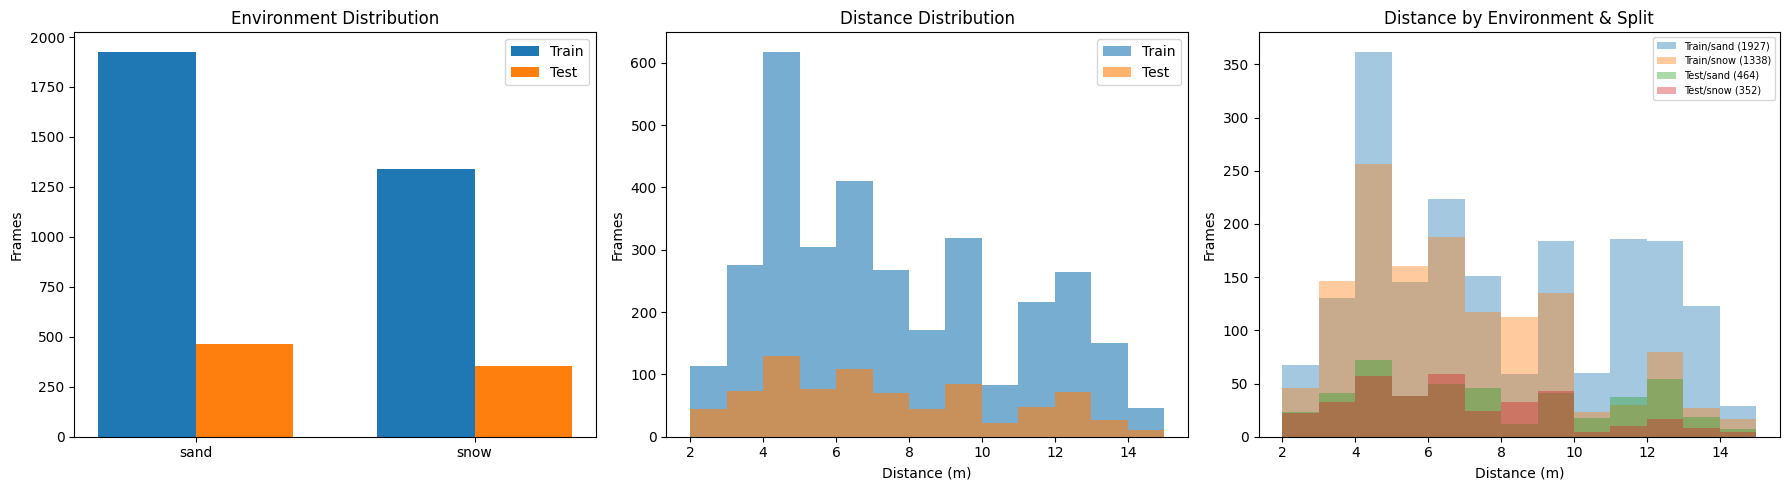

2026-03-29 22:48:35,251 | Saved dataset_composition.png


In [4]:
class DroneDataset(torch.utils.data.Dataset):

    def __init__(self, dataset_dir, split='all', test_ratio=0.2, seed=42):

        #Figure out the file paths and directories
        self.dataset_dir = Path(dataset_dir)
        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")
        annotations_path = self.dataset_dir / 'annotations.json'
        if not annotations_path.exists():
            raise FileNotFoundError(f"Missing annotations.json in {dataset_dir}")
        with open(annotations_path) as f:
            self.annotations = json.load(f)

        #Train/test split (deterministic)
        all_frames = self.annotations['frames']
        rng = np.random.RandomState(seed)
        indices = rng.permutation(len(all_frames))
        n_test = int(len(all_frames) * test_ratio)
        test_indices = set(indices[:n_test])
        train_indices = set(indices[n_test:])
        if split == 'train':
            self.frames = [all_frames[i] for i in sorted(train_indices)]
        elif split == 'test':
            self.frames = [all_frames[i] for i in sorted(test_indices)]
        else:
            self.frames = all_frames
        self.length = len(self.frames)
        
        #Distance-to-scale (replaces altitude_to_scale)
        #Falls back to altitude_to_scale for backward compatibility
        meta = self.annotations['metadata']
        if 'distance_to_scale' in meta:
            d = meta['distance_to_scale']
            self.dist_min = d['min_distance']
            self.dist_max = d['max_distance']
            self.scale_min = d['min_scale']
            self.scale_max = d['max_scale']
        else:
            a = meta['altitude_to_scale']
            self.dist_min = a['min_altitude']
            self.dist_max = a['max_altitude']
            self.scale_min = a['min_scale']
            self.scale_max = a['max_scale']
        
        logger.info(f"Loaded {self.length} frames from {dataset_dir} (split={split})")

    def _distance_to_scale(self, distance_3d):
        #Linear interpolation
        t = (distance_3d - self.dist_min) / (self.dist_max - self.dist_min + 1e-8)
        t = np.clip(t, 0, 1)
        return self.scale_max - t * (self.scale_max - self.scale_min)
    
    @staticmethod
    def _letterbox(tensor, target_size, pad_value=0.5):
        #Resize without distorting it. Fit for image detection
        C, H, W = tensor.shape
        scale = target_size / max(H, W)
        new_h, new_w = int(H * scale), int(W * scale)
        resized = F.interpolate(tensor.unsqueeze(0), size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)
        pad_h = target_size - new_h
        pad_w = target_size - new_w
        top = pad_h // 2
        left = pad_w // 2
        padded = torch.full((C, target_size, target_size), pad_value, dtype=tensor.dtype)
        padded[:, top:top+new_h, left:left+new_w] = resized
        return padded, scale, top, left

    @staticmethod
    def _letterbox_nearest(tensor, target_size, pad_value=0.0):
        #Same thing but nearest neighbor interpolation instead of bilinear
        C, H, W = tensor.shape
        scale = target_size / max(H, W)
        new_h, new_w = int(H * scale), int(W * scale)
        resized = F.interpolate(tensor.unsqueeze(0), size=(new_h, new_w), mode='nearest').squeeze(0)
        pad_h = target_size - new_h
        pad_w = target_size - new_w
        top = pad_h // 2
        left = pad_w // 2
        padded = torch.full((C, target_size, target_size), pad_value, dtype=tensor.dtype)
        padded[:, top:top+new_h, left:left+new_w] = resized
        return padded, scale, top, left

    def __len__(self):
        return self.length

    def get_original_data(self, idx):
        frame = self.frames[idx]
        image = cv2.imread(str(self.dataset_dir / frame['image_path']))
        if image is None:
            raise FileNotFoundError(f"Cannot read {self.dataset_dir / frame['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        hat_mask_key = frame.get('hat_mask_path', frame.get('mask_path', ''))
        if hat_mask_key and (self.dataset_dir / hat_mask_key).is_file():
            hm = cv2.imread(str(self.dataset_dir / hat_mask_key), cv2.IMREAD_GRAYSCALE)
            hat_mask = torch.from_numpy(hm).unsqueeze(0).float() / 255.0
        else:
            hat_mask = torch.zeros(1, orig_h, orig_w)
        
        sw_key = frame.get('sweater_mask_path', '')
        if sw_key and (self.dataset_dir / sw_key).is_file():
            sm = cv2.imread(str(self.dataset_dir / sw_key), cv2.IMREAD_GRAYSCALE)
            sweater_mask = torch.from_numpy(sm).unsqueeze(0).float() / 255.0
        else:
            sweater_mask = torch.zeros(1, orig_h, orig_w)
        
        person_bbox = torch.tensor(frame['person_bbox'], dtype=torch.float32)
        return image, hat_mask, sweater_mask, person_bbox
    
    def __getitem__(self, idx):

        #Load image and rotate because it is wrong for some reason idk
        frame = self.frames[idx]
        image = cv2.imread(str(self.dataset_dir / frame['image_path']))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        stored_h, stored_w = image.shape[:2]
        #image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE) #REMOVE IF DON'T ROTATE
        orig_h, orig_w = image.shape[:2]

        #Convert it
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        target_size = CONFIG['image_size']
        
        #Letterbox not squash preserves aspect ratio
        image, scale, pad_top, pad_left = self._letterbox(image, target_size)
        
        #Load hat mask
        hat_mask_key = frame.get('hat_mask_path', frame.get('mask_path', ''))
        hat_mask = cv2.imread(str(self.dataset_dir / hat_mask_key), cv2.IMREAD_GRAYSCALE)
        if hat_mask is None:
            hat_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        else:
            pass
            #hat_mask = cv2.rotate(hat_mask, cv2.ROTATE_90_COUNTERCLOCKWISE) #REMOVE IF DON'T ROTATE
        hat_mask = torch.from_numpy(hat_mask).unsqueeze(0).float() / 255.0
        hat_mask, _, _, _ = self._letterbox_nearest(hat_mask, target_size, pad_value=0.0)
        
        #Load sweater mask
        sweater_mask_key = frame.get('sweater_mask_path', '')
        if sweater_mask_key and (self.dataset_dir / sweater_mask_key).exists():
            sweater_mask = cv2.imread(str(self.dataset_dir / sweater_mask_key), cv2.IMREAD_GRAYSCALE)
            #sweater_mask = cv2.rotate(sweater_mask, cv2.ROTATE_90_COUNTERCLOCKWISE)  #REMOVE IF DON'T ROTATE
            sweater_mask = torch.from_numpy(sweater_mask).unsqueeze(0).float() / 255.0
            sweater_mask, _, _, _ = self._letterbox_nearest(sweater_mask, target_size, pad_value=0.0)
        else:
            sweater_mask = torch.zeros(1, target_size, target_size)

        #Bounding box transformations because it is still wrong
        raw_bbox = frame['person_bbox']
        """ 
        #90 CCW rotation #REMOVE IF DON'T ROTATE
        person_bbox = torch.tensor([
            raw_bbox[1],
            stored_w - raw_bbox[2],
            raw_bbox[3],
            stored_w - raw_bbox[0],
        ], dtype=torch.float32)
        """
        person_bbox = torch.tensor(raw_bbox, dtype=torch.float32)
        person_bbox[0] = person_bbox[0] * scale + pad_left
        person_bbox[1] = person_bbox[1] * scale + pad_top
        person_bbox[2] = person_bbox[2] * scale + pad_left
        person_bbox[3] = person_bbox[3] * scale + pad_top
        
        #Viewpoint extraction
        drone = frame['drone']
        elevation = drone['camera_pitch']
        #Keep azimuth for backward compatibility (diagnostic grid)
        raw_bearing = drone.get('heading', 0.0)
        mannequin_facing = CONFIG.get('mannequin_facing_degrees', 0.0)
        azimuth = (raw_bearing - mannequin_facing) % 360
        
        #Scale from 3D distance
        distance_3d = drone.get('distance_3d_meters', drone.get('altitude_meters', 5.0))
        lateral_distance = drone.get('lateral_distance_meters', 0.0)
        scale_val = self._distance_to_scale(distance_3d)
        
        #Usability flags
        hat_usable = frame.get('hat_usable', True)
        sweater_usable = frame.get('sweater_usable', False)

        #Return dictionary
        return {
            'dataset_idx': idx,
            'image': image,
            'hat_mask': hat_mask,
            'sweater_mask': sweater_mask,
            'hat_usable': hat_usable,
            'sweater_usable': sweater_usable,
            'person_bbox': person_bbox,
            'elevation': torch.tensor(elevation, dtype=torch.float32),
            'azimuth': torch.tensor(azimuth, dtype=torch.float32),
            'scale': torch.tensor(scale_val, dtype=torch.float32),
            'distance_3d': torch.tensor(distance_3d, dtype=torch.float32),
            'gimbal_yaw': torch.tensor(drone.get('gimbal_yaw_360', 0.0), dtype=torch.float32),
            'bearing': torch.tensor(raw_bearing, dtype=torch.float32),
            'gimbal_pitch_raw': torch.tensor(drone.get('gimbal_pitch_raw', -elevation), dtype=torch.float32),
        }

#Create datasets
dataset_train = DroneDataset(CONFIG['dataset_dir'], split='train', test_ratio=CONFIG['test_split'])
dataset_test = DroneDataset(CONFIG['dataset_dir'], split='test', test_ratio=CONFIG['test_split'])
dataset_all = DroneDataset(CONFIG['dataset_dir'], split='all')
logger.info(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, All: {len(dataset_all)}")

def log_dataset_stats(dataset, label='Dataset'):
    envs = {}
    distances = []
    for frame in dataset.frames:
        env = frame.get('environment', 'unknown')
        envs[env] = envs.get(env, 0) + 1
        d = frame['drone'].get('distance_3d_meters', frame['drone'].get('altitude_meters', 0))
        distances.append(d)
    
    distances = np.array(distances)
    logger.info(f"  {label} ({len(dataset)} frames):")
    for env, count in sorted(envs.items()):
        logger.info(f"    {env}: {count} ({count/len(dataset):.1%})")
    logger.info(f"    distance: {distances.min():.1f}–{distances.max():.1f}m "
                f"(mean={distances.mean():.1f}m, median={np.median(distances):.1f}m)")
    
    #Distance bins
    bins = [(2, 5), (5, 8), (8, 12), (12, 20)]
    parts = []
    for lo, hi in bins:
        n = ((distances >= lo) & (distances < hi)).sum()
        parts.append(f"{lo}-{hi}m:{n}")
    logger.info(f"    bins: {', '.join(parts)}")
    
    return envs, distances

logger.info("Dataset composition:")
train_envs, train_dists = log_dataset_stats(dataset_train, 'Train')
test_envs, test_dists = log_dataset_stats(dataset_test, 'Test')
_ = log_dataset_stats(dataset_all, 'All')

if not SUPER:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    #Environment bar chart
    all_envs = sorted(set(list(train_envs.keys()) + list(test_envs.keys())))
    x = np.arange(len(all_envs))
    w = 0.35
    axes[0].bar(x - w/2, [train_envs.get(e, 0) for e in all_envs], w, label='Train')
    axes[0].bar(x + w/2, [test_envs.get(e, 0) for e in all_envs], w, label='Test')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(all_envs)
    axes[0].set_ylabel('Frames')
    axes[0].set_title('Environment Distribution')
    axes[0].legend()
    
    #Distance histogram
    dist_bins = np.arange(2, 16, 1.0)
    axes[1].hist(train_dists, bins=dist_bins, alpha=0.6, label='Train')
    axes[1].hist(test_dists, bins=dist_bins, alpha=0.6, label='Test')
    axes[1].set_xlabel('Distance (m)')
    axes[1].set_ylabel('Frames')
    axes[1].set_title('Distance Distribution')
    axes[1].legend()
    
    #Distance by environment
    for split_label, dataset in [('Train', dataset_train), ('Test', dataset_test)]:
        for env in all_envs:
            dists = [f['drone'].get('distance_3d_meters', f['drone'].get('altitude_meters', 0))
                     for f in dataset.frames if f.get('environment', 'unknown') == env]
            if dists:
                axes[2].hist(dists, bins=dist_bins, alpha=0.4,
                           label=f'{split_label}/{env} ({len(dists)})')
    axes[2].set_xlabel('Distance (m)')
    axes[2].set_ylabel('Frames')
    axes[2].set_title('Distance by Environment & Split')
    axes[2].legend(fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/dataset_composition.png", dpi=150, bbox_inches='tight')
    plt.show()
    logger.info("Saved dataset_composition.png")

## 5: FCN Generator

Make the texture (turn noise into an image)

In [5]:
class FCNGenerator(nn.Module):

    def __init__(self, latent_channels=128, latent_size=9):
        super().__init__()
        self.latent_size = latent_size

        #Core network, upsample throughout, zero padding for invaraince, and LeakyReLU activation
        self.net = nn.Sequential(
            #9 -> 9
            nn.Conv2d(latent_channels, 512, 3, 1, 1, padding_mode='zeros'),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),     
            #9 -> 18
            nn.ConvTranspose2d(512, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            #18 -> 36
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            #36 -> 72
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            #72 -> 144
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            #144 -> 288
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            #288 -> 288 (to RGB)
            nn.Conv2d(32, 3, 3, 1, 1, padding_mode='zeros'),
            nn.Tanh() #Squash
        )
        self.output_size = 288
        self._init_weights()

    #Initialize the weights
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, a=0.2, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    #Standard forward method
    def forward(self, z):
        return self.net(z)

    #Create random noise for testing
    def generate(self, z=None, batch_size=1):
        if z is None:
            z = torch.randn(batch_size, self.net[0].in_channels, self.latent_size, self.latent_size, device=next(self.parameters()).device)
        return (self.forward(z) + 1) / 2

#Test
generator_hat = FCNGenerator(latent_channels=CONFIG['latent_channels'], latent_size=CONFIG['latent_size']).to(device)
generator_sweater = FCNGenerator(latent_channels=CONFIG['latent_channels'], latent_size=CONFIG['latent_size']).to(device)
test_hat_tex = generator_hat.generate(batch_size=1)
test_sweater_tex = generator_sweater.generate(batch_size=1)
assert test_hat_tex.shape[-1] == CONFIG['texture_size']
assert test_sweater_tex.shape[-1] == CONFIG['texture_size']
logger.info(f"Hat generator output: {test_hat_tex.shape}")
logger.info(f"Sweater generator output: {test_sweater_tex.shape}")

2026-03-29 22:48:36,033 | Hat generator output: torch.Size([1, 3, 288, 288])
2026-03-29 22:48:36,034 | Sweater generator output: torch.Size([1, 3, 288, 288])


## 6: Auxiliary Network

Forces the texture to derive from the latent (JSD MINE)

In [6]:
class AuxiliaryNetwork(nn.Module):
    
    def __init__(self, latent_channels=128):
        super().__init__()
        
        #Texture encoder
        self.tex_enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        
        #Latent encoder
        self.lat_enc = nn.Sequential(
            nn.Conv2d(latent_channels, 256, 3, 1, 1),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        
        #Joint network
        self.joint = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
        
    def forward(self, texture, z):
        tex_feat = self.tex_enc(texture)
        lat_feat = self.lat_enc(z)
        return self.joint(torch.cat([tex_feat, lat_feat], dim=1))

def compute_mi_loss(aux_net, texture, z):
    #Matched pairs
    T_joint = aux_net(texture, z)
    pos_term = -F.softplus(-T_joint).mean()
    #Mismatched pairs (shuffle z)
    z_shuffle = z[torch.randperm(z.size(0))]
    T_marginal = aux_net(texture, z_shuffle)
    neg_term = F.softplus(T_marginal).mean()
    mi = pos_term - neg_term
    #MI >= E_joint[-softplus(-T)] - E_marginal[softplus(T)]
    return -mi  #Negate because we minimize loss but want to maximize MI

## 7: Render Hat

Render the hat using the texture and capture angle

In [7]:
class HatRenderer:
    
    def __init__(self, mesh_path, render_size=256, device='cuda'):
        self.device = device
        self.render_size = render_size
        self.training_mode = False
        self.mesh_loaded = False

        #Load mesh - getting the verts, faces, and uv mappings
        if Path(mesh_path).exists():
            verts, faces, aux = load_obj(mesh_path, device=device)
            center = (verts.max(0)[0] + verts.min(0)[0]) / 2
            verts = verts - center
            max_extent = (verts.max(0)[0] - verts.min(0)[0]).max()
            verts = verts / max_extent  #now fits in [-0.5, 0.5] normalize

            #Rotate 90 degrees across the Y axis
            import math as _math
            rot_rad = 105 * _math.pi / 180.0 #70->90
            cos_r, sin_r = _math.cos(rot_rad), _math.sin(rot_rad)
            rot_mat = torch.tensor([
                [cos_r, 0, sin_r],
                [0, 1, 0],
                [-sin_r, 0, cos_r]
            ], dtype=torch.float32, device=device)
            verts = verts @ rot_mat.T

            #Key components
            self.verts = verts
            self.faces = faces.verts_idx
            self.verts_uvs = aux.verts_uvs
            self.faces_uvs = faces.textures_idx
            self.mesh_loaded = True
            logger.info(f"Loaded mesh: {len(verts)} verts, {len(self.faces)} faces (normalized from {max_extent:.1f} units)")
        else:
            #Use the placeholder
            logger.warning(f"Mesh not found at {mesh_path}. Using placeholder.")
            self._create_placeholder_mesh()
            
        #Rasterization settings
        self.raster_settings = RasterizationSettings(image_size=render_size,  blur_radius=0, faces_per_pixel=1)
        #Create rasterizer once
        self.rasterizer = MeshRasterizer(raster_settings=self.raster_settings)

    #Make a placeholder if we don't have a mesh which is a disk. THIS WAS MADE WITH THE HELP OF AI
    def _create_placeholder_mesh(self):
        #Simple disk
        n_points = 32
        angles = torch.linspace(0, 2*np.pi, n_points+1)[:-1]
        #Vertices: center + rim
        verts = [[0, 0, 0]]  #center
        for a in angles:
            verts.append([torch.cos(a).item(), torch.sin(a).item(), 0])
        self.verts = torch.tensor(verts, dtype=torch.float32, device=self.device)
        #Faces: triangles from center to rim
        faces = []
        for i in range(n_points):
            faces.append([0, i + 1, (i + 1) % n_points + 1])
        self.faces = torch.tensor(faces, dtype=torch.int64, device=self.device)
        #UVs: simple radial mapping
        uvs = [[0.5, 0.5]]  #center
        for a in angles:
            uvs.append([0.5 + 0.5*torch.cos(a).item(), 0.5 + 0.5*torch.sin(a).item()])
        self.verts_uvs = torch.tensor(uvs, dtype=torch.float32, device=self.device)
        self.faces_uvs = self.faces.clone()
        self.mesh_loaded = True

    #Now we render the texture on the hat
    def render(self, texture, elevation=90, azimuth=0, scale=1.0, gimbal_yaw=None, bearing=None, gimbal_pitch=None):
        batch_size = texture.shape[0]
        
        #Scale mesh vertices
        if isinstance(scale, (int, float)):
            verts = self.verts * scale
            verts_list = [verts] * batch_size
        elif isinstance(scale, torch.Tensor) and scale.dim() == 0:
            verts = self.verts * scale.item()
            verts_list = [verts] * batch_size
        else:
            verts_list = [self.verts * s.item() for s in scale]
        
        dist = 2.5
        #Get the camera drone telemetry
        if bearing is not None and gimbal_yaw is not None:
            if not isinstance(bearing, torch.Tensor):
                bearing = torch.tensor([bearing], device=self.device, dtype=torch.float32).expand(batch_size)
            elif bearing.dim() == 0:
                bearing = bearing.unsqueeze(0).expand(batch_size)
            if not isinstance(gimbal_yaw, torch.Tensor):
                gimbal_yaw = torch.tensor([gimbal_yaw], device=self.device, dtype=torch.float32).expand(batch_size)
            elif gimbal_yaw.dim() == 0:
                gimbal_yaw = gimbal_yaw.unsqueeze(0).expand(batch_size)
            if not isinstance(elevation, torch.Tensor):
                elevation = torch.tensor([elevation], device=self.device, dtype=torch.float32).expand(batch_size)
            elif elevation.dim() == 0:
                elevation = elevation.unsqueeze(0).expand(batch_size)

            #Convert spherical cordinates to 3D eye position
            brg_rad = bearing * (3.14159265 / 180.0)
            elev_rad = elevation * (3.14159265 / 180.0)
            gy_rad = gimbal_yaw * (3.14159265 / 180.0)
            eye_x = dist * torch.cos(elev_rad) * torch.sin(brg_rad)
            eye_y = dist * torch.sin(elev_rad)
            eye_z = -dist * torch.cos(elev_rad) * torch.cos(brg_rad)
            eye = torch.stack([eye_x, eye_y, eye_z], dim=1)

            #Get more drone telemetry
            if gimbal_pitch is not None:
                if not isinstance(gimbal_pitch, torch.Tensor):
                    gimbal_pitch = torch.tensor([gimbal_pitch], device=self.device, dtype=torch.float32).expand(batch_size)
                elif gimbal_pitch.dim() == 0:
                    gimbal_pitch = gimbal_pitch.unsqueeze(0).expand(batch_size)
                gp_rad = gimbal_pitch * (3.14159265 / 180.0)
            else:
                gp_rad = torch.tensor([-3.14159265/2], device=self.device).expand(batch_size)

            #Build a rotation matrix using linear algebra. R Rotation T Translation. More accurate than fallback
            sin_gy = torch.sin(gy_rad)
            cos_gy = torch.cos(gy_rad)
            sin_gp = torch.sin(gp_rad)
            cos_gp = torch.cos(gp_rad)
            zeros = torch.zeros_like(sin_gy)
            R = torch.zeros(batch_size, 3, 3, device=self.device)
            R[:, 0, 0] = -cos_gy
            R[:, 0, 1] = zeros
            R[:, 0, 2] = -sin_gy
            R[:, 1, 0] = -sin_gp * sin_gy
            R[:, 1, 1] = cos_gp
            R[:, 1, 2] = sin_gp * cos_gy
            R[:, 2, 0] = cos_gp * sin_gy
            R[:, 2, 1] = sin_gp
            R[:, 2, 2] = -cos_gp * cos_gy
            R = R.transpose(1, 2)
            T = -torch.bmm(eye.unsqueeze(1), R).squeeze(1)
            
        else:
            #Fallback: spherical coordinates (for diagnostic grids)
            if not isinstance(elevation, torch.Tensor):
                elevation = torch.tensor([elevation], device=self.device).expand(batch_size)
                azimuth = torch.tensor([azimuth], device=self.device).expand(batch_size)
            elif elevation.dim() == 0:
                elevation = elevation.unsqueeze(0).expand(batch_size)
                azimuth = azimuth.unsqueeze(0).expand(batch_size)
            R, T = look_at_view_transform(dist=dist, elev=elevation, azim=azimuth, device=self.device)

        #Define camera and FOV
        cameras = FoVPerspectiveCameras(R=R, T=T, fov=82, device=self.device)

        #If we are in training mode, we use a straightforward light; otherwise, we use a randomized one for robustness.
        if self.training_mode:
            light_x = np.random.uniform(-1, 1)
            light_y = np.random.uniform(1, 3)
            light_z = np.random.uniform(-1, 1)
            lights = PointLights(device=self.device,location=[[light_x, light_y, light_z]],ambient_color=[[0.5, 0.5, 0.5]],diffuse_color=[[0.3, 0.3, 0.3]],specular_color=[[0.2, 0.2, 0.2]])
        else:
            lights = PointLights(device=self.device,location=[[0.0, 2.0, 0.0]],ambient_color=[[0.85, 0.85, 0.85]],diffuse_color=[[0.1, 0.1, 0.1]],specular_color=[[0.05, 0.05, 0.05]])

        #Texture application and rendering
        shader = SoftPhongShader(device=self.device, cameras=cameras, lights=lights)
        tex_maps = texture.permute(0, 2, 3, 1)
        textures = TexturesUV(maps=tex_maps,faces_uvs=[self.faces_uvs] * batch_size,verts_uvs=[self.verts_uvs] * batch_size)

        #First package and rasterize
        meshes = Meshes(verts=verts_list, faces=[self.faces] * batch_size, textures=textures)
        fragments = self.rasterizer(meshes, cameras=cameras)
        images = shader(fragments, meshes, cameras=cameras, lights=lights)

        #Get Pytorch output RGBA sceen alpha
        rendered_images = images[..., :3].permute(0, 3, 1, 2)
        alpha_masks = images[..., 3:4].permute(0, 3, 1, 2)
        alpha_masks = (alpha_masks > 0.1).float()
        return rendered_images, alpha_masks

## 8: Analyze Meshes for Printing

Determine everything we need for printing

/opt/conda/envs/cloakhat/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:550: UserWarning: Mtl file does not exist: ./assets/Bucket.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
2026-03-29 22:48:36,262 | Loaded mesh: 705 verts, 1344 faces (normalized from 2.9 units)
/opt/conda/envs/cloakhat/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:550: UserWarning: Mtl file does not exist: ./assets/Sweater.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
2026-03-29 22:48:36,282 | Loaded mesh: 666 verts, 1294 faces (normalized from 1.0 units)
2026-03-29 22:48:36,284 | Using measured mesh scale: 11.006 in/unit
2026-03-29 22:48:36,330 |   Island 0: 768 faces, ~63.4 sq in
2026-03-29 22:48:36,343 |   Island 1: 256 faces, ~62.4 sq in
2026-03-29 22:48:36,361 |   Island 2: 320 faces, ~38.7 sq in
2026-03-29 22:48:36,361 | Found 3 UV island(s)
/tmp/ipykernel_1602/763740392.py:128: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors ins

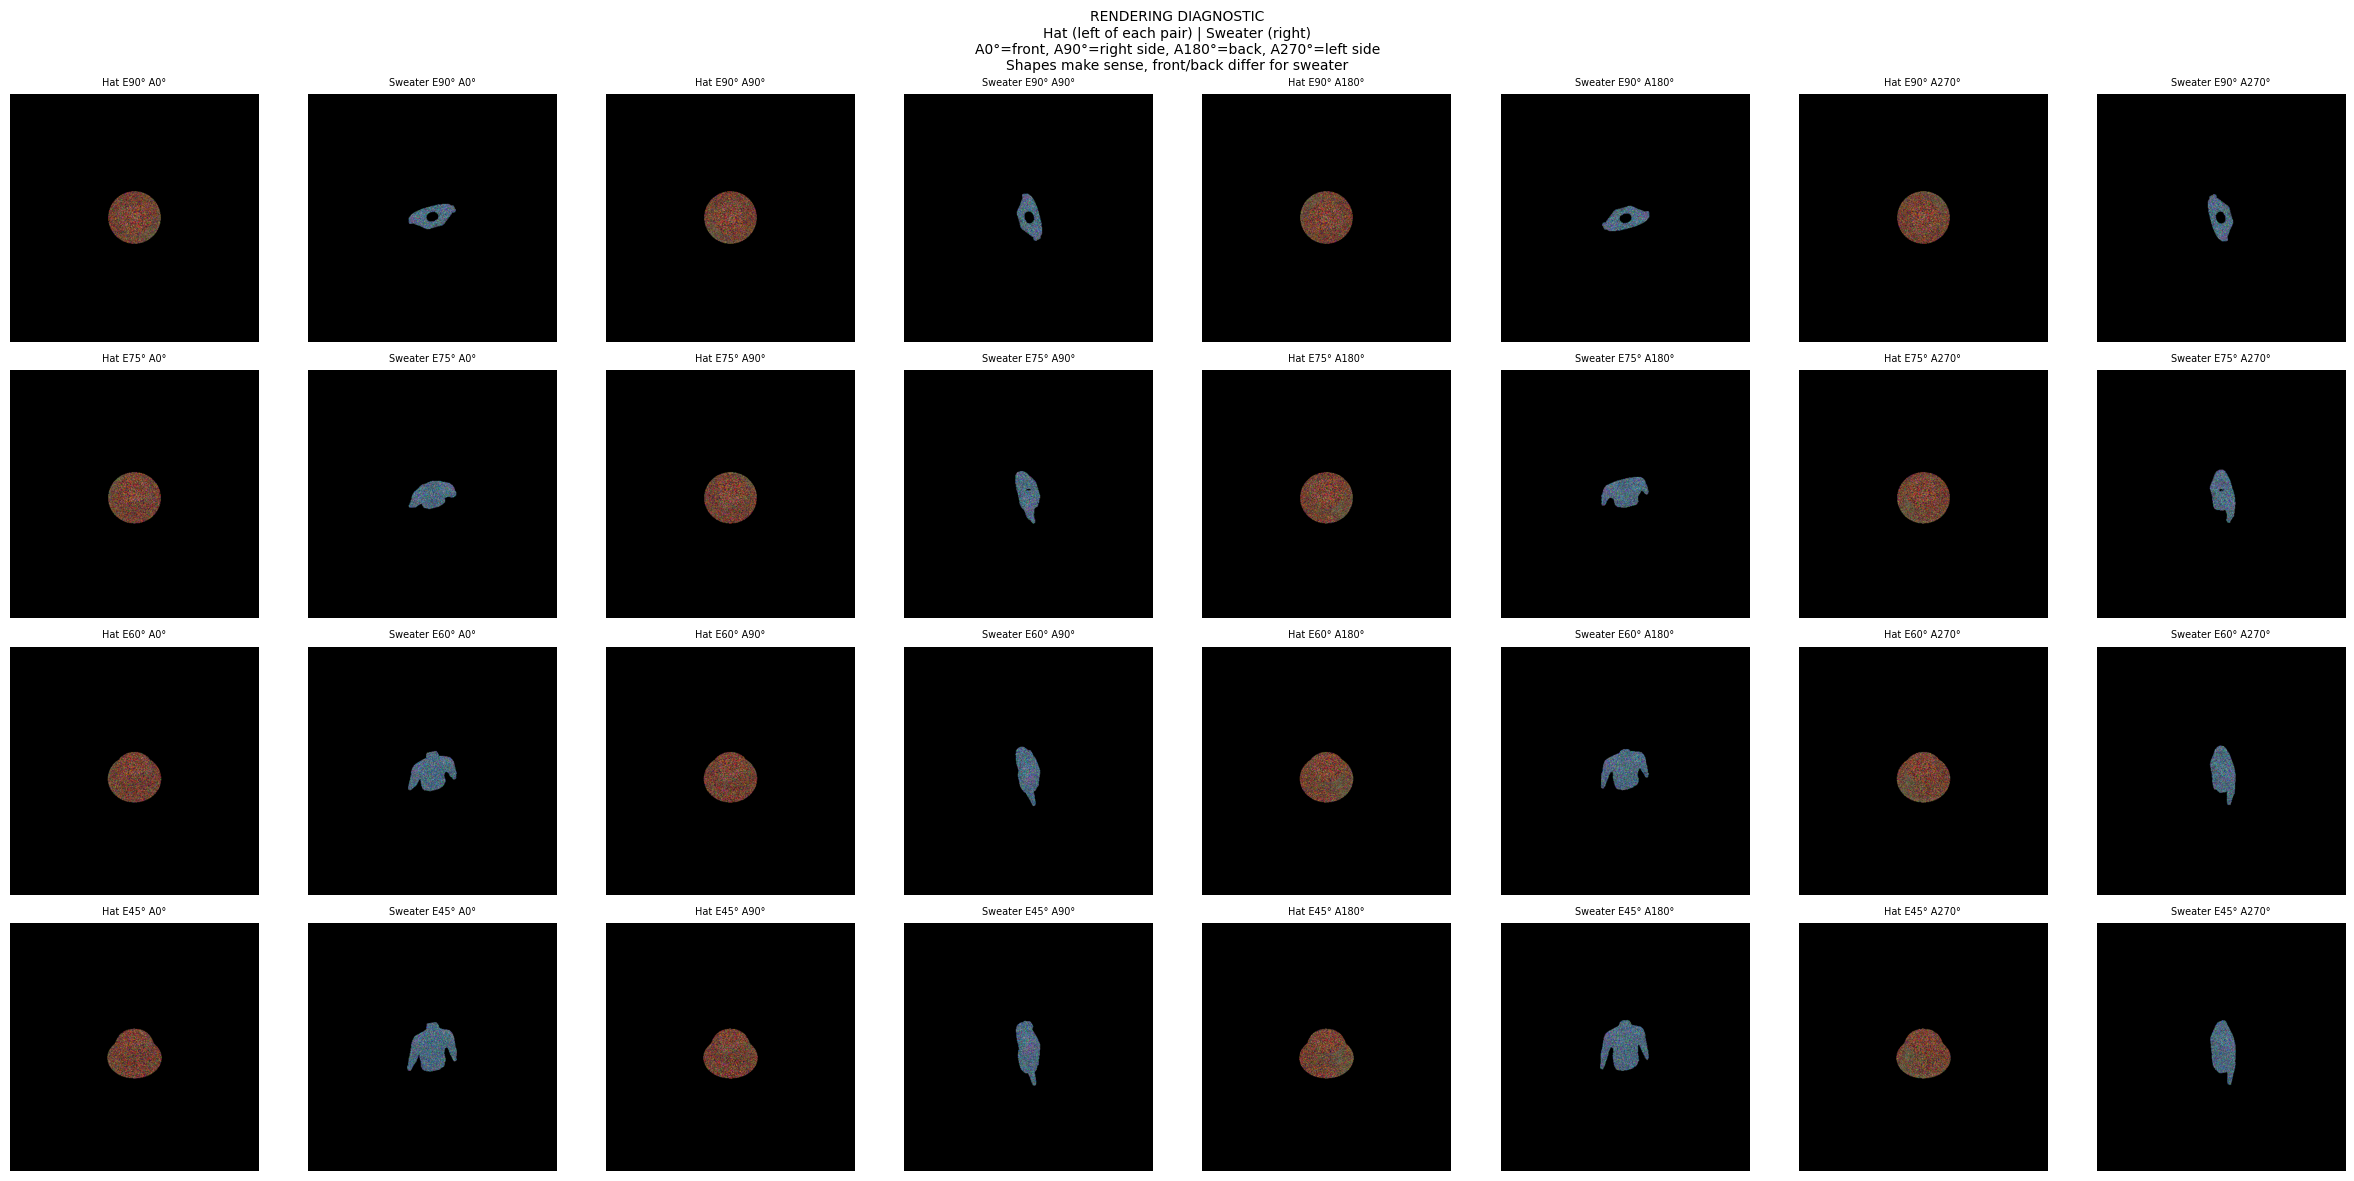

2026-03-29 22:48:43,033 | Hat should look like a hat from all angles
2026-03-29 22:48:43,036 | Sweater should show different shape at A0 (front) vs A180 (back)
2026-03-29 22:48:43,037 | At E90 (overhead) you see mostly the top of both
2026-03-29 22:48:43,039 | 
2026-03-29 22:48:43,039 | CALIBRATION: Bucket Hat
2026-03-29 22:48:43,040 |   Original mesh max extent: 2.900 units
2026-03-29 22:48:43,041 |   (normalized to ~1.0, then rotated 105° around Y)
2026-03-29 22:48:43,042 |   Post-transform axis spans:
2026-03-29 22:48:43,043 |     X (left-right): 0.9995 units
2026-03-29 22:48:43,044 |     Y (up-down):    0.4538 units
2026-03-29 22:48:43,045 |     Z (front-back): 0.9995 units
2026-03-29 22:48:43,046 |   Widest axis: X = 0.9995 units
2026-03-29 22:48:43,046 |   Measure this dimension on the real garment in inches
2026-03-29 22:48:43,047 |   Then: mesh_unit_to_inches = measurement / 0.9995
2026-03-29 22:48:43,048 | ==================================================

2026-03-29 22:48:43

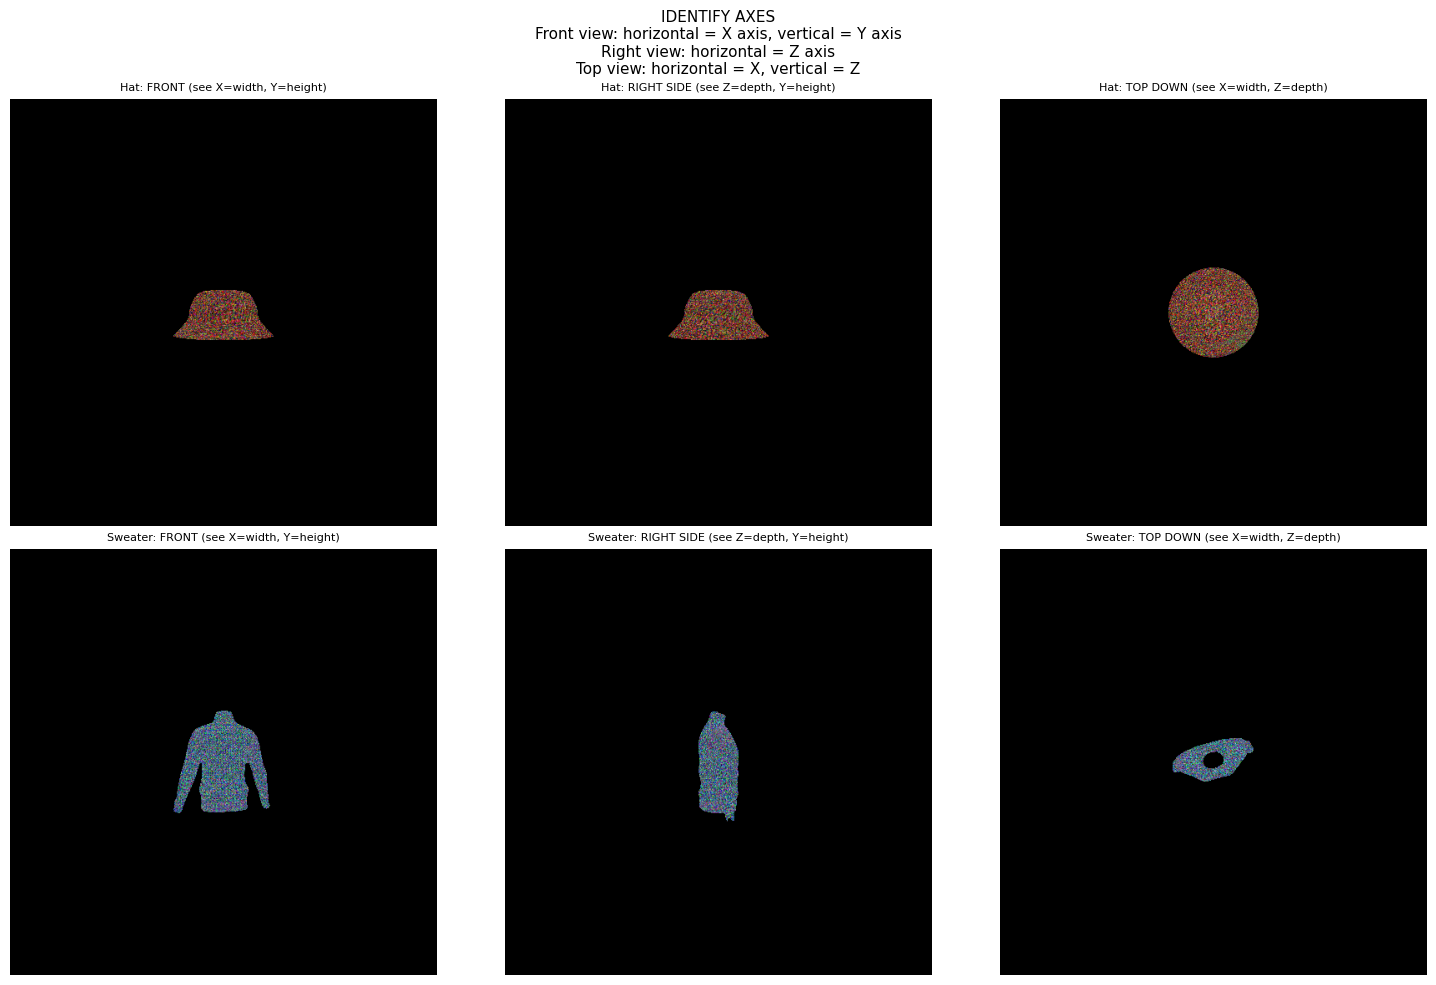

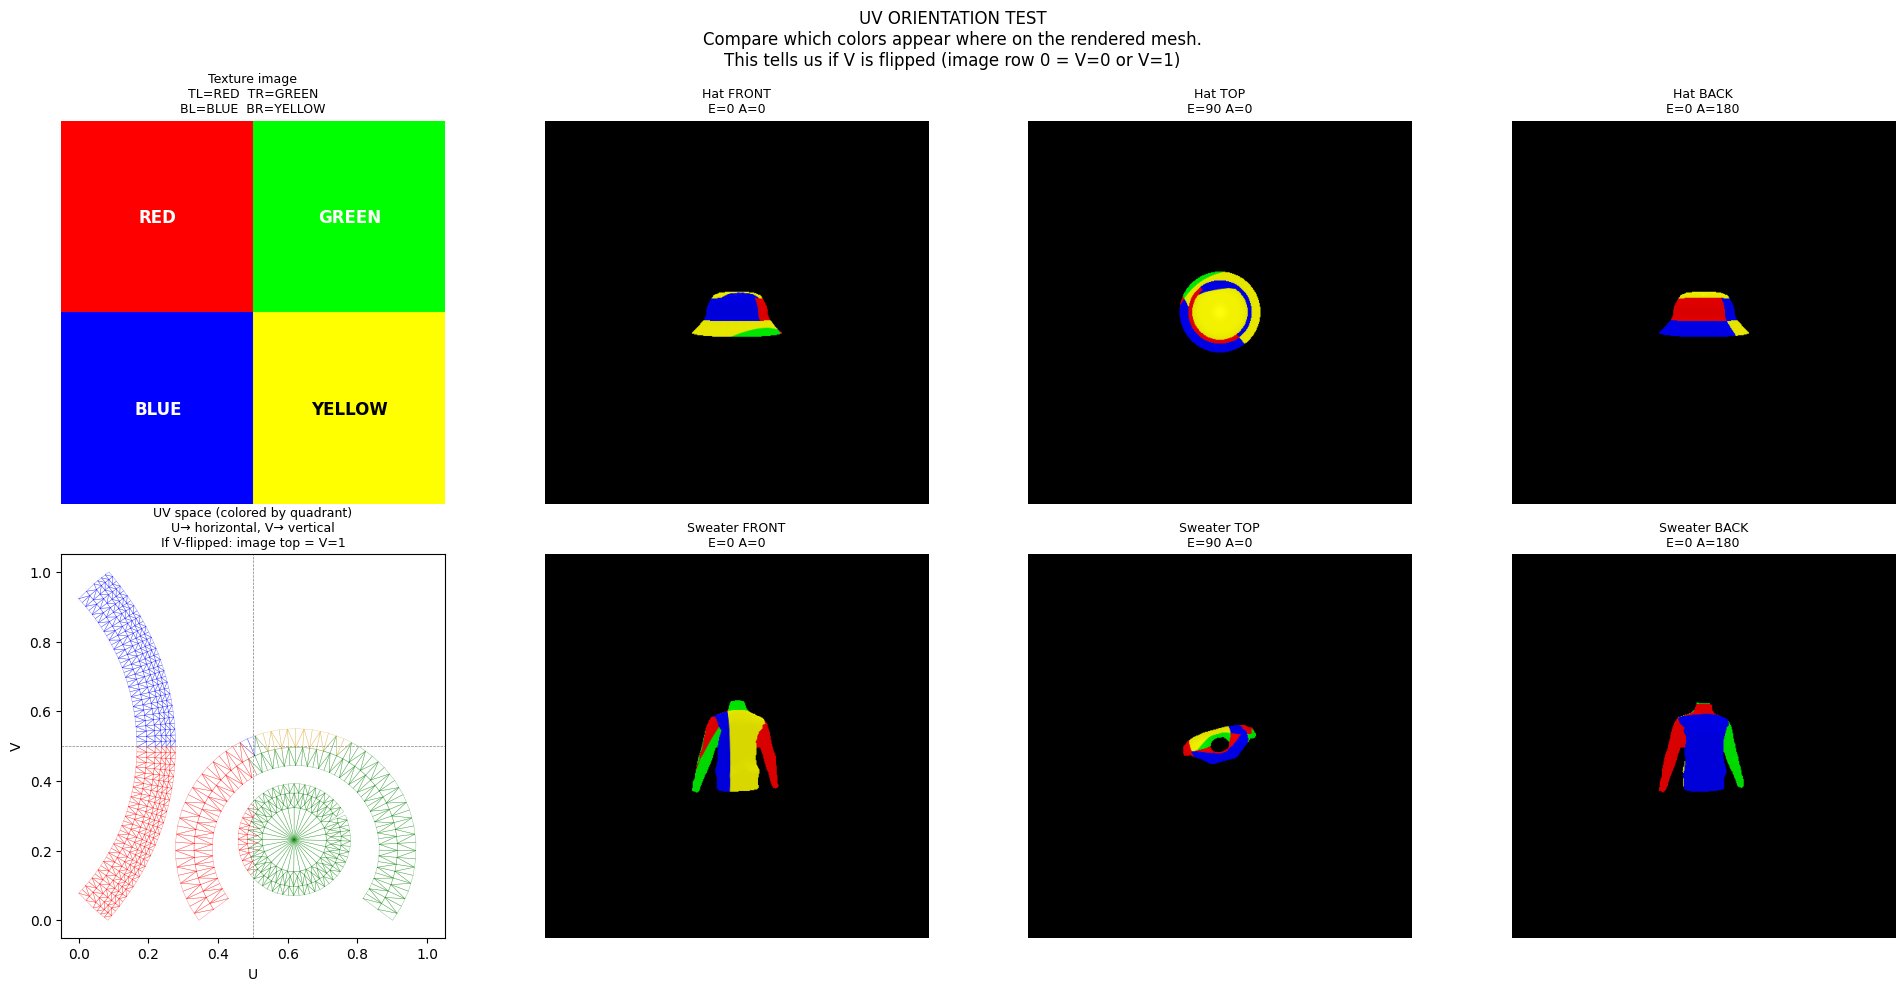

2026-03-29 22:48:49,135 | INSTRUCTIONS:
2026-03-29 22:48:49,136 |   Look at the TOP-DOWN view of the hat.
2026-03-29 22:48:49,137 |   The texture has: top-half = RED+GREEN, bottom-half = BLUE+YELLOW
2026-03-29 22:48:49,138 |   If the rendered top-down shows RED+GREEN on top -> NO V-FLIP (standard)
2026-03-29 22:48:49,139 |   If the rendered top-down shows BLUE+YELLOW on top -> V IS FLIPPED (OpenGL convention)
2026-03-29 22:48:49,201 | Current metadata keys: ['distance_to_scale', 'sources']
2026-03-29 22:48:49,202 | distance_to_scale: {'min_distance': 1.07, 'max_distance': 20.48, 'min_scale': 0.3, 'max_scale': 1.2}
2026-03-29 22:48:49,242 | Distance range: 2.1 – 15.5 m
2026-03-29 22:48:49,243 | Scale range:    0.532 – 1.153
2026-03-29 22:48:49,245 | Distance percentiles: 10%=3.9  50%=6.9  90%=12.6
2026-03-29 22:48:49,276 |   dist=2.1m → scale=1.153 → rendered hat pixels: 11479
2026-03-29 22:48:49,300 |   dist=6.9m → scale=0.932 → rendered hat pixels: 7590
2026-03-29 22:48:49,323 |   dis

In [8]:
def analyze_mesh_for_printing(mesh_path, config, preloaded=None, explicit_scale=None):
    
    from collections import defaultdict, deque
    _p = config['printer']
    
    #Check if the mesh is here. Otherwise, default
    if not Path(mesh_path).exists():
        logger.warning("No mesh file, defaulting to 12x12 inch print area")
        config['physical_size_inches'] = (12.0, 12.0)
        config['texture_output_size_w'] = int(_p['dpi'] * 12)
        config['texture_output_size_h'] = int(_p['dpi'] * 12)
        config['uv_islands'] = []
        return
        
    #Check if we have already parsed the .obj
    if preloaded is not None:
        verts_np = preloaded['verts'].cpu().numpy()
        verts_uvs = preloaded['verts_uvs'].cpu().numpy()
        faces_verts = preloaded['faces_verts'].cpu().numpy()
        faces_uvs = preloaded['faces_uvs'].cpu().numpy()
    else:
        #If not then we parse it
        verts, faces, aux = load_obj(mesh_path)
        verts_np = verts.cpu().numpy()
        verts_uvs = aux.verts_uvs.cpu().numpy()
        faces_verts = faces.verts_idx.cpu().numpy()
        faces_uvs = faces.textures_idx.cpu().numpy()
        
    #Scale: prefer explicit, then generic, then auto-estimate
    if explicit_scale is not None:
        scale = explicit_scale
        logger.info(f"Using measured mesh scale: {scale:.3f} in/unit")
    elif _p['mesh_unit_to_inches'] is not None:
        scale = _p['mesh_unit_to_inches']
        logger.info(f"Using config mesh scale: {scale:.3f} in/unit")
    else:
        x_span = verts_np[:, 0].max() - verts_np[:, 0].min()
        y_span = verts_np[:, 1].max() - verts_np[:, 1].min()
        z_span = verts_np[:, 2].max() - verts_np[:, 2].min()
        max_span = max(x_span, y_span, z_span)
        scale = 10.0 / max_span if max_span > 0 else 1.0
        logger.warning(f"Auto-estimated mesh scale: {scale:.3f} in/unit "
                       f"(mesh widest: {max_span:.3f} units -> ~10 inches)")
        logger.warning("SET printer.mesh_unit_to_inches manually for accuracy")
    _p['mesh_unit_to_inches'] = scale
    
    #Adjacency map
    uv_vert_to_faces = defaultdict(set)
    for fi, face in enumerate(faces_uvs):
        for vi in face:
            uv_vert_to_faces[vi].add(fi)
            
    #BFS for UV Island Detection
    visited = set()
    islands = []
    for fi in range(len(faces_uvs)):
        if fi in visited:
            continue
        island = []
        queue = deque([fi])
        while queue:
            f = queue.popleft()
            if f in visited:
                continue
            visited.add(f)
            island.append(f)
            for vi in faces_uvs[f]:
                for neighbor in uv_vert_to_faces[vi]:
                    if neighbor not in visited:
                        queue.append(neighbor)
        islands.append(island)
        
    #Measure the size of the islands
    island_info = []
    for idx, island_faces in enumerate(islands):
        island_uv_indices = set()
        for fi in island_faces:
            for vi in faces_uvs[fi]:
                island_uv_indices.add(vi)
        island_uvs_arr = verts_uvs[list(island_uv_indices)]
        u_min, v_min = island_uvs_arr.min(axis=0)
        u_max, v_max = island_uvs_arr.max(axis=0)
        
        #Triangle area via cross product - sum the area
        total_area_3d = 0.0
        for fi in island_faces:
            v0 = verts_np[faces_verts[fi][0]]
            v1 = verts_np[faces_verts[fi][1]]
            v2 = verts_np[faces_verts[fi][2]]
            total_area_3d += 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
            
        #Ratio between 3D surface and UV area
        physical_area = total_area_3d * (scale ** 2)
        
        #Store measurements on the islands
        island_info.append({
            'index': idx,
            'num_faces': len(island_faces),
            'uv_bounds': (u_min, v_min, u_max, v_max),
            'physical_area_sq_inches': physical_area,
        })
        
        logger.info(f"  Island {idx}: {len(island_faces)} faces, ~{physical_area:.1f} sq in")
    
    #Overall print dimensions
    config['uv_islands'] = island_info
    logger.info(f"Found {len(islands)} UV island(s)")
    
    #Total area
    total_area = sum(i['physical_area_sq_inches'] for i in island_info)
    all_u_min = min(i['uv_bounds'][0] for i in island_info)
    all_v_min = min(i['uv_bounds'][1] for i in island_info)
    all_u_max = max(i['uv_bounds'][2] for i in island_info)
    all_v_max = max(i['uv_bounds'][3] for i in island_info)
    uv_width = all_u_max - all_u_min
    uv_height = all_v_max - all_v_min
    
    #Bounding box uv area for printing
    sa = _p['seam_allowance_inches']
    
    #Average 3D-to-UV scale: compare total 3D area to total UV area
    total_uv_area = 0.0
    for island_faces_idx in islands:
        for fi in island_faces_idx:
            uv0 = verts_uvs[faces_uvs[fi][0]]
            uv1 = verts_uvs[faces_uvs[fi][1]]
            uv2 = verts_uvs[faces_uvs[fi][2]]
            total_uv_area += 0.5 * abs(np.cross(uv1 - uv0, uv2 - uv0))
            
    #physical_area / uv_area = (scale_per_uv_unit)^2
    scale_per_uv = np.sqrt(total_area / (total_uv_area + 1e-8))
    phys_w = uv_width * scale_per_uv + 2 * sa
    phys_h = uv_height * scale_per_uv + 2 * sa
    
    #Store info
    config['physical_size_inches'] = (phys_w, phys_h)
    config['texture_output_size_w'] = int(_p['dpi'] * phys_w)
    config['texture_output_size_h'] = int(_p['dpi'] * phys_h)
    
    #Log the info
    logger.info(f"Print size: {phys_w:.1f} x {phys_h:.1f} inches " f"({config['texture_output_size_w']}x{config['texture_output_size_h']}px @ {_p['dpi']} DPI)")

#Instantiate both renderers
renderer_hat = HatRenderer(CONFIG['mesh_path'], CONFIG['render_size'], device)
renderer_sweater = HatRenderer(CONFIG['sweater_mesh_path'], CONFIG['render_size'], device)

def calibration_report(renderer, mesh_name, raw_max_extent=None):
    v = renderer.verts.cpu().numpy()
    x_span = v[:, 0].max() - v[:, 0].min()
    y_span = v[:, 1].max() - v[:, 1].min()
    z_span = v[:, 2].max() - v[:, 2].min()
    
    logger.info(f"\n{'='*50}")
    logger.info(f"CALIBRATION: {mesh_name}")
    if raw_max_extent:
        logger.info(f"  Original mesh max extent: {raw_max_extent:.3f} units")
        logger.info(f"  (normalized to ~1.0, then rotated 105° around Y)")
    logger.info(f"  Post-transform axis spans:")
    logger.info(f"    X (left-right): {x_span:.4f} units")
    logger.info(f"    Y (up-down):    {y_span:.4f} units")
    logger.info(f"    Z (front-back): {z_span:.4f} units")
    widest = max(x_span, y_span, z_span)
    logger.info(f"  Widest axis: {'XYZ'[np.argmax([x_span, y_span, z_span])]} = {widest:.4f} units")
    logger.info(f"  Measure this dimension on the real garment in inches")
    logger.info(f"  Then: mesh_unit_to_inches = measurement / {widest:.4f}")
    logger.info(f"{'='*50}\n")

#Analyze both for printing
if renderer_hat.mesh_loaded and Path(CONFIG['mesh_path']).exists():
    analyze_mesh_for_printing(CONFIG['mesh_path'], CONFIG, preloaded={
        'verts': renderer_hat.verts, 'verts_uvs': renderer_hat.verts_uvs,
        'faces_verts': renderer_hat.faces, 'faces_uvs': renderer_hat.faces_uvs,
    }, explicit_scale=CONFIG['printer'].get('hat_mesh_unit_to_inches'))

#Store sweater print info under separate keys
sweater_config = {**CONFIG, 'printer': CONFIG['printer'].copy()}
if renderer_sweater.mesh_loaded and Path(CONFIG['sweater_mesh_path']).exists():
    analyze_mesh_for_printing(CONFIG['sweater_mesh_path'], sweater_config, preloaded={
        'verts': renderer_sweater.verts, 'verts_uvs': renderer_sweater.verts_uvs,
        'faces_verts': renderer_sweater.faces, 'faces_uvs': renderer_sweater.faces_uvs,
    }, explicit_scale=CONFIG['printer'].get('sweater_mesh_unit_to_inches'))
CONFIG['sweater_physical_size_inches'] = sweater_config.get('physical_size_inches', (12, 12))
CONFIG['sweater_texture_output_size_w'] = sweater_config.get('texture_output_size_w', 3600)
CONFIG['sweater_texture_output_size_h'] = sweater_config.get('texture_output_size_h', 3600)

if not SUPER: 
    #Diagnostic verify both meshes look correct
    logger.info("Running rendering diagnostic...")
    diag_elevs = [90, 75, 60, 45]
    diag_azims = [0, 90, 180, 270]
    
    fig, axes = plt.subplots(len(diag_elevs), len(diag_azims) * 2, figsize=(len(diag_azims) * 6, len(diag_elevs) * 3))
    
    with torch.no_grad():
        rand_hat_tex = generator_hat.generate(batch_size=1)
        rand_sw_tex = generator_sweater.generate(batch_size=1)
        
        for row, elev in enumerate(diag_elevs):
            for col, azim in enumerate(diag_azims):
                #Hat
                rh, ah = renderer_hat.render(rand_hat_tex, elevation=elev, azimuth=azim, scale=1.0)
                vis_h = rh * ah
                axes[row, col * 2].imshow(vis_h[0].permute(1, 2, 0).cpu().clamp(0, 1))
                axes[row, col * 2].set_title(f'Hat E{elev}° A{azim}°', fontsize=7)
                axes[row, col * 2].axis('off')
                #Sweater
                rs, as_ = renderer_sweater.render(rand_sw_tex, elevation=elev, azimuth=azim, scale=1.0)
                vis_s = rs * as_
                axes[row, col * 2 + 1].imshow(vis_s[0].permute(1, 2, 0).cpu().clamp(0, 1))
                axes[row, col * 2 + 1].set_title(f'Sweater E{elev}° A{azim}°', fontsize=7)
                axes[row, col * 2 + 1].axis('off')
    
    #Rendering diagnostic outputs
    fig.suptitle('RENDERING DIAGNOSTIC\nHat (left of each pair) | Sweater (right)\n'
                 'A0°=front, A90°=right side, A180°=back, A270°=left side\n'
                 'Shapes make sense, front/back differ for sweater', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/rendering_diagnostic.png", dpi=150, bbox_inches='tight')
    plt.show()
    logger.info("Hat should look like a hat from all angles")
    logger.info("Sweater should show different shape at A0 (front) vs A180 (back)")
    logger.info("At E90 (overhead) you see mostly the top of both")
    
    #Hat was normalized from 2.9 units
    calibration_report(renderer_hat, "Bucket Hat", raw_max_extent=2.9)
    #Sweater was normalized from 1.0 units
    calibration_report(renderer_sweater, "Sweater", raw_max_extent=1.0)
    
    #Visual: render from 3 orthogonal views to identify axes
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    with torch.no_grad():
        test_tex_h = generator_hat.generate(batch_size=1)
        test_tex_s = generator_sweater.generate(batch_size=1)
        
        views = [
            ('FRONT (see X=width, Y=height)', 0, 0),
            ('RIGHT SIDE (see Z=depth, Y=height)', 0, 90),
            ('TOP DOWN (see X=width, Z=depth)', 90, 0),
        ]
        for col, (label, elev, azim) in enumerate(views):
            rh, ah = renderer_hat.render(test_tex_h, elevation=elev, azimuth=azim, scale=1.0)
            axes[0, col].imshow((rh * ah)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[0, col].set_title(f'Hat: {label}', fontsize=8)
            axes[0, col].axis('off')
            
            rs, as_ = renderer_sweater.render(test_tex_s, elevation=elev, azimuth=azim, scale=1.0)
            axes[1, col].imshow((rs * as_)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[1, col].set_title(f'Sweater: {label}', fontsize=8)
            axes[1, col].axis('off')
    
    fig.suptitle('IDENTIFY AXES\nFront view: horizontal = X axis, vertical = Y axis\n'
                 'Right view: horizontal = Z axis\nTop view: horizontal = X, vertical = Z',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/calibration_axes.png", dpi=150)
    plt.show()
    
    #UV ORIENTATION TEST
    #Create a texture with known asymmetric colors in each quadrant
    test_tex = torch.zeros(1, 3, 288, 288, device=device)
    #Top-left of image = RED
    test_tex[:, 0, :144, :144] = 1.0
    #Top-right of image = GREEN  
    test_tex[:, 1, :144, 144:] = 1.0
    # Bottom-left of image = BLUE
    test_tex[:, 2, 144:, :144] = 1.0
    #Bottom-right of image = YELLOW
    test_tex[:, 0, 144:, 144:] = 1.0
    test_tex[:, 1, 144:, 144:] = 1.0
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    #Row 0: the texture image itself
    axes[0, 0].imshow(test_tex[0].permute(1, 2, 0).cpu())
    axes[0, 0].set_title('Texture image\nTL=RED  TR=GREEN\nBL=BLUE  BR=YELLOW', fontsize=9)
    axes[0, 0].text(72, 72, 'RED', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    axes[0, 0].text(216, 72, 'GREEN', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    axes[0, 0].text(72, 216, 'BLUE', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    axes[0, 0].text(216, 216, 'YELLOW', ha='center', va='center', fontsize=12, color='black', fontweight='bold')
    axes[0, 0].axis('off')
    
    #Row 0 cols 1-3: hat rendered from 3 views
    with torch.no_grad():
        for col, (label, elev, azim) in enumerate([
            ('Hat FRONT', 0, 0), ('Hat TOP', 90, 0), ('Hat BACK', 0, 180)
        ]):
            rh, ah = renderer_hat.render(test_tex, elevation=elev, azimuth=azim, scale=1.0)
            axes[0, col+1].imshow((rh * ah)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[0, col+1].set_title(f'{label}\nE={elev} A={azim}', fontsize=9)
            axes[0, col+1].axis('off')
    
    #Row 1 col 0: UV space reference
    #Draw the UV coordinates with color-coded quadrants
    uv = renderer_hat.verts_uvs.cpu().numpy()
    fuv = renderer_hat.faces_uvs.cpu().numpy()
    axes[1, 0].set_xlim(-0.05, 1.05)
    axes[1, 0].set_ylim(-0.05, 1.05)
    axes[1, 0].set_aspect('equal')
    # Draw UV triangles
    for face in fuv:
        tri = uv[face]
        tri_closed = np.vstack([tri, tri[0]])
        # Color by centroid position
        cu, cv = tri.mean(axis=0)
        if cu < 0.5 and cv < 0.5:
            c = 'red'
        elif cu >= 0.5 and cv < 0.5:
            c = 'green'
        elif cu < 0.5 and cv >= 0.5:
            c = 'blue'
        else:
            c = 'goldenrod'
        axes[1, 0].plot(tri_closed[:, 0], tri_closed[:, 1], '-', color=c, linewidth=0.3, alpha=0.5)
    axes[1, 0].axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(0.5, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].set_title('UV space (colored by quadrant)\nU→ horizontal, V→ vertical\n'
                          'If V-flipped: image top = V=1', fontsize=9)
    axes[1, 0].set_xlabel('U')
    axes[1, 0].set_ylabel('V')
    
    #Row 1 cols 1-3: sweater rendered
    with torch.no_grad():
        for col, (label, elev, azim) in enumerate([
            ('Sweater FRONT', 0, 0), ('Sweater TOP', 90, 0), ('Sweater BACK', 0, 180)
        ]):
            rs, as_ = renderer_sweater.render(test_tex, elevation=elev, azimuth=azim, scale=1.0)
            axes[1, col+1].imshow((rs * as_)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[1, col+1].set_title(f'{label}\nE={elev} A={azim}', fontsize=9)
            axes[1, col+1].axis('off')
    
    fig.suptitle('UV ORIENTATION TEST\n'
                 'Compare which colors appear where on the rendered mesh.\n'
                 'This tells us if V is flipped (image row 0 = V=0 or V=1)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/uv_orientation_test.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info("INSTRUCTIONS:")
    logger.info("  Look at the TOP-DOWN view of the hat.")
    logger.info("  The texture has: top-half = RED+GREEN, bottom-half = BLUE+YELLOW")
    logger.info("  If the rendered top-down shows RED+GREEN on top -> NO V-FLIP (standard)")
    logger.info("  If the rendered top-down shows BLUE+YELLOW on top -> V IS FLIPPED (OpenGL convention)")

    #Check current annotations metadata
    with open(Path(CONFIG['dataset_dir']) / 'annotations.json') as f:
        ann = json.load(f)
    meta = ann['metadata']
    logger.info(f"Current metadata keys: {list(meta.keys())}")
    if 'distance_to_scale' in meta:
        logger.info(f"distance_to_scale: {meta['distance_to_scale']}")
    elif 'altitude_to_scale' in meta:
        logger.info(f"altitude_to_scale: {meta['altitude_to_scale']}")
    else:
        logger.info("No distance/altitude scale mapping found!")
    
    #Show the actual distance range and what scale values are produced
    distances = []
    scales = []
    for frame in ann['frames']:
        d = frame['drone'].get('distance_3d_meters', frame['drone'].get('altitude_meters', 5.0))
        distances.append(d)
        scales.append(dataset_all._distance_to_scale(d))
    
    distances = np.array(distances)
    scales = np.array(scales)
    logger.info(f"Distance range: {distances.min():.1f} – {distances.max():.1f} m")
    logger.info(f"Scale range:    {scales.min():.3f} – {scales.max():.3f}")
    logger.info(f"Distance percentiles: 10%={np.percentile(distances,10):.1f}  "
                f"50%={np.percentile(distances,50):.1f}  "
                f"90%={np.percentile(distances,90):.1f}")
    
    #Show what rendered pixel count we get at extremes
    with torch.no_grad():
        test_tex = generator_hat.generate(batch_size=1)
        for d_test in [distances.min(), np.median(distances), distances.max()]:
            s = dataset_all._distance_to_scale(d_test)
            rh, ah = renderer_hat.render(test_tex, elevation=60, azimuth=0, scale=s)
            hat_pixels = (ah > 0.1).sum().item()
            logger.info(f"  dist={d_test:.1f}m → scale={s:.3f} → rendered hat pixels: {hat_pixels}")

## 9: T-SEA Augmentations

Helper methods for black/gray/white box transfers

In [9]:
#Randomly mask a region of the rendered hat. Prevents overfitting to specific texture patterns.
def patch_cutout(rendered_hat, alpha_mask, prob=0.9, ratio=0.4, fill=0.5):
    
    if np.random.random() > prob:
        return rendered_hat
    B, C, H, W = rendered_hat.shape
    
    #Random cutout size
    cut_h = int(H * ratio)
    cut_w = int(W * ratio)
    
    #Random position
    top = np.random.randint(0, H - cut_h + 1)
    left = np.random.randint(0, W - cut_w + 1)
    
    #Apply cutout (only where alpha > 0)
    mask = alpha_mask.clone()
    mask[:, :, top:top+cut_h, left:left+cut_w] = 0
    rendered_hat = rendered_hat * mask + fill * (1 - mask) * (alpha_mask > 0).float()
    return rendered_hat

#Mild augmentations that don't distort the image too much.
def constrained_augmentation(image):
    
    B, C, H, W = image.shape
    
    #Random scale (0.9 - 1.1)
    scale = np.random.uniform(0.9, 1.1)
    new_h = int(H * scale)
    new_w = int(W * scale)
    image = F.interpolate(image, size=(new_h, new_w), mode='bilinear', align_corners=False)
    
    #Crop/pad back to original size
    if new_h > H:
        start_h = (new_h - H) // 2
        start_w = (new_w - W) // 2
        image = image[:, :, start_h:start_h+H, start_w:start_w+W]
    else:
        pad_h_top = (H - new_h) // 2
        pad_h_bot = H - new_h - pad_h_top
        pad_w_left = (W - new_w) // 2
        pad_w_right = W - new_w - pad_w_left
        image = F.pad(image, [pad_w_left, pad_w_right, pad_h_top, pad_h_bot], mode='reflect')
    
    #Color jitter (mild)
    brightness = np.random.uniform(0.9, 1.1)
    image = image * brightness
    
    #Random horizontal flip
    if np.random.random() > 0.5:
        image = torch.flip(image, dims=[3])
    return image.clamp(0, 1)

#ShakeDrop reates virtual ensemble of model variants
def shakedrop_forward(x, drop_prob=0.5, alpha_range=(0, 2)):
    #Simplified ShakeDrop: add scaled noise to create virtual ensemble variants
    if np.random.random() < drop_prob:
        alpha = np.random.uniform(*alpha_range)
        noise = torch.randn_like(x) * 0.1 * alpha
        x = x + noise
    return x

## 10: URAdv Augmentations

For better performance under drone conditions

In [10]:
#Add simulated light reflections on the hat surface.
def add_light_spots(image, alpha_mask, num_range=(0, 3), intensity_range=(0.1, 0.4)):
    
    if np.random.random() > 0.5:
        return image
    B, C, H, W = image.shape
    num_spots = np.random.randint(*num_range)
    y, x = torch.meshgrid(torch.arange(H, device=image.device), torch.arange(W, device=image.device), indexing='ij')
    for _ in range(num_spots):
        
        #Random spot position (within hat region)
        cy = np.random.randint(H // 4, 3 * H // 4)
        cx = np.random.randint(W // 4, 3 * W // 4)
        
        #Spot parameters
        radius = np.random.uniform(0.05, 0.15) * min(H, W)
        intensity = np.random.uniform(*intensity_range)
        
        #Create Gaussian spot
        dist = ((x - cx) ** 2 + (y - cy) ** 2).float()
        spot = torch.exp(-dist / (2 * radius ** 2)) * intensity
        
        #Apply only within hat (where alpha > 0)
        spot = spot.unsqueeze(0).unsqueeze(0) * (alpha_mask > 0).float()
        image = image + spot
    return image.clamp(0, 1)

#Add simulated shadows on the hat surface.
def add_shadows(image, alpha_mask, num_range=(0, 2), opacity_range=(0.2, 0.5)):
    
    if np.random.random() > 0.5:
        return image
    B, C, H, W = image.shape
    num_shadows = np.random.randint(*num_range)
    y, x = torch.meshgrid(torch.arange(H, device=image.device), torch.arange(W, device=image.device), indexing='ij')
    for _ in range(num_shadows):
        
        #Random shadow as diagonal stripe
        angle = np.random.uniform(0, np.pi)
        opacity = np.random.uniform(*opacity_range)
        width = np.random.uniform(0.1, 0.3) * min(H, W)
        
        #Create shadow mask
        offset = np.random.uniform(0, H)
        dist = torch.abs(x * np.cos(angle) + y * np.sin(angle) - offset)
        shadow = (dist < width).float() * opacity
        
        #Apply only within hat
        shadow = shadow.unsqueeze(0).unsqueeze(0) * (alpha_mask > 0).float()
        image = image * (1 - shadow)
    return image.clamp(0, 1)

#Simulate printer color/brightness variation.
def simulate_printing(texture, mul_std=0.1, add_std=0.05):
    
    #Multiplicative noise
    mul_noise = torch.randn_like(texture) * mul_std + 1.0
    texture = texture * mul_noise
    
    #Additive noise
    add_noise = torch.randn_like(texture) * add_std
    texture = texture + add_noise
    return texture.clamp(0, 1)

class PrinterGamut:

    #Load parameters, or use simplified constraints
    def __init__(self, config, device='cuda'):
        self.config = config['printer']
        self.device = device
        gamut_path = self.config.get('gamut_samples_path')
        if gamut_path and Path(gamut_path).exists():
            self.gamut_samples = torch.from_numpy(np.load(gamut_path)).float().to(self.device)
            self.use_measured_gamut = True
            logger.info(f"Loaded {len(self.gamut_samples)} gamut samples")
        else:
            self.use_measured_gamut = False
            logger.info("Using simplified gamut constraints")

    #Non-printability score loss
    def nps_loss(self, texture):
        loss = 0.0
        if self.use_measured_gamut:
            
            #Compare each texture pixel to the nearest printable color
            #texture: (B, 3, H, W) -> (N, 3) flat pixel list
            B, C, H, W = texture.shape
            pixels = texture.permute(0, 2, 3, 1).reshape(-1, 3)  #(N, 3)
            #gamut_samples: (G, 3) measured printable RGB values
            
            #Compute distance from each pixel to nearest gamut sample
            chunk_size = 4096
            gamut_dists = []
            
            for i in range(0, pixels.shape[0], chunk_size):
                chunk = pixels[i:i+chunk_size]  #(chunk, 3)
                dists = torch.cdist(chunk.unsqueeze(0), self.gamut_samples.unsqueeze(0)).squeeze(0)  #(chunk, G)
                min_dists = dists.min(dim=1)[0]  #(chunk,)
                gamut_dists.append(min_dists)
            gamut_dists = torch.cat(gamut_dists)
            loss = loss + gamut_dists.mean()
        else:
            
            #Simplified constraints when no gamut data available
            max_ch = texture.max(dim=1)[0]
            min_ch = texture.min(dim=1)[0]
            saturation = (max_ch - min_ch) / (max_ch + 1e-8)
            brightness = max_ch
            
            #Saturation * brightness threshold
            loss = loss + F.relu(saturation * brightness - self.config['nps_threshold']).mean()
            
            #Saturation cap
            loss = loss + F.relu(saturation - self.config['max_saturation']).mean()
            
            #Brightness bounds
            loss = loss + F.relu(brightness - self.config['max_brightness']).mean()
            loss = loss + F.relu(self.config['min_brightness'] - brightness).mean()
        return loss

    #Hard clamp for final export
    def clamp_to_gamut(self, texture):
        return texture.clamp(self.config['min_brightness'], self.config['max_brightness'])

#Initialize globally
printer_gamut = PrinterGamut(CONFIG, device)

#Apply camera artifacts: blur, noise.
def apply_environmental_augmentation(image, prob=0.3):
    
    #Motion blur
    if np.random.random() < prob:
        kernel_size = np.random.choice([3, 5, 7])
        kernel = torch.zeros(kernel_size, kernel_size, device=image.device)
        kernel[kernel_size//2, :] = 1.0 / kernel_size
        
        #Rotate kernel to random angle for directional blur
        angle = np.random.uniform(0, 360)
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        
        #Build rotation matrix and affine grid
        theta = torch.tensor([[cos_a, -sin_a, 0], [sin_a,  cos_a, 0]], dtype=torch.float32, device=image.device).unsqueeze(0)
        grid = F.affine_grid(theta, [1, 1, kernel_size, kernel_size], align_corners=False)
        kernel_rotated = F.grid_sample(kernel.unsqueeze(0).unsqueeze(0), grid, align_corners=False, mode='bilinear', padding_mode='zeros').squeeze()
        
        #Renormalize so kernel sums to 1
        kernel_rotated = kernel_rotated / (kernel_rotated.sum() + 1e-8)
        image = F.conv2d(image, kernel_rotated.view(1, 1, kernel_size, kernel_size).expand(3, 1, -1, -1), padding=kernel_size//2, groups=3)
    
    #Gaussian noise
    if np.random.random() < prob:
        noise_std = np.random.uniform(0.01, 0.05)
        image = image + torch.randn_like(image) * noise_std
    return image.clamp(0, 1)

#Viewpoint jitter for robustness
def apply_viewpoint_jitter(elevation, azimuth, scale, pitch_jitter, heading_jitter, scale_jitter):
    elev = elevation + np.random.uniform(-pitch_jitter, pitch_jitter)
    elev = np.clip(elev, 0, 90)
    azim = azimuth + np.random.uniform(-heading_jitter, heading_jitter)
    azim = azim % 360
    scl = scale * (1 + np.random.uniform(-scale_jitter, scale_jitter))
    scl = np.clip(scl, 0.1, 2.0)
    return elev, azim, scl

def apply_random_blur(rendered_hat, alpha_mask, prob=0.5, sigma_range=(0.5, 2.0)):
    
    if np.random.random() > prob:
        return rendered_hat
    sigma = np.random.uniform(*sigma_range)
    
    #Kernel size must be odd, ~3x sigma
    ksize = int(np.ceil(sigma * 3)) * 2 + 1
    ksize = max(3, ksize)
    
    #Gaussian kernel
    x = torch.arange(ksize, device=rendered_hat.device).float() - ksize // 2
    kernel_1d = torch.exp(-x**2 / (2 * sigma**2))
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.view(1, 1, ksize, ksize).expand(3, 1, -1, -1)
    
    #Apply only to hat region
    blurred = F.conv2d(rendered_hat, kernel_2d, padding=ksize//2, groups=3)
    
    #Blend: blur only where alpha > 0
    hat_region = (alpha_mask > 0.1).float()
    rendered_hat = blurred * hat_region + rendered_hat * (1 - hat_region)
    return rendered_hat

def frequency_bottleneck(texture, bottleneck_size):
    orig_size = texture.shape[-1]
    if bottleneck_size >= orig_size:
        return texture
    low = F.interpolate(texture, size=(bottleneck_size, bottleneck_size), mode='bilinear', align_corners=False)
    restored = F.interpolate(low, size=(orig_size, orig_size), mode='bilinear', align_corners=False)
    return restored

def get_bottleneck_size(epoch, config):
    schedule = config['freq_bottleneck']['stage1']
    size = schedule[0][1]  #default to first
    for start_epoch, bn_size in schedule:
        if epoch >= start_epoch:
            size = bn_size
    return size

2026-03-29 22:48:49,597 | Using simplified gamut constraints


## 11: Toroidal Cropping

Wrapping the texture

In [11]:
#Try to get smooth textures
def total_variation_loss(texture):
    
    diff_h = texture[:, :, 1:, :] - texture[:, :, :-1, :]
    diff_w = texture[:, :, :, 1:] - texture[:, :, :, :-1]
    
    #Toroidal wrap: penalize top↔bottom and left↔right seam
    diff_h_wrap = texture[:, :, 0:1, :] - texture[:, :, -1:, :]
    diff_w_wrap = texture[:, :, :, 0:1] - texture[:, :, :, -1:]
    
    #Concatenate so all pairs have equal weight in the mean
    all_h = torch.cat([diff_h, diff_h_wrap], dim=2)
    all_w = torch.cat([diff_w, diff_w_wrap], dim=3)
    return (all_h.pow(2).mean() + all_w.pow(2).mean()) / 2

class ToroidalLatent(nn.Module):

    def __init__(self, local_size, crop_size=9, latent_channels=128, device='cuda'):
        super().__init__()
        self.local_size = local_size
        self.crop_size = crop_size
        self.latent_channels = latent_channels
        self.z_local = nn.Parameter(torch.randn(1, latent_channels, local_size, local_size, device=device) * 0.1)

    #Random crop
    def get_random_crops(self, batch_size):
        
        #Tile 3x3 for wraparound
        z_tiled = self.z_local.repeat(1, 1, 3, 3)
        crops = []
        for _ in range(batch_size):
            
            #Random offset within middle tile (to enable wraparound)
            i = np.random.randint(self.local_size, 2 * self.local_size)
            j = np.random.randint(self.local_size, 2 * self.local_size)
            crop = z_tiled[:, :, i:i+self.crop_size, j:j+self.crop_size]
            crops.append(crop)
        return torch.cat(crops, dim=0)

    #Crop to fill size
    def get_full_latent(self, target_spatial_size):
        reps = (target_spatial_size + self.local_size - 1) // self.local_size + 1
        z_tiled = self.z_local.repeat(1, 1, reps, reps)
        return z_tiled[:, :, :target_spatial_size, :target_spatial_size]

    #Deterministic crop
    def get_canonical_crop(self):
        offset = (self.local_size - self.crop_size) // 2
        return self.z_local[:, :, offset:offset+self.crop_size, offset:offset+self.crop_size]

## 12: Sceen Composition

Render the sceen (put hat on image)

In [12]:
import math

#--------------------Composite Logic--------------------

def _composite_single_surface(scene_image, mask, rendered, alpha):

    #First clone
    B, C, H, W = scene_image.shape
    result = scene_image.clone()

    #Per image loop
    for i in range(B):
        m = mask[i, 0]
        if m.sum() == 0:
            continue

        #Find how big it is and where to place it
        a = alpha[i, 0]
        a_ys, a_xs = torch.where(a > 0.1)
        if len(a_ys) == 0:
            continue
        #From mask: position and size only
        m_ys, m_xs = torch.where(m > 0.5)
        if len(m_ys) == 0:
            continue
        m_cy = m_ys.float().mean().item()
        m_cx = m_xs.float().mean().item()
        mask_area = len(m_ys)
        
        #From renderer: crop to non-transparent region
        ay1, ay2 = a_ys.min().item(), a_ys.max().item()
        ax1, ax2 = a_xs.min().item(), a_xs.max().item()
        r_crop = rendered[i:i+1, :, ay1:ay2+1, ax1:ax2+1]
        a_crop = alpha[i:i+1, :, ay1:ay2+1, ax1:ax2+1]
        rh, rw = r_crop.shape[2], r_crop.shape[3]
        
        #Scale: match mask area, uniform (preserves 3D shape)
        render_area = (a_crop > 0.1).float().sum().item()
        if render_area < 1:
            continue
        s = math.sqrt(mask_area / render_area)
        new_h = max(int(rh * s), 1)
        new_w = max(int(rw * s), 1)
        r_scaled = F.interpolate(r_crop, size=(new_h, new_w), mode='bilinear', align_corners=False)
        a_scaled = F.interpolate(a_crop, size=(new_h, new_w), mode='bilinear', align_corners=False)
        
        #Place centered on mask centroid
        py1 = int(m_cy - new_h / 2)
        px1 = int(m_cx - new_w / 2)
        
        #Clip to image bounds
        sy1 = max(0, -py1)
        sx1 = max(0, -px1)
        sy2 = min(new_h, H - py1)
        sx2 = min(new_w, W - px1)
        dy1 = max(0, py1)
        dx1 = max(0, px1)
        dy2 = dy1 + (sy2 - sy1)
        dx2 = dx1 + (sx2 - sx1)
        
        #Alpha blend
        if dy2 <= dy1 or dx2 <= dx1:
            continue
        r_patch = r_scaled[:, :, sy1:sy2, sx1:sx2]
        a_patch = a_scaled[:, :, sy1:sy2, sx1:sx2]
        #Blend: rendered alpha only, mask does not clip shape
        result[i:i+1, :, dy1:dy2, dx1:dx2] = (r_patch * a_patch + result[i:i+1, :, dy1:dy2, dx1:dx2] * (1 - a_patch))
    
    return result


def composite_hat_on_scene(scene_image, hat_mask, rendered_hat, alpha_mask):
    #Backward-compatible wrapper
    return _composite_single_surface(scene_image, hat_mask, rendered_hat, alpha_mask)


def composite_dual_on_scene(scene, hat_mask, sweater_mask, rendered_hat, hat_alpha, rendered_sweater, sweater_alpha, hat_usable, sweater_usable):
    
    #Composite both surfaces: sweater first, hat second
    result = scene.clone()
    B = scene.shape[0]
    
    #Sweater first
    sw_mask_batch = sweater_mask.clone()
    for i in range(B):
        if not sweater_usable[i]:
            sw_mask_batch[i] = 0
    result = _composite_single_surface(result, sw_mask_batch, rendered_sweater, sweater_alpha)
    
    #Hat second (on top)
    hat_mask_batch = hat_mask.clone()
    for i in range(B):
        if not hat_usable[i]:
            hat_mask_batch[i] = 0
    result = _composite_single_surface(result, hat_mask_batch, rendered_hat, hat_alpha)
    
    return result

#--------------------Crop strategies--------------------
    
#Tight Person Crop
def crop_to_person(composited, person_bbox, target_size=640, pad_ratio=0.5):
    B, C, H, W = composited.shape
    crops = []
    for i in range(B):
        x1, y1, x2, y2 = person_bbox[i]
        bw, bh = x2 - x1, y2 - y1
        side = max(bw, bh) * (1 + pad_ratio)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        half = side / 2
        cx1 = int(torch.clamp(cx - half, min=0))
        cy1 = int(torch.clamp(cy - half, min=0))
        cx2 = int(torch.clamp(cx + half, max=W))
        cy2 = int(torch.clamp(cy + half, max=H))
        crop = composited[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

#Simulate SAHI Crop that is slightly random
def sahi_aware_crop(composited, person_bbox, config):
    B, C, H, W = composited.shape
    slice_size = config.get('sahi_slice_size', 960)
    target_size = config['detector_input_size']
    crops = []
    for i in range(B):
        bbox = person_bbox[i]
        cx = (bbox[0] + bbox[2]).item() / 2
        cy = (bbox[1] + bbox[3]).item() / 2
        bw = (bbox[2] - bbox[0]).item()
        bh = (bbox[3] - bbox[1]).item()
        person_side = max(bw, bh)
        r = np.random.random()
        if r < 0.7:
            #SAHI-scale: 960 tile with 15% variation
            crop_size = int(slice_size * np.random.uniform(0.85, 1.15))
        elif r < 0.9:
            #Medium: 2-4× person bbox
            crop_size = int(person_side * np.random.uniform(2.0, 4.0))
        else:
            #Tight: 1.5× person bbox (original crop_to_person)
            crop_size = int(person_side * 1.5)
        crop_size = max(min(crop_size, H, W), 64)
        #Random position with person inside (not centered)
        margin = crop_size * 0.05
        x_lo = max(0, cx - crop_size + margin)
        x_hi = min(W - crop_size, cx - margin)
        y_lo = max(0, cy - crop_size + margin)
        y_hi = min(H - crop_size, cy - margin)
        x1 = int(np.clip(np.random.uniform(x_lo, max(x_hi, x_lo + 1)), 0, W - crop_size))
        y1 = int(np.clip(np.random.uniform(y_lo, max(y_hi, y_lo + 1)), 0, H - crop_size))
        crop = composited[i:i+1, :, y1:y1+crop_size, x1:x1+crop_size]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

#Extracts a bunch of crops at different angles per image 
def multi_tile_crop(composited, person_bbox, config, num_tiles=3):
    B, C, H, W = composited.shape
    slice_size = config.get('sahi_slice_size', 960)
    target_size = config['detector_input_size']
    all_crops = []
    for i in range(B):
        bbox = person_bbox[i]
        cx = (bbox[0] + bbox[2]).item() / 2
        cy = (bbox[1] + bbox[3]).item() / 2
        person_side = max((bbox[2] - bbox[0]).item(), (bbox[3] - bbox[1]).item())
        tiles = []
        for t in range(num_tiles):
            r = np.random.random()
            if r < 0.5:
                #SAHI-scale tile
                crop_size = int(slice_size * np.random.uniform(0.85, 1.15))
            elif r < 0.8:
                #Fullframe-like (whole image downscaled = large crop)
                crop_size = int(min(H, W) * np.random.uniform(0.7, 1.0))
            else:
                #Medium
                crop_size = int(person_side * np.random.uniform(2.0, 4.0))
            crop_size = max(min(crop_size, H, W), 64)
            #Random position with person inside
            margin = crop_size * 0.05
            x_lo = max(0, cx - crop_size + margin)
            x_hi = min(W - crop_size, cx - margin)
            y_lo = max(0, cy - crop_size + margin)
            y_hi = min(H - crop_size, cy - margin)
            x1 = int(np.clip(np.random.uniform(x_lo, max(x_hi, x_lo + 1)), 0, W - crop_size))
            y1 = int(np.clip(np.random.uniform(y_lo, max(y_hi, y_lo + 1)), 0, H - crop_size))
            crop = composited[i:i+1, :, y1:y1+crop_size, x1:x1+crop_size]
            crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
            tiles.append(crop)
        all_crops.extend(tiles)
    return torch.cat(all_crops, dim=0) #(B*num_tiles, 3, 640, 640)

#Crop specifically to head and hat
def crop_to_head(composited, person_bbox, hat_mask, target_size=640):
    B, C, H, W = composited.shape
    crops = []
    for i in range(B):
        mask = hat_mask[i, 0]
        if mask.sum() < 10:
            #Fallback to top 25% of person bbox
            x1, y1, x2, y2 = person_bbox[i]
            bh = y2 - y1
            head_y2 = y1 + bh * 0.25
        else:
            ys, xs = torch.where(mask > 0.5)
            y1, y2 = ys.min(), ys.max()
            x1, x2 = xs.min(), xs.max()
            head_y2 = y2
        #Square crop centered on hat with some context
        x1_p, y1_p, x2_p, y2_p = person_bbox[i]
        hat_cx = (x1 + x2) / 2 if mask.sum() >= 10 else (x1_p + x2_p) / 2
        hat_cy = (y1 + head_y2) / 2 if mask.sum() >= 10 else y1_p + (y2_p - y1_p) * 0.125
        bw = x2_p - x1_p
        side = max(bw * 0.6, 100)  #head-width crop with context
        half = side / 2
        cx1 = int(torch.clamp(hat_cx - half, min=0))
        cy1 = int(torch.clamp(hat_cy - half, min=0))
        cx2 = int(torch.clamp(hat_cx + half, max=W))
        cy2 = int(torch.clamp(hat_cy + half, max=H))
        crop = composited[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

#Crop to hat mask
def crop_hat_mask(hat_mask, person_bbox, target_size=640, pad_ratio=0.5):
    B, C, H, W = hat_mask.shape
    crops = []
    for i in range(B):
        x1, y1, x2, y2 = person_bbox[i]
        bw, bh = x2 - x1, y2 - y1
        side = max(bw, bh) * (1 + pad_ratio)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        half = side / 2
        cx1 = int(torch.clamp(cx - half, min=0))
        cy1 = int(torch.clamp(cy - half, min=0))
        cx2 = int(torch.clamp(cx + half, max=W))
        cy2 = int(torch.clamp(cy + half, max=H))
        crop = hat_mask[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='nearest')
        crops.append(crop)
    return torch.cat(crops, dim=0)

import random as _random

#--------------------SAHI Tiling Infrastructure--------------------

#Get top left corner of every tile
def compute_sahi_tile_coords(image_hw, slice_size, overlap):
    H, W = image_hw
    if slice_size >= H and slice_size >= W:
        return [(0, 0)]  #fullframe: one tile
    stride = max(1, int(slice_size * (1 - overlap)))
    x_starts = list(range(0, max(1, W - slice_size + 1), stride))
    y_starts = list(range(0, max(1, H - slice_size + 1), stride))
    #Ensure coverage of right/bottom edges
    if len(x_starts) == 0 or x_starts[-1] + slice_size < W:
        x_starts.append(max(0, W - slice_size))
    if len(y_starts) == 0 or y_starts[-1] + slice_size < H:
        y_starts.append(max(0, H - slice_size))
    #Deduplicate
    x_starts = sorted(set(x_starts))
    y_starts = sorted(set(y_starts))
    return [(y, x) for y in y_starts for x in x_starts]

#Given a SAHI grid and bbox get tiles
def find_person_tiles(tile_coords, slice_size, person_bbox, min_overlap_ratio=0.2):
    x1, y1, x2, y2 = [v.item() if isinstance(v, torch.Tensor) else v for v in person_bbox]
    person_area = max((x2 - x1) * (y2 - y1), 1.0)
    indices = []
    for idx, (ty, tx) in enumerate(tile_coords):
        #Intersection
        ix1 = max(x1, tx)
        iy1 = max(y1, ty)
        ix2 = min(x2, tx + slice_size)
        iy2 = min(y2, ty + slice_size)
        if ix1 < ix2 and iy1 < iy2:
            overlap_area = (ix2 - ix1) * (iy2 - iy1)
            if overlap_area / person_area >= min_overlap_ratio:
                indices.append(idx)
    return indices

#Fairley similar
def extract_tile(composited_single, tile_coords, tile_idx, slice_size, target_size=640):
    y0, x0 = tile_coords[tile_idx]
    tile = composited_single[:, :, y0:y0+slice_size, x0:x0+slice_size]
    tile = F.interpolate(tile, size=(target_size, target_size),mode='bilinear', align_corners=False)
    return tile

#This is a key contribution, the differentiable sahi. EOT Style Athalye et al.
def differentiable_sahi_loss(composite, person_bboxes, detector, config, slice_size, overlap, target_size=640, use_visdrone=False, model_name=None):
    B = composite.shape[0]
    H, W = composite.shape[2], composite.shape[3]
    tile_coords = compute_sahi_tile_coords((H, W), slice_size, overlap)
    
    #Use specified model, or random from ensemble
    if model_name is not None:
        det_model = detector.models[model_name]
    elif use_visdrone and detector.visdrone_model is not None:
        det_model = detector.visdrone_model
    else:
        model_names = list(detector.models.keys())
        det_model = detector.models[model_names[np.random.randint(len(model_names))]]
    
    if SUPER: 
        #Step 1: Find person-overlapping tiles per image
        tiles_per_image = {}
        for i in range(B):
            indices = find_person_tiles(tile_coords, slice_size, person_bboxes[i])
            if not indices:
                cx = (person_bboxes[i][0] + person_bboxes[i][2]).item() / 2
                cy = (person_bboxes[i][1] + person_bboxes[i][3]).item() / 2
                best_idx = min(range(len(tile_coords)),
                    key=lambda idx: (cx - tile_coords[idx][1] - slice_size/2)**2 + (cy - tile_coords[idx][0] - slice_size/2)**2)
                indices = [best_idx]
            tiles_per_image[i] = indices
        
        #Step 2: Forward all tiles with grad, per image
        lse_temperature = 5.0
        per_image_losses = []
        
        for img_idx in range(B):
            if img_idx not in tiles_per_image:
                continue
            
            tile_indices = tiles_per_image[img_idx]
            
            #Extract all person tiles (with grad through composite)
            tiles = []
            for tidx in tile_indices:
                tile = extract_tile(composite[img_idx:img_idx+1], tile_coords, tidx, slice_size, target_size)
                tiles.append(tile)
            
            #Process in chunks if too many tiles
            tile_confs = []
            chunk_size = 4
            for ci in range(0, len(tiles), chunk_size):
                chunk = torch.cat(tiles[ci:ci+chunk_size], dim=0)
                chunk = shakedrop_forward(chunk, drop_prob=config['shakedrop_prob'], alpha_range=(0, 2))
                preds = det_model.model(chunk)
                if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                    person_logits = preds[1]['scores'][:, 0, :]
                elif isinstance(preds, (list, tuple)):
                    person_logits = preds[0][:, 4, :]
                else:
                    person_logits = preds[:, 4, :]
                
                for t in range(person_logits.shape[0]):
                    k = min(25, person_logits.shape[1])
                    top_k, _ = person_logits[t].topk(k)
                    tile_confs.append(top_k.mean())
            
            tile_confs = torch.stack(tile_confs)
            
            #LogSumExp: if any tile detects, loss is high
            lse_loss = torch.logsumexp(tile_confs * lse_temperature, dim=0) / lse_temperature
            per_image_losses.append(lse_loss)
        
        if per_image_losses:
            return torch.stack(per_image_losses).mean()
        else:
            return torch.tensor(0.0, device=composite.device, requires_grad=True)
    else:   
        tiles_per_image = {}
        for i in range(B):
            indices = find_person_tiles(tile_coords, slice_size, person_bboxes[i])
            if not indices:
                cx = (person_bboxes[i][0] + person_bboxes[i][2]).item() / 2
                cy = (person_bboxes[i][1] + person_bboxes[i][3]).item() / 2
                best_idx = min(range(len(tile_coords)),
                    key=lambda idx: (cx - tile_coords[idx][1] - slice_size/2)**2 + 
                                    (cy - tile_coords[idx][0] - slice_size/2)**2)
                indices = [best_idx]
            tiles_per_image[i] = indices
        
        #Score all tiles no_grad to rank them
        with torch.no_grad():
            all_tiles = []
            tile_map = []
            for i in range(B):
                for tidx in tiles_per_image[i]:
                    tile = extract_tile(composite[i:i+1], tile_coords, tidx, slice_size, target_size)
                    all_tiles.append(tile)
                    tile_map.append((i, tidx))
            
            if not all_tiles:
                return torch.tensor(0.0, device=composite.device, requires_grad=True)
            
            tile_scores = []
            for ci in range(0, len(all_tiles), 4):
                chunk = torch.cat(all_tiles[ci:ci+4], dim=0)
                preds = det_model.model(chunk)
                if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                    logits = preds[1]['scores'][:, 0, :]
                elif isinstance(preds, (list, tuple)):
                    logits = preds[0][:, 4, :]
                else:
                    logits = preds[:, 4, :]
                tile_scores.append(logits.max(dim=1).values)
            tile_scores = torch.cat(tile_scores, dim=0)
            
            #Select top-K per image: hardest + random
            max_tiles_per_image = 3
            selected = {}
            for i in range(B):
                img_entries = [(tidx, tile_scores[j].item()) 
                              for j, (img_idx, tidx) in enumerate(tile_map) if img_idx == i]
                if not img_entries:
                    continue
                img_entries.sort(key=lambda x: x[1], reverse=True)
                picks = [img_entries[0][0]]
                others = [e[0] for e in img_entries[1:]]
                if others:
                    n_extra = min(max_tiles_per_image - 1, len(others))
                    random_idx = np.random.choice(len(others), n_extra, replace=False)
                    picks.extend([others[j] for j in random_idx])
                selected[i] = picks
        
        #Backprop through selected tiles only
        lse_temperature = 5.0
        per_image_losses = []
        
        for img_idx in range(B):
            if img_idx not in selected:
                continue
            
            tiles = []
            for tidx in selected[img_idx]:
                tile = extract_tile(composite[img_idx:img_idx+1], tile_coords, tidx, slice_size, target_size)
                tiles.append(tile)
            tile_batch = torch.cat(tiles, dim=0)
            tile_batch = shakedrop_forward(tile_batch, drop_prob=config['shakedrop_prob'], alpha_range=(0, 2))
            
            preds = det_model.model(tile_batch)
            if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                person_logits = preds[1]['scores'][:, 0, :]
            elif isinstance(preds, (list, tuple)):
                person_logits = preds[0][:, 4, :]
            else:
                person_logits = preds[:, 4, :]
            
            tile_confs = []
            for t in range(person_logits.shape[0]):
                k = min(25, person_logits.shape[1])
                top_k, _ = person_logits[t].topk(k)
                tile_confs.append(top_k.mean())
            tile_confs = torch.stack(tile_confs)
            
            lse_loss = torch.logsumexp(tile_confs * lse_temperature, dim=0) / lse_temperature
            per_image_losses.append(lse_loss)
        
        if per_image_losses:
            return torch.stack(per_image_losses).mean()
        else:
            return torch.tensor(0.0, device=composite.device, requires_grad=True)

def compute_sahi_loss_fullres(batch, dataset, rendered_hat, hat_alpha, rendered_sweater, sweater_alpha, detector, config, slice_size, overlap, target_size=640, use_visdrone=False, model_name=None):
    B = rendered_hat.shape[0]
    per_image_losses = []
    
    for i in range(B):
        didx = batch['dataset_idx'][i].item()
        orig_img, orig_hm, orig_sm, orig_bbox = dataset.get_original_data(didx)
        orig_img = orig_img.unsqueeze(0).to(device)
        orig_hm = orig_hm.unsqueeze(0).to(device)
        orig_sm = orig_sm.unsqueeze(0).to(device)
        orig_bbox = orig_bbox.unsqueeze(0).to(device)
        
        hat_ok = batch['hat_usable'][i]
        sw_ok = batch['sweater_usable'][i]
        
        comp = composite_dual_on_scene(orig_img, orig_hm, orig_sm,
            rendered_hat[i:i+1], hat_alpha[i:i+1],
            rendered_sweater[i:i+1], sweater_alpha[i:i+1],
            [hat_ok], [sw_ok])
        loss = differentiable_sahi_loss(comp, orig_bbox, detector, config,
            slice_size=slice_size, overlap=overlap,
            target_size=target_size, use_visdrone=use_visdrone,
            model_name=model_name)
        per_image_losses.append(loss)
        
        del orig_img, orig_hm, orig_sm, comp
    
    if per_image_losses:
        return torch.stack(per_image_losses)
    return torch.zeros(B, device=device, requires_grad=True)
    
def random_translate_composite(composite, person_bboxes, max_shift_ratio=0.4):
    
    #Randomly shift the composite so the person appears at different positions
    B, C, H, W = composite.shape
    max_dx = int(W * max_shift_ratio)
    max_dy = int(H * max_shift_ratio)
    
    #Single random shift for entire batch (they share the same grid)
    dx = np.random.randint(-max_dx, max_dx + 1)
    dy = np.random.randint(-max_dy, max_dy + 1)
    
    #Check that person stays in frame for all images
    for i in range(B):
        bbox = person_bboxes[i]
        x1_new = bbox[0].item() + dx
        y1_new = bbox[1].item() + dy
        x2_new = bbox[2].item() + dx
        y2_new = bbox[3].item() + dy
        
        #Clamp shift if the person goes out of bounds
        if x1_new < 0:
            dx = max(dx, -int(bbox[0].item()))
        if y1_new < 0:
            dy = max(dy, -int(bbox[1].item()))
        if x2_new > W:
            dx = min(dx, int(W - bbox[2].item()))
        if y2_new > H:
            dy = min(dy, int(H - bbox[3].item()))
    if dx == 0 and dy == 0:
        return composite, person_bboxes
    
    #Translate using grid_sample (differentiable)
    #Normalize shift to [-1, 1] range
    norm_dx = -2.0 * dx / W  # negative because grid_sample is inverse
    norm_dy = -2.0 * dy / H
    theta = torch.tensor([[[1, 0, norm_dx], [0, 1, norm_dy]]], dtype=torch.float32, device=composite.device)
    theta = theta.expand(B, -1, -1)
    grid = F.affine_grid(theta, composite.shape, align_corners=False)
    shifted = F.grid_sample(composite, grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    
    #Update bboxes
    new_bboxes = person_bboxes.clone()
    new_bboxes[:, 0] += dx
    new_bboxes[:, 1] += dy
    new_bboxes[:, 2] += dx
    new_bboxes[:, 3] += dy
    
    return shifted, new_bboxes

2026-03-29 22:48:49,997 | Sanity check: compositing both surfaces on real frames...


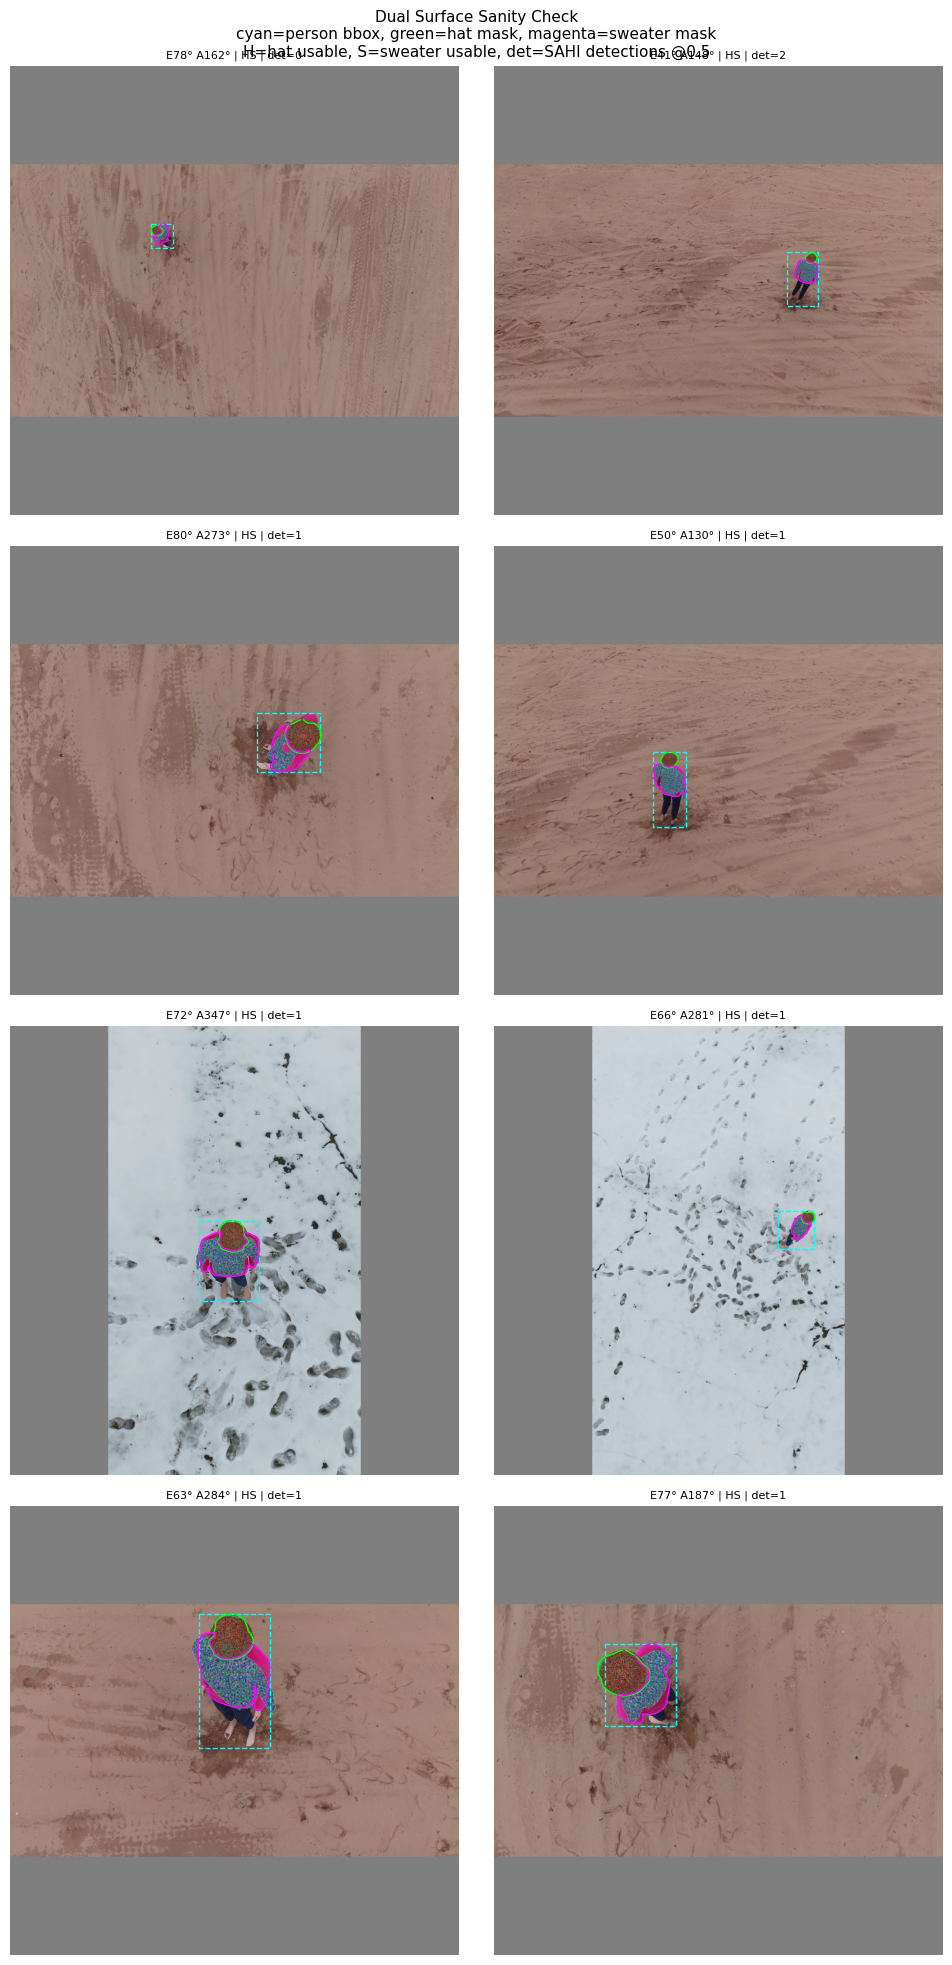

2026-03-29 22:49:13,394 | Rendered texture should appear INSIDE green (hat) and magenta (sweater) outlines
2026-03-29 22:49:13,395 | Sweater texture should be behind hat where they overlap
2026-03-29 22:49:13,396 | Frames marked '-S' should have no sweater texture, '-H' no hat texture
2026-03-29 22:49:13,397 | Every frame should show det >= 1 (untrained texture shouldn't fool detector)


In [13]:
if not SUPER:
    
    #Sanity Check: dual surface compositing on real frames
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type='yolov8',
        model_path='yolov8m.pt',
        confidence_threshold=0.5,
        device=str(device)
    )
    
    logger.info("Sanity check: compositing both surfaces on real frames...")
    num_preview = min(8, len(dataset_all))
    preview_indices = np.random.choice(len(dataset_all), num_preview, replace=False)
    
    cols = 2
    rows = (num_preview + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten()
    
    with torch.no_grad():
        rand_hat_tex = generator_hat.generate(batch_size=1)
        rand_sw_tex = generator_sweater.generate(batch_size=1)
        
        for i, idx in enumerate(preview_indices):
            sample = dataset_all[idx]
            scene = sample['image'].unsqueeze(0).to(device)
            hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
            sweater_mask = sample['sweater_mask'].unsqueeze(0).to(device)
            elev = sample['elevation'].item()
            azim = sample['azimuth'].item()
            scl = sample['scale'].item()
            hat_ok = sample['hat_usable']
            sw_ok = sample['sweater_usable']
            
            gimbal_yaw_val = dataset_all.frames[idx]['drone']['gimbal_yaw_360']
            bearing_val = dataset_all.frames[idx]['drone']['heading']
            gimbal_pitch_val = dataset_all.frames[idx]['drone']['gimbal_pitch_raw']
            
            rh, ah = renderer_hat.render(
                rand_hat_tex,
                elevation=torch.tensor([elev], device=device),
                scale=torch.tensor([scl], device=device),
                bearing=torch.tensor([bearing_val], device=device),
                gimbal_yaw=torch.tensor([gimbal_yaw_val], device=device),
                gimbal_pitch=torch.tensor([gimbal_pitch_val], device=device))
            
            rs, as_ = renderer_sweater.render(
                rand_sw_tex,
                elevation=torch.tensor([elev], device=device),
                scale=torch.tensor([scl], device=device),
                bearing=torch.tensor([bearing_val], device=device),
                gimbal_yaw=torch.tensor([gimbal_yaw_val], device=device),
                gimbal_pitch=torch.tensor([gimbal_pitch_val], device=device))
            
            #Dual composite
            composite = composite_dual_on_scene(
                scene, hat_mask, sweater_mask,
                rh, ah, rs, as_,
                [hat_ok], [sw_ok])
            
            #SAHI detection
            comp_np = (composite[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            comp_bgr = cv2.cvtColor(comp_np, cv2.COLOR_RGB2BGR)
            tmp_path = f"{CONFIG['output_dir']}/tmp_sanity.png"
            cv2.imwrite(tmp_path, comp_bgr)
            sahi_result = get_sliced_prediction(
                tmp_path, sahi_model,
                slice_height=CONFIG['sahi_slice_size'],
                slice_width=CONFIG['sahi_slice_size'],
                overlap_height_ratio=CONFIG['sahi_overlap'],
                overlap_width_ratio=CONFIG['sahi_overlap'],
                verbose=0,
            )
            n_det = sum(1 for p in sahi_result.object_prediction_list if p.category.id == 0)
            
            #Display
            axes[i].imshow(composite[0].permute(1, 2, 0).cpu())
            
            #Person bbox in cyan
            bbox = sample['person_bbox']
            rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1], linewidth=1, edgecolor='cyan', facecolor='none', linestyle='--')
            axes[i].add_patch(rect)
            
            #Hat mask outline in green
            hat_np = hat_mask[0, 0].cpu().numpy()
            contours, _ = cv2.findContours((hat_np > 0.5).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in contours:
                c = c.squeeze()
                if c.ndim == 2 and len(c) > 2:
                    axes[i].plot(c[:, 0], c[:, 1], 'lime', linewidth=1)
            
            #Sweater mask outline in magenta
            sw_np = sweater_mask[0, 0].cpu().numpy()
            contours_sw, _ = cv2.findContours((sw_np > 0.5).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in contours_sw:
                c = c.squeeze()
                if c.ndim == 2 and len(c) > 2:
                    axes[i].plot(c[:, 0], c[:, 1], 'magenta', linewidth=1)
            
            #Labels
            usable_str = f"{'H' if hat_ok else '-'}{'S' if sw_ok else '-'}"
            axes[i].set_title(f'E{elev:.0f}° A{azim:.0f}° | {usable_str} | det={n_det}', fontsize=8)
            axes[i].axis('off')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle('Dual Surface Sanity Check\n'
                 'cyan=person bbox, green=hat mask, magenta=sweater mask\n'
                 'H=hat usable, S=sweater usable, det=SAHI detections @0.5',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/pipeline_check_dual.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info("Rendered texture should appear INSIDE green (hat) and magenta (sweater) outlines")
    logger.info("Sweater texture should be behind hat where they overlap")
    logger.info("Frames marked '-S' should have no sweater texture, '-H' no hat texture")
    logger.info("Every frame should show det >= 1 (untrained texture shouldn't fool detector)")

## 13: Ensamble

Ensamble detection

In [14]:
#Monkey Patching
"""
from ultralytics.nn.modules.block import C2f, Bottleneck
from ultralytics.nn.modules.head import Detect
_orig_c2f = C2f.forward
def _safe_c2f(self, x):
    y = list(self.cv1(x).chunk(2, 1))
    y = [yi.clone() for yi in y]
    for m in self.m:
        y.append(m(y[-1]))
    return self.cv2(torch.cat(y, 1))
C2f.forward = _safe_c2f
_orig_bn = Bottleneck.forward
def _safe_bn(self, x):
    return x.clone() + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))
Bottleneck.forward = _safe_bn
_orig_fh = Detect.forward_head
def _safe_fh(self, x, box_head, cls_head):
    bs = x[0].shape[0]
    boxes = torch.cat([box_head[i](x[i].clone()).reshape(bs, 4 * self.reg_max, -1) for i in range(self.nl)], dim=-1)
    scores = torch.cat([cls_head[i](x[i].clone()).reshape(bs, self.nc, -1) for i in range(self.nl)], dim=-1)
    return dict(boxes=boxes, scores=scores, feats=x)
Detect.forward_head = _safe_fh
"""

class DetectorEnsemble:
    
    def __init__(self, attack_mode='gray', device='cuda', conf_floor=0.001, visdrone_path=None):
        self.device = device
        self.conf_floor = conf_floor
        self.models = {}
        self.weights = {}
        
        #COCO models (same as before)
        if attack_mode == 'white':
            self.models['yolov8m'] = YOLO('yolov8m.pt')
            self.weights['yolov8m'] = 1.0
        elif attack_mode == 'gray':
            model_configs = [
                ('yolov8s', 0.20), ('yolov8m', 0.25), ('yolov8l', 0.20),
                ('yolov5m', 0.20), ('yolov5l', 0.15),
            ]
            for name, weight in model_configs:
                try:
                    self.models[name] = YOLO(f'{name}.pt')
                    self.weights[name] = weight
                    logger.info(f"Loaded {name}")
                except Exception as e:
                    logger.warning(f"Failed to load {name}: {e}")
        elif attack_mode == 'black':
            model_configs = [
                ('yolov8m', 0.30), ('yolov8l', 0.25),
                ('yolov5l', 0.25), ('yolov5m', 0.20),
            ]
            for name, weight in model_configs:
                try:
                    self.models[name] = YOLO(f'{name}.pt')
                    self.weights[name] = weight
                except Exception as e:
                    logger.warning(f"Failed to load {name}: {e}")
        
        #Disable inplace for all COCO models
        for name, model in self.models.items():
            model.model.to(device)
            for m in model.model.modules():
                if hasattr(m, 'inplace'):
                    m.inplace = False
                if isinstance(m, nn.SiLU):
                    m.inplace = False
                if isinstance(m, nn.ReLU):
                    m.inplace = False
        
        #Normalize COCO weights
        total = sum(self.weights.values())
        if total == 0:
            raise RuntimeError("No COCO detector models loaded")
        self.weights = {k: v/total for k, v in self.weights.items()}
        logger.info(f"COCO ensemble ({attack_mode}): {list(self.weights.keys())}")
        
        #VisDrone model (separate, always loaded if available)
        self.visdrone_model = None
        if visdrone_path and Path(visdrone_path).exists():
            self.visdrone_model = YOLO(visdrone_path)
            self.visdrone_model.model.to(device)
            for m in self.visdrone_model.model.modules():
                if hasattr(m, 'inplace'):
                    m.inplace = False
                if isinstance(m, nn.SiLU):
                    m.inplace = False
                if isinstance(m, nn.ReLU):
                    m.inplace = False
            logger.info(f"Loaded VisDrone model from {visdrone_path}")
        else:
            logger.warning(f"VisDrone model not found at {visdrone_path}, using COCO only")
    
    def compute_loss(self, images, return_detections=False):
        total_loss = 0.0
        all_detections = [] if return_detections else None
        for name, model in self.models.items():
            weight = self.weights[name]
            preds = model.model(images)
            if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                person_conf = preds[1]['scores'][:, 0, :]
            elif isinstance(preds, (list, tuple)):
                preds = preds[0]
                if preds.dim() == 3 and preds.shape[1] == 84:
                    person_conf = preds[:, 4, :]
                elif preds.dim() == 3 and preds.shape[2] >= 85:
                    person_conf = preds[..., 4] * preds[..., 5]
                else:
                    continue
            elif isinstance(preds, dict):
                person_conf = preds['scores'][:, 0, :]
            else:
                continue
            B = person_conf.shape[0]
            per_image_loss = []
            for b in range(B):
                img_confs = person_conf[b].reshape(-1)
                k = min(25, img_confs.numel())
                top_confs, _ = img_confs.topk(k)
                per_image_loss.append(top_confs.mean())
            model_loss = torch.stack(per_image_loss).mean()
            total_loss = total_loss + weight * model_loss
        if return_detections:
            return total_loss, all_detections
        return total_loss

    def compute_loss_spatial(self, images, bbox_in_crop, crop_size=640):
        total_loss = 0.0
        for name, model in self.models.items():
            weight = self.weights[name]
            preds = model.model(images)
            if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                person_conf = preds[1]['scores'][:, 0, :]
            elif isinstance(preds, (list, tuple)):
                preds = preds[0]
                if preds.dim() == 3 and preds.shape[1] == 84:
                    person_conf = preds[:, 4, :]
                else:
                    continue
            else:
                continue
            B, N = person_conf.shape
            #Build anchor grid centers (approximate)
            anchor_centers = []
            for grid_h in [80, 40, 20]:
                stride = crop_size / grid_h
                for gy in range(grid_h):
                    for gx in range(grid_h):
                        anchor_centers.append(((gx + 0.5) * stride, (gy + 0.5) * stride))
            anchor_centers = torch.tensor(anchor_centers, device=images.device)  #(8400, 2)
            if anchor_centers.shape[0] != N:
                #Fallback if anchor count doesn't match, use unfiltered
                per_image = []
                for b in range(B):
                    k = min(25, N)
                    top, _ = person_conf[b].topk(k)
                    per_image.append(top.mean())
                total_loss = total_loss + weight * torch.stack(per_image).mean()
                continue
            per_image = []
            for b in range(B):
                bx1, by1, bx2, by2 = bbox_in_crop[b]
                cx = (bx1 + bx2) / 2
                cy = (by1 + by2) / 2
                bw = max((bx2 - bx1).item(), 1)
                bh = max((by2 - by1).item(), 1)
                #Gaussian weight: anchors near the mannequin get a weight 1, far anchors get 0
                radius = max(bw, bh) * 0.75  #75% of bbox size
                dx = anchor_centers[:, 0] - cx
                dy = anchor_centers[:, 1] - cy
                dist_sq = dx ** 2 + dy ** 2
                spatial_weight = torch.exp(-dist_sq / (2 * radius ** 2))
                #Weighted confidence
                weighted_conf = person_conf[b] * spatial_weight
                k = min(25, N)
                top, _ = weighted_conf.topk(k)
                per_image.append(top.mean())
            total_loss = total_loss + weight * torch.stack(per_image).mean()
        return total_loss
    
    def compute_visdrone_loss(self, images):
        if self.visdrone_model is None:
            return torch.tensor(0.0, device=self.device, requires_grad=True)
        preds = self.visdrone_model.model(images)
        if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
            #Classes 0 (pedestrian) and 1 (people)
            scores = preds[1]['scores']
            person_conf = torch.max(scores[:, 0, :], scores[:, 1, :])
        elif isinstance(preds, (list, tuple)):
            preds = preds[0]
            if preds.dim() == 3 and preds.shape[1] > 4:
                #Sum pedestrian + people confidences
                person_conf = preds[:, 4, :]  #objectness or first class
            else:
                return torch.tensor(0.0, device=self.device, requires_grad=True)
        else:
            return torch.tensor(0.0, device=self.device, requires_grad=True)
        B = person_conf.shape[0]
        per_image = []
        for b in range(B):
            confs = person_conf[b].reshape(-1)
            k = min(25, confs.numel())
            top, _ = confs.topk(k)
            per_image.append(top.mean())
        return torch.stack(per_image).mean()
    
    def detect(self, images, conf_threshold=0.5):
        images_np = [(images[i] * 255).byte().permute(1, 2, 0).cpu().numpy() for i in range(images.shape[0])]
        all_results = {}
        for name, model in self.models.items():
            results = model.predict(images_np, conf=self.conf_floor, classes=[0], verbose=False)
            all_results[name] = []
            for r in results:
                if len(r.boxes) > 0:
                    scores = r.boxes.conf.cpu().numpy()
                    boxes = r.boxes.xyxy.cpu().numpy()
                    keep = scores >= conf_threshold
                    all_results[name].append({'boxes': boxes[keep], 'scores': scores[keep]})
                else:
                    all_results[name].append({'boxes': np.array([]), 'scores': np.array([])})
        return all_results

    def compute_loss_per_frame(self, images):
        B = images.shape[0]
        per_frame = torch.zeros(B, device=images.device)
        for name, model in self.models.items():
            weight = self.weights[name]
            preds = model.model(images)
            if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                person_conf = preds[1]['scores'][:, 0, :]
            elif isinstance(preds, (list, tuple)):
                preds = preds[0]
                if preds.dim() == 3 and preds.shape[1] == 84:
                    person_conf = preds[:, 4, :]
                elif preds.dim() == 3 and preds.shape[2] >= 85:
                    person_conf = preds[..., 4] * preds[..., 5]
                else:
                    continue
            elif isinstance(preds, dict):
                person_conf = preds['scores'][:, 0, :]
            else:
                continue
            for b in range(B):
                img_confs = person_conf[b].reshape(-1)
                k = min(25, img_confs.numel())
                top_confs, _ = img_confs.topk(k)
                per_frame[b] = per_frame[b] + weight * top_confs.mean()
        return per_frame

    def compute_loss_single_model(self, images, model_name):
        model = self.models[model_name]
        preds = model.model(images)
        if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
            person_conf = preds[1]['scores'][:, 0, :]
        elif isinstance(preds, (list, tuple)):
            preds = preds[0]
            if preds.dim() == 3 and preds.shape[1] == 84:
                person_conf = preds[:, 4, :]
            elif preds.dim() == 3 and preds.shape[2] >= 85:
                person_conf = preds[..., 4] * preds[..., 5]
            else:
                return torch.zeros(images.shape[0], device=self.device, requires_grad=True)
        elif isinstance(preds, dict):
            person_conf = preds['scores'][:, 0, :]
        else:
            return torch.zeros(images.shape[0], device=self.device, requires_grad=True)
        B = person_conf.shape[0]
        per_frame = torch.zeros(B, device=images.device)
        for b in range(B):
            img_confs = person_conf[b].reshape(-1)
            k = min(25, img_confs.numel())
            top_confs, _ = img_confs.topk(k)
            per_frame[b] = top_confs.mean()
        return per_frame

detector = DetectorEnsemble(
    CONFIG['attack_mode'], device, 
    conf_floor=CONFIG['det_conf_floor'],
    visdrone_path=CONFIG['visdrone_model_path']
)

2026-03-29 22:49:13,603 | COCO ensemble (white): ['yolov8m']
2026-03-29 22:49:13,604 | VisDrone model not found at runs/detect/yolov8m-visdrone/weights/best.pt, using COCO only


## 14: Stage 1: Generator Training

Train the Generator

In [15]:
def save_texture(texture_tensor, path):
    img = (texture_tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

def save_final_texture(texture_batch, config, path, surface='hat'):
    tex = texture_batch[0].detach().cpu().clamp(0, 1)
    if surface == 'sweater':
        out_h = config.get('sweater_texture_output_size_h', tex.shape[1])
        out_w = config.get('sweater_texture_output_size_w', tex.shape[2])
    else:
        out_h = config.get('texture_output_size_h', tex.shape[1])
        out_w = config.get('texture_output_size_w', tex.shape[2])
    tex_up = F.interpolate(tex.unsqueeze(0), size=(out_h, out_w), mode='bilinear', align_corners=False).squeeze(0)
    img = (tex_up.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    logger.info(f"Saved {surface} texture: {path} ({out_w}x{out_h}px)")

def export_print_template(texture_batch, mesh_path, config, path):
    save_final_texture(texture_batch, config, path)

def _render_dual(batch, texture_hat, texture_sw, renderer_hat, renderer_sweater, config, device, jitter=False):
    B = texture_hat.shape[0]
    
    elevs_h, bearings_h, gys_h, gps_h, scls_h = [], [], [], [], []
    elevs_s, bearings_s, gys_s, gps_s, scls_s = [], [], [], [], []
    
    for i in range(B):
        elev = batch['elevation'][i].item()
        bearing = batch['bearing'][i].item()
        gy = batch['gimbal_yaw'][i].item()
        gp = batch['gimbal_pitch_raw'][i].item()
        scl = batch['scale'][i].item()
        
        if jitter:
            #Hat: wide heading jitter (symmetric top)
            e_h, _, s_h = apply_viewpoint_jitter(
                elev, 0, scl,
                config['hat_pitch_jitter'], 0, config['scale_jitter'])
            b_h = bearing  #bearing jitter not needed, hat is symmetric
            
            #Sweater: narrow heading jitter (front != back)
            e_s, _, s_s = apply_viewpoint_jitter(
                elev, 0, scl,
                config['sweater_pitch_jitter'], 0, config['scale_jitter'])
            b_s = bearing
        else:
            e_h, b_h, s_h = elev, bearing, scl
            e_s, b_s, s_s = elev, bearing, scl
        
        elevs_h.append(e_h); bearings_h.append(b_h); gys_h.append(gy)
        gps_h.append(gp); scls_h.append(s_h)
        elevs_s.append(e_s); bearings_s.append(b_s); gys_s.append(gy)
        gps_s.append(gp); scls_s.append(s_s)
    
    rh, ah = renderer_hat.render(texture_hat,
        elevation=torch.tensor(elevs_h, dtype=torch.float32, device=device),
        scale=torch.tensor(scls_h, dtype=torch.float32, device=device),
        bearing=torch.tensor(bearings_h, dtype=torch.float32, device=device),
        gimbal_yaw=torch.tensor(gys_h, dtype=torch.float32, device=device),
        gimbal_pitch=torch.tensor(gps_h, dtype=torch.float32, device=device))
    
    rs, as_ = renderer_sweater.render(texture_sw,
        elevation=torch.tensor(elevs_s, dtype=torch.float32, device=device),
        scale=torch.tensor(scls_s, dtype=torch.float32, device=device),
        bearing=torch.tensor(bearings_s, dtype=torch.float32, device=device),
        gimbal_yaw=torch.tensor(gys_s, dtype=torch.float32, device=device),
        gimbal_pitch=torch.tensor(gps_s, dtype=torch.float32, device=device))
    
    return rh, ah, rs, as_


def train_stage1(generator_hat, generator_sweater, aux_net_hat, aux_net_sweater, detector, renderer_hat, renderer_sweater, dataset, config, bn_size, opt_g=None, opt_aux=None):
    renderer_hat.training_mode = True
    renderer_sweater.training_mode = True
    generator_hat.train()
    generator_sweater.train()
    aux_net_hat.train()
    aux_net_sweater.train()
    
    all_params = list(generator_hat.parameters()) + list(generator_sweater.parameters())
    aux_params = list(aux_net_hat.parameters()) + list(aux_net_sweater.parameters())
    
    #Use passed optimizers or create new ones
    if opt_g is None:
        opt_g = torch.optim.Adam(all_params, lr=config['stage1_lr'], betas=(0.5, 0.999))
    if opt_aux is None:
        opt_aux = torch.optim.Adam(aux_params, lr=config['stage1_lr'] * 5, betas=(0.5, 0.999))
 
    
    #Distance-weighted sampling (1.5x for far frames)
    distances = np.array([
        dataset.frames[i]['drone'].get('distance_3d_meters',
            dataset.frames[i]['drone'].get('altitude_meters', 5.0))
        for i in range(len(dataset))
    ])
    weights = np.clip(distances / 6.0, 1.0, 1.5)
    sampler = torch.utils.data.WeightedRandomSampler(weights, len(dataset), replacement=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=config['stage1_batch_size'], sampler=sampler, num_workers=config['num_workers'], pin_memory=True, persistent_workers=True)
    
    use_augmentation = True
    num_epochs = config.get('phase_s1_epochs', 150)
    
    logger.info(f"Starting Stage 1 (bn={bn_size}, {num_epochs} epochs)...")
    for epoch in range(num_epochs):
        epoch_losses = {'total': 0, 'crop': 0, 'deploy': 0, 'tv': 0, 'nps': 0, 'mi': 0}
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch_idx, batch in enumerate(pbar):
            B = batch['image'].shape[0]
            
            #Generate textures
            z_hat = torch.randn(B, config['latent_channels'], config['latent_size'], config['latent_size'], device=device)
            z_sw = torch.randn(B, config['latent_channels'], config['latent_size'], config['latent_size'], device=device)
            tex_hat = generator_hat.generate(z_hat)
            tex_sw = generator_sweater.generate(z_sw)
            
            ##tex_hat = frequency_bottleneck(tex_hat, bn_size)
            ##tex_sw = frequency_bottleneck(tex_sw, bn_size)
            current_bn = get_bottleneck_size(epoch, config)
            tex_hat = frequency_bottleneck(tex_hat, current_bn)
            tex_sw = frequency_bottleneck(tex_sw, current_bn)
            
            #Render
            rh, ah, rs, as_ = _render_dual(batch, tex_hat, tex_sw, renderer_hat, renderer_sweater,config, device, jitter=use_augmentation)
            
            #Augmentations
            if use_augmentation:
                rh = patch_cutout(rh, ah, config['cutout_prob'], config['cutout_ratio'])
                rh = add_light_spots(rh, ah)
                rh = add_shadows(rh, ah)
                rh = simulate_printing(rh)
                rs = simulate_printing(rs)
            
            #Composite (1920x1920 letterboxed)
            scene = batch['image'].to(device)
            hat_mask = batch['hat_mask'].to(device)
            sweater_mask = batch['sweater_mask'].to(device)
            hat_usable = [batch['hat_usable'][i] for i in range(B)]
            sw_usable = [batch['sweater_usable'][i] for i in range(B)]
            
            composite = composite_dual_on_scene(scene, hat_mask, sweater_mask, rh, ah, rs, as_, hat_usable, sw_usable)
            person_bboxes = batch['person_bbox'].to(device)
            
            #Stream 1: Crop (gradient engine, all models)
            crops = crop_to_person(composite, person_bboxes, target_size=config['detector_input_size'])
            loss_crop_pf = detector.compute_loss_per_frame(crops)  #(B,)
            
            #Stream 2: Deployment ensemble (each member = model + pipeline)
            deploy_pf = torch.zeros(B, device=device)
            n_deploy_members = len(config['deployment_ensemble'])
            for member in config['deployment_ensemble']:
                model_name = member['model']
                if member['pipeline'] == 'fullframe':
                    ff_resized = F.interpolate(composite, size=(640, 640), mode='bilinear', align_corners=False)
                    deploy_pf = deploy_pf + detector.compute_loss_single_model(ff_resized, model_name)
                elif member['pipeline'] == 'sahi':
                    sahi_pf = compute_sahi_loss_fullres(
                        batch, dataset, rh, ah, rs, as_, detector, config,
                        slice_size=member['slice'], overlap=member['overlap'],
                        target_size=config['detector_input_size'],
                        model_name=model_name)
                    deploy_pf = deploy_pf + sahi_pf
            if n_deploy_members > 0:
                deploy_pf = deploy_pf / n_deploy_members
            
            #Stream weighting (2 streams)
            per_frame_losses = []
            for i in range(B):
                dist_i = batch['distance_3d'][i].item()
                w_crop = max(0.3, 0.8 * (1.0 - (dist_i - 3.0) / 15.0))
                w_deploy = 0.2
                total_w = w_crop + w_deploy
                per_frame_losses.append(
                    (w_crop/total_w) * loss_crop_pf[i] +
                    (w_deploy/total_w) * deploy_pf[i]
                )
            loss_det = torch.stack(per_frame_losses).mean()
            
            #Regularization
            loss_tv = (total_variation_loss(tex_hat) + total_variation_loss(tex_sw)) / 2
            loss_nps = (printer_gamut.nps_loss(tex_hat) + printer_gamut.nps_loss(tex_sw)) / 2
            loss_mi = (compute_mi_loss(aux_net_hat, tex_hat, z_hat) + compute_mi_loss(aux_net_sweater, tex_sw, z_sw)) / 2
            
            if epoch < 5: #and bn_size == config['training_phases'][0]['bn_size']:
                loss = (config['lambda_tv'] * loss_tv + config['lambda_nps'] * loss_nps +
                        config['lambda_info'] * loss_mi)
            else:
                loss = (loss_det + config['lambda_tv'] * loss_tv +
                        config['lambda_nps'] * loss_nps + config['lambda_info'] * loss_mi)
            
            opt_g.zero_grad()
            opt_aux.zero_grad()
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(all_params, 1.0)
                torch.nn.utils.clip_grad_norm_(aux_params, 1.0)
                opt_g.step()
                opt_aux.step()
            
            epoch_losses['total'] += loss.item()
            epoch_losses['crop'] += loss_crop_pf.mean().item()
            epoch_losses['deploy'] += deploy_pf.mean().item()
            epoch_losses['tv'] += loss_tv.item()
            epoch_losses['nps'] += loss_nps.item()
            epoch_losses['mi'] += loss_mi.item()
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'crop': f"{loss_crop_pf.mean().item():.4f}",
                'deploy': f"{deploy_pf.mean().item():.4f}",
                'bn': current_bn,
            })
        
        n = len(dataloader)
        for k in epoch_losses:
            epoch_losses[k] /= n
        logger.info(f"Epoch {epoch+1} - total={epoch_losses['total']:.4f} "
                    f"crop={epoch_losses['crop']:.4f} deploy={epoch_losses['deploy']:.4f} "
                    f"tv={epoch_losses['tv']:.4f} mi={epoch_losses['mi']:.4f} bn={current_bn}")
        
        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                s_h = generator_hat.generate(batch_size=1)
                s_s = generator_sweater.generate(batch_size=1)
                save_texture(s_h[0], f"{config['output_dir']}/hat_tex_epoch{epoch+1}_bn{current_bn}.png")
                save_texture(s_s[0], f"{config['output_dir']}/sweater_tex_epoch{epoch+1}_bn{current_bn}.png")

        if epoch == 0:
            for name, param in generator_hat.named_parameters():
                if param.grad is not None:
                    logger.info(f"  GRAD hat {name}: mean={param.grad.abs().mean():.6f}")
                    break
            for name, param in generator_sweater.named_parameters():
                if param.grad is not None:
                    logger.info(f"  GRAD sweater {name}: mean={param.grad.abs().mean():.6f}")
                    break
    
    renderer_hat.training_mode = False
    renderer_sweater.training_mode = False
    return generator_hat, generator_sweater

## 15: Stage 2: Latent Optimization

Optimize the Latent

In [16]:
def train_stage2(generator_hat, generator_sweater, detector, renderer_hat, renderer_sweater, dataset, config, bn_size, toroidal_hat=None, toroidal_sw=None, opt_s2=None):
    renderer_hat.training_mode = True
    renderer_sweater.training_mode = True
    generator_hat.eval()
    generator_sweater.eval()
    
    #Use passed toroidals or create new ones
    if toroidal_hat is None:
        toroidal_hat = ToroidalLatent(local_size=config['local_latent_size'], crop_size=config['latent_size'], latent_channels=config['latent_channels'], device=device)
    if toroidal_sw is None:
        toroidal_sw = ToroidalLatent(local_size=config['local_latent_size'], crop_size=config['latent_size'], latent_channels=config['latent_channels'], device=device)
    
    #Use passed optimizer or create new one
    if opt_s2 is None:
        opt_s2 = torch.optim.Adam([
            {'params': toroidal_hat.parameters(), 'lr': config['stage2_lr']},
            {'params': toroidal_sw.parameters(), 'lr': config['stage2_lr']},
            {'params': generator_hat.parameters(), 'lr': config['stage2_generator_lr']},
            {'params': generator_sweater.parameters(), 'lr': config['stage2_generator_lr']},
        ])
    optimizer = opt_s2
    
    num_iters = config.get('phase_s2_iters', 10000)

    optimizer.param_groups[0]['lr'] = config['stage2_lr'] #toroidal_hat
    optimizer.param_groups[1]['lr'] = config['stage2_lr'] #toroidal_sw
    optimizer.param_groups[2]['lr'] = config['stage2_generator_lr'] #gen_hat
    optimizer.param_groups[3]['lr'] = config['stage2_generator_lr'] #gen_sw
    
    #Fresh per-phase scheduler with warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=max(1, num_iters // 3), T_mult=1, eta_min=1e-5)
    
    #Distance-weighted sampling
    distances = np.array([
        dataset.frames[i]['drone'].get('distance_3d_meters', dataset.frames[i]['drone'].get('altitude_meters', 5.0))
        for i in range(len(dataset))
    ])
    weights = np.clip(distances / 6.0, 1.0, 1.5)
    sampler = torch.utils.data.WeightedRandomSampler(weights, len(dataset), replacement=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=config['stage2_batch_size'], sampler=sampler, num_workers=config['num_workers'], pin_memory=True, persistent_workers=True)
    data_iter = iter(dataloader)
    
    best_ema_loss = float('inf')
    ema_loss = 0.0
    ema_alpha = 0.01
    best_z_hat = toroidal_hat.z_local.data.clone()
    best_z_sw = toroidal_sw.z_local.data.clone()
    best_gen_hat_state = {k: v.clone() for k, v in generator_hat.state_dict().items()}
    best_gen_sw_state = {k: v.clone() for k, v in generator_sweater.state_dict().items()}
    
    use_augmentation = True
    
    logger.info(f"Starting Stage 2 (bn={bn_size}, {num_iters} iters)...")
    pbar = tqdm(range(num_iters), desc="Stage 2")
    
    for iteration in pbar:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)
        
        B = batch['image'].shape[0]
        
        z_h = toroidal_hat.get_canonical_crop().expand(B, -1, -1, -1)
        z_s = toroidal_sw.get_canonical_crop().expand(B, -1, -1, -1)
        tex_hat = frequency_bottleneck(generator_hat.generate(z_h), bn_size)
        tex_sw = frequency_bottleneck(generator_sweater.generate(z_s), bn_size)
        
        rh, ah, rs, as_ = _render_dual(batch, tex_hat, tex_sw, renderer_hat, renderer_sweater, config, device, jitter=use_augmentation)
        
        if use_augmentation:
            rh = patch_cutout(rh, ah, config['cutout_prob'], config['cutout_ratio'])
            rh = add_light_spots(rh, ah)
            rh = add_shadows(rh, ah)
            rh = simulate_printing(rh)
            rs = simulate_printing(rs)
        
        scene = batch['image'].to(device)
        hat_mask = batch['hat_mask'].to(device)
        sweater_mask = batch['sweater_mask'].to(device)
        hat_usable = [batch['hat_usable'][i] for i in range(B)]
        sw_usable = [batch['sweater_usable'][i] for i in range(B)]
        
        composite = composite_dual_on_scene(scene, hat_mask, sweater_mask, rh, ah, rs, as_, hat_usable, sw_usable)
        person_bboxes = batch['person_bbox'].to(device)
        
        #Stream 1: Crop
        crops = crop_to_person(composite, person_bboxes, target_size=config['detector_input_size'])
        loss_crop_pf = detector.compute_loss_per_frame(crops)
        
        #Stream 2: Deployment ensemble
        deploy_pf = torch.zeros(B, device=device)
        n_deploy_members = len(config['deployment_ensemble'])
        for member in config['deployment_ensemble']:
            model_name = member['model']
            if member['pipeline'] == 'fullframe':
                ff_resized = F.interpolate(composite, size=(640, 640),
                                            mode='bilinear', align_corners=False)
                deploy_pf = deploy_pf + detector.compute_loss_single_model(ff_resized, model_name)
            elif member['pipeline'] == 'sahi':
                sahi_pf = compute_sahi_loss_fullres(
                    batch, dataset, rh, ah, rs, as_, detector, config,
                    slice_size=member['slice'], overlap=member['overlap'],
                    target_size=config['detector_input_size'],
                    model_name=model_name)
                deploy_pf = deploy_pf + sahi_pf
        if n_deploy_members > 0:
            deploy_pf = deploy_pf / n_deploy_members
        
        #Per-frame weighting (crop-dominant)
        per_frame_losses = []
        for i in range(B):
            dist_i = batch['distance_3d'][i].item()
            w_crop = max(0.3, 0.8 * (1.0 - (dist_i - 3.0) / 15.0))
            w_deploy = 0.2
            total_w = w_crop + w_deploy
            per_frame_losses.append(
                (w_crop/total_w) * loss_crop_pf[i] +
                (w_deploy/total_w) * deploy_pf[i]
            )
        loss_det = torch.stack(per_frame_losses).mean()
        
        loss_tv = (total_variation_loss(tex_hat) + total_variation_loss(tex_sw)) / 2
        loss_nps = (printer_gamut.nps_loss(tex_hat) + printer_gamut.nps_loss(tex_sw)) / 2
        
        loss = loss_det + config['lambda_tv'] * loss_tv + config['lambda_nps'] * loss_nps
        
        optimizer.zero_grad()
        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(toroidal_hat.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(toroidal_sw.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        
        lv = loss.item()
        ema_loss = ema_alpha * lv + (1 - ema_alpha) * ema_loss if iteration > 0 else lv
        
        if ema_loss < best_ema_loss:
            best_ema_loss = ema_loss
            best_z_hat = toroidal_hat.z_local.data.clone()
            best_z_sw = toroidal_sw.z_local.data.clone()
            best_gen_hat_state = {k: v.clone() for k, v in generator_hat.state_dict().items()}
            best_gen_sw_state = {k: v.clone() for k, v in generator_sweater.state_dict().items()}
        
        pbar.set_postfix({
            'loss': f"{lv:.4f}", 'best': f"{best_ema_loss:.4f}",
            'crop': f"{loss_crop_pf.mean().item():.4f}",
            'deploy': f"{deploy_pf.mean().item():.4f}",
        })
        
        if (iteration + 1) % 500 == 0:
            with torch.no_grad():
                zh = toroidal_hat.get_canonical_crop()
                zs = toroidal_sw.get_canonical_crop()
                save_texture(frequency_bottleneck(generator_hat.generate(zh), bn_size)[0],
                    f"{config['output_dir']}/hat_s2_iter{iteration+1}_bn{bn_size}.png")
                save_texture(frequency_bottleneck(generator_sweater.generate(zs), bn_size)[0],
                    f"{config['output_dir']}/sweater_s2_iter{iteration+1}_bn{bn_size}.png")
    
    #Restore best z only (generator weights are continuous with persistent optimizer)
    toroidal_hat.z_local.data = best_z_hat
    toroidal_sw.z_local.data = best_z_sw
    generator_hat.load_state_dict(best_gen_hat_state)
    generator_sweater.load_state_dict(best_gen_sw_state)
    
    with torch.no_grad():
        final_hat = frequency_bottleneck(generator_hat.generate(toroidal_hat.get_canonical_crop()), bn_size)
        final_sw = frequency_bottleneck(generator_sweater.generate(toroidal_sw.get_canonical_crop()), bn_size)
    
    save_final_texture(final_hat, config, f"{config['output_dir']}/final_hat_texture_bn{bn_size}.png", 'hat')
    save_final_texture(final_sw, config, f"{config['output_dir']}/final_sweater_texture_bn{bn_size}.png", 'sweater')
    
    torch.save({
        'z_local_hat': best_z_hat, 'z_local_sweater': best_z_sw,
        'generator_hat': generator_hat.state_dict(),
        'generator_sweater': generator_sweater.state_dict(),
        'bn_size': bn_size,
    }, f"{config['output_dir']}/stage2_bn{bn_size}.pth")
    
    renderer_hat.training_mode = False
    renderer_sweater.training_mode = False
    logger.info(f"Stage 2 (bn={bn_size}) complete. Best EMA loss: {best_ema_loss:.4f}")
    return toroidal_hat.z_local.data.clone(), toroidal_sw.z_local.data.clone(), final_hat, final_sw

## 16: Evaluation

See how we did

In [17]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import shutil

def evaluate_and_visualize(generator_hat, generator_sweater, detector, renderer_hat, renderer_sweater, dataset, z_local_hat, z_local_sw, config):
    renderer_hat.training_mode = False
    renderer_sweater.training_mode = False
    generator_hat.eval()
    generator_sweater.eval()
    
    toroidal_hat = ToroidalLatent(local_size=config['local_latent_size'], crop_size=config['latent_size'], latent_channels=config['latent_channels'], device=device)
    toroidal_sw = ToroidalLatent(local_size=config['local_latent_size'], crop_size=config['latent_size'], latent_channels=config['latent_channels'], device=device)
    toroidal_hat.z_local.data = z_local_hat
    toroidal_sw.z_local.data = z_local_sw
    
    with torch.no_grad():
        best_hat_tex = frequency_bottleneck(generator_hat.generate(toroidal_hat.get_canonical_crop()), config['freq_bottleneck']['stage2'])
        best_sw_tex = frequency_bottleneck(generator_sweater.generate(toroidal_sw.get_canonical_crop()), config['freq_bottleneck']['stage2'])
    
    total_frames = len(dataset)
    tmp_dir = Path(config['output_dir']) / 'eval_tmp'
    tmp_dir.mkdir(exist_ok=True)
    
    #1: Write baseline + attack images at origional resolution for SAHI eval
    patch_pixel_counts = {}
    logger.info("Writing baseline and attack images at original resolution...")
    with torch.no_grad():
        for idx in range(total_frames):
            orig_img, orig_hm, orig_sm, orig_bbox = dataset.get_original_data(idx)
            
            #Baseline: original image
            baseline_np = (orig_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            cv2.imwrite(str(tmp_dir / f'baseline_{idx}.png'), cv2.cvtColor(baseline_np, cv2.COLOR_RGB2BGR))
            
            #Rendering params from frame metadata
            frame = dataset.frames[idx]
            drone = frame['drone']
            elev = drone['camera_pitch']
            bearing = drone['heading']
            gy = drone['gimbal_yaw_360']
            gp = drone['gimbal_pitch_raw']
            dist = drone.get('distance_3d_meters', drone.get('altitude_meters', 5.0))
            scl = dataset._distance_to_scale(dist)
            hat_ok = frame.get('hat_usable', True)
            sw_ok = frame.get('sweater_usable', False)
            hat_px = int((orig_hm > 0.5).sum().item()) if hat_ok else 0
            sw_px = int((orig_sm > 0.5).sum().item()) if sw_ok else 0
            patch_pixel_counts[idx] = hat_px + sw_px
            
            rh, ah = renderer_hat.render(best_hat_tex,elevation=torch.tensor([elev], device=device),scale=torch.tensor([scl], device=device),bearing=torch.tensor([bearing], device=device),gimbal_yaw=torch.tensor([gy], device=device),gimbal_pitch=torch.tensor([gp], device=device))
            rs, as_ = renderer_sweater.render(best_sw_tex,elevation=torch.tensor([elev], device=device),scale=torch.tensor([scl], device=device),bearing=torch.tensor([bearing], device=device),gimbal_yaw=torch.tensor([gy], device=device), gimbal_pitch=torch.tensor([gp], device=device))
            
            #Composite at original resolution
            orig_dev = orig_img.unsqueeze(0).to(device)
            hm_dev = orig_hm.unsqueeze(0).to(device)
            sm_dev = orig_sm.unsqueeze(0).to(device)
            composite = composite_dual_on_scene(orig_dev, hm_dev, sm_dev, rh, ah, rs, as_, [hat_ok], [sw_ok])
            
            attack_np = (composite[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(str(tmp_dir / f'attack_{idx}.png'), cv2.cvtColor(attack_np, cv2.COLOR_RGB2BGR))
            
            del orig_dev, hm_dev, sm_dev, composite
            if idx % 100 == 0:
                logger.info(f"  {idx}/{total_frames}...")
    
    #2: CROP-BASED EVALUATION
    logger.info("\n" + "=" * 60)
    logger.info("CROP-BASED EVALUATION")
    logger.info("=" * 60)
    crop_baseline_det = 0
    crop_attack_det = 0
    crop_conf_drops = []
    crop_frame_results = []
    with torch.no_grad():
        for idx in range(total_frames):
            sample = dataset[idx]
            scene = sample['image'].unsqueeze(0).to(device)
            hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
            sweater_mask = sample['sweater_mask'].unsqueeze(0).to(device)
            bbox = sample['person_bbox'].unsqueeze(0).to(device)
            elev = sample['elevation'].item()
            scl = sample['scale'].item()
            bearing = sample['bearing'].item()
            gy = sample['gimbal_yaw'].item()
            gp = sample['gimbal_pitch_raw'].item()
            hat_ok = sample['hat_usable']
            sw_ok = sample['sweater_usable']
            
            clean_crop = crop_to_person(scene, bbox, target_size=config['detector_input_size'])
            clean_results = detector.detect(clean_crop, conf_threshold=0.25)
            clean_found, clean_conf = False, 0.0
            for name, dets in clean_results.items():
                if len(dets[0]['scores']) > 0:
                    c = float(dets[0]['scores'].max())
                    if c > clean_conf:
                        clean_conf = c
                        clean_found = True
            if clean_found:
                crop_baseline_det += 1
            
            rh, ah = renderer_hat.render(best_hat_tex,
                elevation=torch.tensor([elev], device=device),
                scale=torch.tensor([scl], device=device),
                bearing=torch.tensor([bearing], device=device),
                gimbal_yaw=torch.tensor([gy], device=device),
                gimbal_pitch=torch.tensor([gp], device=device))
            
            rs, as_ = renderer_sweater.render(best_sw_tex,
                elevation=torch.tensor([elev], device=device),
                scale=torch.tensor([scl], device=device),
                bearing=torch.tensor([bearing], device=device),
                gimbal_yaw=torch.tensor([gy], device=device),
                gimbal_pitch=torch.tensor([gp], device=device))
            
            composite = composite_dual_on_scene(scene, hat_mask, sweater_mask, rh, ah, rs, as_, [hat_ok], [sw_ok])
            
            attack_crop = crop_to_person(composite, bbox, target_size=config['detector_input_size'])
            attack_results = detector.detect(attack_crop, conf_threshold=0.25)
            attack_found, attack_conf = False, 0.0
            for name, dets in attack_results.items():
                if len(dets[0]['scores']) > 0:
                    c = float(dets[0]['scores'].max())
                    if c > attack_conf:
                        attack_conf = c
                        attack_found = True
            if attack_found:
                crop_attack_det += 1
            if clean_found:
                crop_conf_drops.append(clean_conf - attack_conf)
            crop_frame_results.append({
                'frame_idx': idx, 'baseline_detected': clean_found,
                'baseline_conf': round(clean_conf, 3),
                'attack_detected': attack_found, 'attack_conf': round(attack_conf, 3),
                'suppressed': clean_found and not attack_found,
            })
    
    crop_suppressed = crop_baseline_det - crop_attack_det
    crop_asr = crop_suppressed / crop_baseline_det if crop_baseline_det > 0 else 0.0
    crop_avg_drop = np.mean(crop_conf_drops) if crop_conf_drops else 0.0
    logger.info(f"  Baseline: {crop_baseline_det}/{total_frames} ({crop_baseline_det/total_frames:.1%})")
    logger.info(f"  Attack:   {crop_attack_det}/{total_frames}")
    logger.info(f"  ASR:      {crop_suppressed}/{crop_baseline_det} ({crop_asr:.1%})")
    logger.info(f"  Avg drop: {crop_avg_drop:.3f}")
    
    #3: DEPLOYMENT ENSEMBLE EVALUATION
    eval_sahi_models = {}  #cache per model_name
    
    #Build eval configs from deployment ensemble
    eval_configs = [{'name': 'crop_640', 'method': 'crop'}]  #crop already done above
    for member in config.get('deployment_ensemble', []):
        model_name = member['model']
        if member['pipeline'] == 'fullframe':
            eval_configs.append({
                'name': f"{model_name}_fullframe",
                'method': 'fullframe',
                'model': model_name,
            })
        elif member['pipeline'] == 'sahi':
            eval_configs.append({
                'name': f"{model_name}_sahi_{member['slice']}_{member['overlap']}",
                'method': 'sahi',
                'slice': member['slice'],
                'overlap': member['overlap'],
                'model': model_name,
            })
    
    thresholds = [0.3, 0.5, 0.7]
    all_results = {'crop_640': {'thresholds': {}, 'frame_results': crop_frame_results}}
    for thresh in thresholds:
        base_det = sum(1 for r in crop_frame_results if r['baseline_conf'] >= thresh)
        suppressed = sum(1 for r in crop_frame_results if r['baseline_conf'] >= thresh and r['attack_conf'] < thresh)
        all_results['crop_640']['thresholds'][thresh] = {
            'baseline_detected': base_det, 'suppressed': suppressed,
            'asr': suppressed / base_det if base_det > 0 else 0.0,
        }
    
    for ec in eval_configs:
        if ec['method'] == 'crop':
            continue  #already done
        
        logger.info(f"\n--- {ec['name']} ---")
        model_name = ec.get('model', list(detector.models.keys())[0])
        
        this_results = []
        for idx in range(total_frames):
            bp = str(tmp_dir / f'baseline_{idx}.png')
            ap = str(tmp_dir / f'attack_{idx}.png')
            
            if ec['method'] == 'fullframe':
                yolo_m = detector.models[model_name]
                base_img = cv2.resize(cv2.imread(bp), (640, 640))
                atk_img = cv2.resize(cv2.imread(ap), (640, 640))
                bd = yolo_m.predict(base_img, conf=0.1, classes=[0], verbose=False)
                ad = yolo_m.predict(atk_img, conf=0.1, classes=[0], verbose=False)
                b_conf = float(bd[0].boxes.conf.max()) if len(bd[0].boxes) > 0 else 0.0
                a_conf = float(ad[0].boxes.conf.max()) if len(ad[0].boxes) > 0 else 0.0
            elif ec['method'] == 'sahi':
                if model_name not in eval_sahi_models:
                    model_path = f'{model_name}.pt'
                    eval_sahi_models[model_name] = AutoDetectionModel.from_pretrained(model_type='yolov8', model_path=model_path, confidence_threshold=0.1, device=str(device))
                sahi_m = eval_sahi_models[model_name]
                br = get_sliced_prediction(bp, sahi_m, slice_height=ec['slice'],slice_width=ec['slice'], overlap_height_ratio=ec['overlap'],overlap_width_ratio=ec['overlap'], verbose=0)
                ar = get_sliced_prediction(ap, sahi_m, slice_height=ec['slice'],slice_width=ec['slice'], overlap_height_ratio=ec['overlap'],overlap_width_ratio=ec['overlap'], verbose=0)
                bp_ = [p for p in br.object_prediction_list if p.category.id == 0]
                ap_ = [p for p in ar.object_prediction_list if p.category.id == 0]
                b_conf = max(p.score.value for p in bp_) if bp_ else 0.0
                a_conf = max(p.score.value for p in ap_) if ap_ else 0.0
            
            this_results.append({
                'frame_idx': idx,
                'baseline_conf': round(b_conf, 3),
                'attack_conf': round(a_conf, 3),
                'suppressed': b_conf >= 0.5 and a_conf < 0.5,
            })
        
        thresh_results = {}
        for thresh in thresholds:
            bd = sum(1 for r in this_results if r['baseline_conf'] >= thresh)
            sp = sum(1 for r in this_results if r['baseline_conf'] >= thresh and r['attack_conf'] < thresh)
            thresh_results[thresh] = {'baseline_detected': bd, 'suppressed': sp, 'asr': sp / bd if bd > 0 else 0.0}
        all_results[ec['name']] = {'thresholds': thresh_results, 'frame_results': this_results}
        t5 = thresh_results.get(0.5, {})
        logger.info(f"  ASR@0.5: {t5.get('asr', 0):.1%} ({t5.get('suppressed', 0)}/{t5.get('baseline_detected', 0)})")

    #4: EXPANDED DISTANCE-BASED DIAGNOSTIC
    logger.info("\nRunning expanded distance diagnostic...")
    eval_modes = []
    for member in config.get('deployment_ensemble', []):
        if member['pipeline'] == 'fullframe':
            eval_modes.append({
                'name': f"{member['model']}_fullframe",
                'method': 'fullframe',
                'model': member['model'],
            })
        elif member['pipeline'] == 'sahi':
            eval_modes.append({
                'name': f"{member['model']}_sahi_{member['slice']}_{member['overlap']}",
                'method': 'sahi',
                'slice': member['slice'],
                'overlap': member['overlap'],
                'model': member['model'],
            })
    
    #Fallback if no deployment ensemble defined
    if not eval_modes:
        eval_modes = [
            {'name': 'fullframe_640', 'method': 'fullframe'},
            {'name': 'sahi_train_close', 'method': 'sahi', 'slice': 1920, 'overlap': 0.0},
            {'name': 'sahi_train_mid', 'method': 'sahi', 'slice': 960, 'overlap': 0.15},
            {'name': 'sahi_train_far', 'method': 'sahi', 'slice': 640, 'overlap': 0.15},
        ]
    
    sahi_eval_model_expanded = AutoDetectionModel.from_pretrained(model_type='yolov8', model_path='yolov8m.pt', confidence_threshold=0.1, device=str(device))
    yolo_eval = list(detector.models.values())[0]
    
    frame_data = []
    for idx in range(total_frames):
        sample = dataset[idx]
        dist = sample['distance_3d'].item()
        elev = sample['elevation'].item()
        azim = sample['azimuth'].item()
        hat_ok = sample['hat_usable']
        sw_ok = sample['sweater_usable']
        bp = str(tmp_dir / f'baseline_{idx}.png')
        ap = str(tmp_dir / f'attack_{idx}.png')
        base_img = cv2.imread(bp)
        atk_img = cv2.imread(ap)
        
        row = {
            'idx': idx, 'distance': dist, 'elevation': elev, 'azimuth': azim,
            'hat_usable': hat_ok, 'sweater_usable': sw_ok,
        }
        row['patch_pixels'] = patch_pixel_counts.get(idx, 0)
        
        for mode in eval_modes:
            if mode['method'] == 'fullframe':
                base_640 = cv2.resize(base_img, (640, 640))
                atk_640 = cv2.resize(atk_img, (640, 640))
                #Use specific model if specified, otherwise first model
                model_key = mode.get('model', list(detector.models.keys())[0])
                yolo_m = detector.models[model_key]
                br = yolo_m.predict(base_640, conf=0.1, classes=[0], verbose=False)
                ar = yolo_m.predict(atk_640, conf=0.1, classes=[0], verbose=False)
                b_conf = float(br[0].boxes.conf.max()) if len(br[0].boxes) > 0 else 0.0
                a_conf = float(ar[0].boxes.conf.max()) if len(ar[0].boxes) > 0 else 0.0
            else:
                #For SAHI eval, create model-specific SAHI detector
                model_key = mode.get('model', 'yolov8m')
                #Map model name to weight file
                model_path = f'{model_key}.pt'
                if model_key == list(detector.models.keys())[0]:
                    sahi_m = sahi_eval_model_expanded  #reuse if same model
                else:
                    sahi_m = AutoDetectionModel.from_pretrained(model_type='yolov8', model_path=model_path,confidence_threshold=0.1, device=str(device))
                
                br = get_sliced_prediction(bp, sahi_m,slice_height=mode['slice'], slice_width=mode['slice'],overlap_height_ratio=mode['overlap'],overlap_width_ratio=mode['overlap'], verbose=0)
                ar = get_sliced_prediction(ap, sahi_m,slice_height=mode['slice'], slice_width=mode['slice'],overlap_height_ratio=mode['overlap'],overlap_width_ratio=mode['overlap'], verbose=0)
                bpreds = [p for p in br.object_prediction_list if p.category.id == 0]
                apreds = [p for p in ar.object_prediction_list if p.category.id == 0]
                b_conf = max(p.score.value for p in bpreds) if bpreds else 0.0
                a_conf = max(p.score.value for p in apreds) if apreds else 0.0
            
            row[f'{mode["name"]}_base'] = b_conf
            row[f'{mode["name"]}_atk'] = a_conf
        
        frame_data.append(row)
        if idx % 50 == 0:
            logger.info(f"  {idx}/{total_frames}...")
    
    #Distance vs ASR plot
    dist_bins = np.arange(2, 16, 1.5)
    fig, axes_dist = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    ax = axes_dist[0]
    color_list = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:purple', 'tab:brown']
    colors = {mode['name']: color_list[i % len(color_list)] for i, mode in enumerate(eval_modes)}
    bar_width = 1.2 / len(eval_modes)
    
    for mi, mode in enumerate(eval_modes):
        name = mode['name']
        bin_asrs, bin_centers, bin_counts = [], [], []
        for i in range(len(dist_bins) - 1):
            lo, hi = dist_bins[i], dist_bins[i + 1]
            mask_idx = [j for j, f in enumerate(frame_data) if lo <= f['distance'] < hi and f[f'{name}_base'] >= 0.5]
            n = len(mask_idx)
            if n > 0:
                suppressed = sum(1 for j in mask_idx if frame_data[j][f'{name}_atk'] < 0.5)
                bin_asrs.append(suppressed / n)
            else:
                bin_asrs.append(0)
            bin_centers.append((lo + hi) / 2)
            bin_counts.append(n)
        offset = (mi - len(eval_modes)/2 + 0.5) * bar_width
        ax.bar([c + offset for c in bin_centers], bin_asrs, width=bar_width, alpha=0.8, color=colors[name], label=name)
        for x, y, n in zip(bin_centers, bin_asrs, bin_counts):
            if n > 0:
                ax.text(x + offset, y + 0.02, f'{n}', ha='center', fontsize=6, rotation=90)
    
    ax.set_ylabel('ASR @0.5')
    ax.set_title('Attack Success Rate by Distance')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Distance (m)')
    
    ax = axes_dist[1]
    for mi, mode in enumerate(eval_modes):
        name = mode['name']
        bin_det_rates, bin_centers = [], []
        for i in range(len(dist_bins) - 1):
            lo, hi = dist_bins[i], dist_bins[i + 1]
            mask_idx = [j for j, f in enumerate(frame_data) if lo <= f['distance'] < hi]
            n = len(mask_idx)
            if n > 0:
                detected = sum(1 for j in mask_idx if frame_data[j][f'{name}_base'] >= 0.5)
                bin_det_rates.append(detected / n)
            else:
                bin_det_rates.append(0)
            bin_centers.append((lo + hi) / 2)
        ax.plot(bin_centers, bin_det_rates, 'o-', color=colors[name], label=name, linewidth=2)
    
    ax.set_ylabel('Baseline Detection Rate @0.5')
    ax.set_xlabel('Distance (m)')
    ax.set_title('Baseline Detection Rate by Distance')
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_expanded_distance.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #Confidence scatter
    fig, axes_sc = plt.subplots(1, len(eval_modes), figsize=(6 * len(eval_modes), 5))
    if len(eval_modes) == 1:
        axes_sc = [axes_sc]
    for mi, mode in enumerate(eval_modes):
        name = mode['name']
        ax = axes_sc[mi]
        base_c = np.array([f[f'{name}_base'] for f in frame_data])
        atk_c = np.array([f[f'{name}_atk'] for f in frame_data])
        dists = np.array([f['distance'] for f in frame_data])
        sc = ax.scatter(base_c, atk_c, c=dists, cmap='coolwarm', alpha=0.5, s=12, vmin=2, vmax=14)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
        ax.axhline(y=0.5, color='red', linestyle=':', linewidth=0.5)
        ax.axvline(x=0.5, color='red', linestyle=':', linewidth=0.5)
        ax.set_xlabel('Baseline Conf'); ax.set_ylabel('Attack Conf')
        ax.set_title(f'{name}'); ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        tl = ((base_c >= 0.5) & (atk_c < 0.5)).sum()
        tr = ((base_c >= 0.5) & (atk_c >= 0.5)).sum()
        bl = ((base_c < 0.5) & (atk_c < 0.5)).sum()
        ax.text(0.25, 0.25, f'never det\n{bl}', ha='center', va='center', fontsize=8, color='gray', transform=ax.transAxes)
        ax.text(0.75, 0.25, f'suppressed\n{tl}', ha='center', va='center', fontsize=9, color='green', fontweight='bold', transform=ax.transAxes)
        ax.text(0.75, 0.75, f'failed\n{tr}', ha='center', va='center', fontsize=8, color='red', transform=ax.transAxes)
    plt.colorbar(sc, ax=axes_sc[-1], label='Distance (m)')
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_expanded_scatter.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #Distance breakdown table
    logger.info("\n" + "=" * 90)
    logger.info(f"{'Mode':<22} {'Baseline Det@0.5':>16} {'ASR@0.5':>10} {'ASR@0.3':>10} {'NeverDet':>10}")
    logger.info("-" * 90)
    for mode in eval_modes:
        name = mode['name']
        base_c = np.array([f[f'{name}_base'] for f in frame_data])
        atk_c = np.array([f[f'{name}_atk'] for f in frame_data])
        detected = (base_c >= 0.5).sum()
        suppressed_50 = ((base_c >= 0.5) & (atk_c < 0.5)).sum()
        suppressed_30 = ((base_c >= 0.3) & (atk_c < 0.3)).sum()
        never = (base_c < 0.3).sum()
        asr50 = suppressed_50 / detected if detected > 0 else 0
        det30 = (base_c >= 0.3).sum()
        asr30 = suppressed_30 / det30 if det30 > 0 else 0
        logger.info(f"{name:<22} {detected:>8}/{len(frame_data):>4} ({detected/len(frame_data):>5.1%}) "
                    f"{asr50:>9.1%} {asr30:>9.1%} {never:>9}")
    logger.info("=" * 90)
    
    for lo, hi in [(2, 5), (5, 8), (8, 12), (12, 20)]:
        logger.info(f"\n  Distance {lo}-{hi}m:")
        subset = [f for f in frame_data if lo <= f['distance'] < hi]
        if not subset:
            logger.info("    (no frames)")
            continue
        for mode in eval_modes:
            name = mode['name']
            base_c = np.array([f[f'{name}_base'] for f in subset])
            atk_c = np.array([f[f'{name}_atk'] for f in subset])
            detected = (base_c >= 0.5).sum()
            suppressed = ((base_c >= 0.5) & (atk_c < 0.5)).sum()
            never = (base_c < 0.5).sum()
            asr = suppressed / detected if detected > 0 else 0
            logger.info(f"    {name:<22} det={detected:>3}/{len(subset):>3}  "
                        f"ASR={asr:>5.1%} ({suppressed:>3}/{detected:>3})  "
                        f"never_det={never:>3}")

    #5: ENVIRONMENT-BASED ASR COMPARISON
    logger.info("\nRunning environment-based ASR comparison...")
    
    #Tag each frame_data entry with its environment
    for fd in frame_data:
        fd['environment'] = dataset.frames[fd['idx']].get('environment', 'unknown')
    environments = sorted(set(fd['environment'] for fd in frame_data))
    dist_bins_env = np.arange(2, 16, 2.0)
    
    fig_env, axes_env = plt.subplots(1, len(eval_modes), figsize=(6 * len(eval_modes), 5))
    if len(eval_modes) == 1:
        axes_env = [axes_env]
    env_colors = {'snow': 'tab:blue', 'sand': 'goldenrod', 'unknown': 'gray'}
    
    for mi, mode in enumerate(eval_modes):
        ax = axes_env[mi]
        name = mode['name']
        bar_width = 1.5 / max(len(environments), 1)
        
        for ei, env in enumerate(environments):
            env_data = [f for f in frame_data if f['environment'] == env]
            bin_asrs = []
            bin_centers = []
            bin_labels = []
            
            for i in range(len(dist_bins_env) - 1):
                lo, hi = dist_bins_env[i], dist_bins_env[i + 1]
                subset = [f for f in env_data if lo <= f['distance'] < hi]
                detected = [f for f in subset if f[f'{name}_base'] >= 0.5]
                n_det = len(detected)
                if n_det > 0:
                    suppressed = sum(1 for f in detected if f[f'{name}_atk'] < 0.5)
                    bin_asrs.append(suppressed / n_det)
                else:
                    bin_asrs.append(0)
                bin_centers.append((lo + hi) / 2)
                bin_labels.append(f"{n_det}")
            
            offset = (ei - len(environments) / 2 + 0.5) * bar_width
            bars = ax.bar([c + offset for c in bin_centers], bin_asrs,width=bar_width, alpha=0.8,color=env_colors.get(env, 'gray'),label=f'{env} ({len(env_data)})')
            #Annotate with sample counts
            for x, y, n in zip(bin_centers, bin_asrs, bin_labels):
                if int(n) > 0:
                    ax.text(x + offset, y + 0.02, n, ha='center', fontsize=6, rotation=90)
        
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('ASR @0.5')
        ax.set_title(f'{name}')
        ax.set_ylim(0, 1.15)
        ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)
        ax.legend(fontsize=8)
    
    fig_env.suptitle('ASR by Environment and Distance\n'
                     'Numbers above bars = baseline detections in that bin', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_environment_asr.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #Log environment ASR table
    logger.info("\n" + "=" * 90)
    logger.info("ENVIRONMENT BREAKDOWN")
    logger.info("=" * 90)
    for mode in eval_modes:
        name = mode['name']
        logger.info(f"\n  {name}:")
        for env in environments:
            env_data = [f for f in frame_data if f['environment'] == env]
            base_c = np.array([f[f'{name}_base'] for f in env_data])
            atk_c = np.array([f[f'{name}_atk'] for f in env_data])
            detected = (base_c >= 0.5).sum()
            suppressed = ((base_c >= 0.5) & (atk_c < 0.5)).sum()
            asr = suppressed / detected if detected > 0 else 0
            logger.info(f"    {env:<10} n={len(env_data):>4}  det={detected:>4}  "
                        f"ASR={asr:.1%} ({suppressed}/{detected})")
            
            #Per-distance breakdown
            for lo, hi in [(2, 5), (5, 8), (8, 12), (12, 20)]:
                sub = [f for f in env_data if lo <= f['distance'] < hi]
                if not sub:
                    continue
                bc = np.array([f[f'{name}_base'] for f in sub])
                ac = np.array([f[f'{name}_atk'] for f in sub])
                d = (bc >= 0.5).sum()
                s = ((bc >= 0.5) & (ac < 0.5)).sum()
                a = s / d if d > 0 else 0
                logger.info(f"      {lo:>2}-{hi:<2}m: n={len(sub):>3}  det={d:>3}  ASR={a:.1%}")
    logger.info("=" * 90)

    #6: PATCH PIXEL COUNT vs CONFIDENCE (Scatter)
    logger.info("\nGenerating patch pixel count scatter plot...")
    fig_px, axes_px = plt.subplots(1, max(len(eval_modes), 1), figsize=(6 * len(eval_modes), 5))
    if len(eval_modes) == 1:
        axes_px = [axes_px]

    for mi, mode in enumerate(eval_modes):
        ax = axes_px[mi]
        name = mode['name']
        px_counts = np.array([f['patch_pixels'] for f in frame_data])
        base_c = np.array([f[f'{name}_base'] for f in frame_data])
        atk_c = np.array([f[f'{name}_atk']  for f in frame_data])

        suppressed = (base_c >= 0.5) & (atk_c < 0.5)
        failed = (base_c >= 0.5) & (atk_c >= 0.5)
        never_det = base_c < 0.5

        ax.scatter(px_counts[never_det],  atk_c[never_det],  c='gray',  alpha=0.4, s=15, label=f'Never det ({never_det.sum()})')
        ax.scatter(px_counts[suppressed], atk_c[suppressed], c='green', alpha=0.6, s=20, label=f'Suppressed ({suppressed.sum()})')
        ax.scatter(px_counts[failed],     atk_c[failed],     c='red',   alpha=0.6, s=20, label=f'Failed ({failed.sum()})')
        ax.axhline(y=0.5, color='red', linestyle=':', linewidth=0.5)
        ax.set_xlabel('Adversarial Patch Pixels (hat + sweater)')
        ax.set_ylabel('Attack Confidence')
        ax.set_title(f'{name}')
        ax.legend(fontsize=8)

    fig_px.suptitle('Patch Pixel Count vs Attack Confidence\n'
                    'Pixel count = mask area at original resolution',
                    fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_pixel_count_scatter.png", dpi=150, bbox_inches='tight')
    plt.show()

    #7: ELEVATION × AZIMUTH ASR HEATMAP
    logger.info("\nGenerating elevation x azimuth ASR heatmap...")
    all_elevs  = np.array([f['elevation'] for f in frame_data])
    all_azims  = np.array([f['azimuth']   for f in frame_data])

    #Adaptive bin edges based on actual data range
    elev_lo = max(0,   int(np.floor(all_elevs.min() / 10) * 10))
    elev_hi = min(100,  int(np.ceil(all_elevs.max()  / 10) * 10) + 10)
    elev_bins = np.arange(elev_lo, elev_hi, 10)

    azim_bins = np.arange(0, 361, 15) #0-360 in 30 steps

    n_elev = len(elev_bins) - 1
    n_azim = len(azim_bins) - 1

    fig_hm, axes_hm = plt.subplots(1, max(len(eval_modes), 1), figsize=(max(8, 6 * len(eval_modes)), 5))
    if len(eval_modes) == 1:
        axes_hm = [axes_hm]

    for mi, mode in enumerate(eval_modes):
        ax = axes_hm[mi]
        name = mode['name']
        base_c = np.array([f[f'{name}_base'] for f in frame_data])
        atk_c  = np.array([f[f'{name}_atk']  for f in frame_data])

        asr_grid = np.full((n_elev, n_azim), np.nan)
        count_grid = np.zeros((n_elev, n_azim), dtype=int)

        for ei in range(n_elev):
            for ai in range(n_azim):
                in_bin = ((all_elevs >= elev_bins[ei]) & (all_elevs < elev_bins[ei + 1]) & (all_azims >= azim_bins[ai]) & (all_azims < azim_bins[ai + 1]))
                detected = in_bin & (base_c >= 0.5)
                n_det = detected.sum()
                count_grid[ei, ai] = n_det
                if n_det > 0:
                    suppressed = (detected & (atk_c < 0.5)).sum()
                    asr_grid[ei, ai] = suppressed / n_det

        im = ax.imshow(asr_grid, origin='lower', aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, extent=[azim_bins[0], azim_bins[-1], elev_bins[0], elev_bins[-1]])

        # Annotate each cell: ASR% and (sample count)
        for ei in range(n_elev):
            for ai in range(n_azim):
                cx = (azim_bins[ai] + azim_bins[ai + 1]) / 2
                cy = (elev_bins[ei] + elev_bins[ei + 1]) / 2
                n = count_grid[ei, ai]
                if n > 0:
                    v = asr_grid[ei, ai]
                    color = 'black' if 0.3 < v < 0.7 else 'white'
                    ax.text(cx, cy, f'{v:.0%}\n({n})', ha='center', va='center', fontsize=6, color=color)

        ax.set_xlabel('Azimuth (°) — 0°=front, 90°=right, 180°=back')
        ax.set_ylabel('Elevation (°) — camera pitch')
        ax.set_title(f'{name}')
        plt.colorbar(im, ax=ax, label='ASR @0.5')

    fig_hm.suptitle('ASR by Viewing Angle (Elevation × Azimuth)\n'
                    'Green=high suppression, Red=low. Gray=no data.',
                    fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_angle_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #SUMMARY TABLE
    logger.info("\n" + "=" * 70)
    header = f"{'Config':<20}"
    for t in thresholds:
        header += f" {'ASR@'+str(t):>10}"
    logger.info(header)
    logger.info("-" * 70)
    for name in all_results:
        row = f"{name:<20}"
        for t in thresholds:
            asr = all_results[name]['thresholds'].get(t, {}).get('asr', 0)
            row += f" {asr:>9.1%}"
        logger.info(row)
    logger.info("=" * 70)
    
    #VISUALIZATIONS
    #1: Texture + renders
    fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))
    axes1[0, 0].imshow(best_hat_tex[0].permute(1, 2, 0).cpu()); axes1[0, 0].set_title('Hat Texture'); axes1[0, 0].axis('off')
    axes1[1, 0].imshow(best_sw_tex[0].permute(1, 2, 0).cpu()); axes1[1, 0].set_title('Sweater Texture'); axes1[1, 0].axis('off')
    with torch.no_grad():
        for i, (elev, azim) in enumerate([(85, 0), (75, 45), (60, 180)]):
            rh, ah = renderer_hat.render(best_hat_tex, elevation=elev, azimuth=azim, scale=1.0)
            rs, as_ = renderer_sweater.render(best_sw_tex, elevation=elev, azimuth=azim, scale=1.0)
            axes1[0, i+1].imshow((rh * ah)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes1[0, i+1].set_title(f'Hat E{elev} A{azim}'); axes1[0, i+1].axis('off')
            axes1[1, i+1].imshow((rs * as_)[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes1[1, i+1].set_title(f'Sweater E{elev} A{azim}'); axes1[1, i+1].axis('off')
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_textures.png", dpi=150); plt.show()
    
    #2: Composited examples
    baseline_ok = [r['frame_idx'] for r in crop_frame_results if r['baseline_detected']]
    show = baseline_ok[::max(1, len(baseline_ok)//4)][:4]
    if show:
        fig2, axes2 = plt.subplots(len(show), 3, figsize=(15, len(show) * 5))
        if len(show) == 1: axes2 = axes2[np.newaxis, :]
        with torch.no_grad():
            for row, idx in enumerate(show):
                sample = dataset[idx]
                scene = sample['image'].unsqueeze(0).to(device)
                hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
                sweater_mask = sample['sweater_mask'].unsqueeze(0).to(device)
                bbox = sample['person_bbox'].unsqueeze(0).to(device)
                rh, ah = renderer_hat.render(best_hat_tex,
                    elevation=torch.tensor([sample['elevation'].item()], device=device),
                    scale=torch.tensor([sample['scale'].item()], device=device),
                    bearing=torch.tensor([sample['bearing'].item()], device=device),
                    gimbal_yaw=torch.tensor([sample['gimbal_yaw'].item()], device=device),
                    gimbal_pitch=torch.tensor([sample['gimbal_pitch_raw'].item()], device=device))
                rs, as_ = renderer_sweater.render(best_sw_tex,
                    elevation=torch.tensor([sample['elevation'].item()], device=device),
                    scale=torch.tensor([sample['scale'].item()], device=device),
                    bearing=torch.tensor([sample['bearing'].item()], device=device),
                    gimbal_yaw=torch.tensor([sample['gimbal_yaw'].item()], device=device),
                    gimbal_pitch=torch.tensor([sample['gimbal_pitch_raw'].item()], device=device))
                comp = composite_dual_on_scene(scene, hat_mask, sweater_mask,
                    rh, ah, rs, as_, [sample['hat_usable']], [sample['sweater_usable']])
                
                axes2[row, 0].imshow(scene[0].permute(1, 2, 0).cpu()); axes2[row, 0].set_title('Original'); axes2[row, 0].axis('off')
                axes2[row, 1].imshow(comp[0].permute(1, 2, 0).cpu()); axes2[row, 1].set_title('Attacked'); axes2[row, 1].axis('off')
                cr = crop_frame_results[idx]
                axes2[row, 2].imshow(crop_to_person(comp, bbox)[0].permute(1, 2, 0).cpu())
                axes2[row, 2].set_title(f'Crop: {cr["baseline_conf"]:.2f}→{cr["attack_conf"]:.2f}'); axes2[row, 2].axis('off')
        fig2.suptitle(f'Attack Examples (crop ASR={crop_asr:.1%})', fontsize=13)
        plt.tight_layout(); plt.savefig(f"{config['output_dir']}/viz_composites.png", dpi=150); plt.show()
    
    #Save JSON
    eval_out = {'summary': {n: d['thresholds'] for n, d in all_results.items()}}
    with open(f"{config['output_dir']}/eval_results.json", 'w') as f:
        json.dump(eval_out, f, indent=2, default=str)
    
    shutil.rmtree(tmp_dir, ignore_errors=True)
    logger.info(f"\nAll saved to {config['output_dir']}/")
    return all_results

## 17: PDF Creation

In [18]:
import math as _math
from collections import defaultdict, deque
from PIL import Image, ImageDraw, ImageFont
from reportlab.lib.units import inch
from reportlab.pdfgen import canvas as rl_canvas


def generate_print_template(texture_tensor, renderer, config, output_path, surface='hat', page_w_in=8.5, page_h_in=11.0, margin_in=0.25):
    dpi = config['printer']['dpi']
    seam_in = config['printer']['seam_allowance_inches']

    #Resolve print dimensions
    if surface == 'sweater':
        out_w = config['sweater_texture_output_size_w']
        out_h = config['sweater_texture_output_size_h']
        phys_w, phys_h = config['sweater_physical_size_inches']
    else:
        out_w = config['texture_output_size_w']
        out_h = config['texture_output_size_h']
        phys_w, phys_h = config['physical_size_inches']

    logger.info(f"Print template [{surface}]: {out_w}x{out_h} px "
                f"({phys_w:.1f}x{phys_h:.1f} in @ {dpi} DPI)")

    #2. Upscale texture to print resolution
    tex = texture_tensor[0].detach().cpu().clamp(0, 1)
    tex_up = F.interpolate(tex.unsqueeze(0), size=(out_h, out_w), mode='bilinear', align_corners=False).squeeze(0)
    tex_up = tex_up.clamp(config['printer']['min_brightness'], config['printer']['max_brightness'])
    overlay = (tex_up.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()
    del tex_up
    logger.info(f"  Texture upscaled to {out_w}x{out_h}")

    #3. UV to pixel coordinate mapping (V is flipped)
    verts_uvs = renderer.verts_uvs.cpu().numpy()
    faces_uvs = renderer.faces_uvs.cpu().numpy().astype(int)

    uv_px = np.zeros_like(verts_uvs)
    uv_px[:, 0] = verts_uvs[:, 0] * (out_w - 1) #u to x
    uv_px[:, 1] = (1.0 - verts_uvs[:, 1]) * (out_h - 1) #v to y  (V-flip)

    #4. Classify edges: boundary vs internal
    edge_count = {}
    for face in faces_uvs:
        for i in range(3):
            e = tuple(sorted([face[i], face[(i + 1) % 3]]))
            edge_count[e] = edge_count.get(e, 0) + 1

    boundary_edges = [e for e, c in edge_count.items() if c == 1]
    internal_edges = [e for e, c in edge_count.items() if c >= 2]
    logger.info(f"  Edges: {len(internal_edges)} internal, {len(boundary_edges)} boundary")

    #5. Build UV coverage mask (to skip empty tiles)
    uv_mask = np.zeros((out_h, out_w), dtype=np.uint8)
    for face in faces_uvs:
        pts = np.array([[int(uv_px[face[j], 0]), int(uv_px[face[j], 1])]
                        for j in range(3)], dtype=np.int32)
        cv2.fillPoly(uv_mask, [pts], 255)

    #6. BFS to find UV islands (for seam allowance)
    uv_vert_to_faces = defaultdict(set)
    for fi, face in enumerate(faces_uvs):
        for vi in face:
            uv_vert_to_faces[vi].add(fi)

    visited_faces = set()
    islands = []
    for fi in range(len(faces_uvs)):
        if fi in visited_faces:
            continue
        island = []
        q = deque([fi])
        while q:
            f = q.popleft()
            if f in visited_faces:
                continue
            visited_faces.add(f)
            island.append(f)
            for vi in faces_uvs[f]:
                for nb in uv_vert_to_faces[vi]:
                    if nb not in visited_faces:
                        q.append(nb)
        islands.append(island)

    #7. Draw seam allowance contours (magenta)
    seam_px = int(seam_in * dpi)
    seam_mask = np.zeros((out_h, out_w), dtype=np.uint8)  #expanded coverage

    if seam_px > 0:
        logger.info(f"  Seam allowance: {seam_in} in = {seam_px} px, {len(islands)} islands")
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (seam_px * 2 + 1, seam_px * 2 + 1))

        for island_faces in islands:
            #Rasterize this island
            island_mask = np.zeros((out_h, out_w), dtype=np.uint8)
            for fi in island_faces:
                pts = np.array([[int(uv_px[faces_uvs[fi][j], 0]), int(uv_px[faces_uvs[fi][j], 1])] for j in range(3)], dtype=np.int32)
                cv2.fillPoly(island_mask, [pts], 255)

            #Dilate by seam allowance
            dilated = cv2.dilate(island_mask, kernel)
            seam_mask = np.maximum(seam_mask, dilated)

            #Draw the dilated contour as magenta
            contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(overlay, contours, -1, (255, 0, 255), 2, cv2.LINE_AA)

    #Combined coverage: UV content + seam allowance area
    full_coverage = np.maximum(uv_mask, seam_mask)

    #8. Draw UV wireframe on texture
    #Internal edges: thin cyan
    for e in internal_edges:
        p1 = (int(uv_px[e[0], 0]), int(uv_px[e[0], 1]))
        p2 = (int(uv_px[e[1], 0]), int(uv_px[e[1], 1]))
        cv2.line(overlay, p1, p2, (0, 180, 180), 1, cv2.LINE_AA)

    #Boundary edges: thick red (cutting lines)
    boundary_width = max(3, dpi // 75)
    for e in boundary_edges:
        p1 = (int(uv_px[e[0], 0]), int(uv_px[e[0], 1]))
        p2 = (int(uv_px[e[1], 0]), int(uv_px[e[1], 1]))
        cv2.line(overlay, p1, p2, (255, 0, 0), boundary_width, cv2.LINE_AA)

    logger.info(f"  Wireframe drawn")

    #9. Compute tile grid (no overlap)
    printable_w_in = page_w_in - 2 * margin_in   # 8.0 in
    printable_h_in = page_h_in - 2 * margin_in   # 10.5 in
    tile_w = int(printable_w_in * dpi)
    tile_h = int(printable_h_in * dpi)

    n_cols = max(1, _math.ceil(out_w / tile_w))
    n_rows = max(1, _math.ceil(out_h / tile_h))

    logger.info(f"  Tile grid: {n_cols}x{n_rows} = {n_cols * n_rows} potential tiles")

    #10. Determine which tiles have content
    crop_mark_len = max(15, dpi // 15) #~20 px

    try:
        font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
        font_med = ImageFont.truetype(font_path, max(18, dpi // 14))
        font_small = ImageFont.truetype(font_path, max(13, dpi // 20))
    except Exception:
        font_med = font_small = ImageFont.load_default()

    tmp_dir = Path(config['output_dir']) / f'_print_tmp_{surface}'
    tmp_dir.mkdir(parents=True, exist_ok=True)

    tile_paths = []
    tile_labels = []
    skipped = 0

    for row in range(n_rows):
        for col in range(n_cols):
            src_x0 = col * tile_w
            src_y0 = row * tile_h

            #Check if this tile has any UV content (including seam zone)
            cx0 = max(0, src_x0)
            cy0 = max(0, src_y0)
            cx1 = min(out_w, src_x0 + tile_w)
            cy1 = min(out_h, src_y0 + tile_h)

            if cx1 <= cx0 or cy1 <= cy0:
                skipped += 1
                continue

            region = full_coverage[cy0:cy1, cx0:cx1]
            if region.sum() == 0:
                skipped += 1
                continue

            #This tile has content so extract it
            tile = np.full((tile_h, tile_w, 3), 255, dtype=np.uint8)
            dx0 = cx0 - src_x0
            dy0 = cy0 - src_y0
            tile[dy0:dy0 + (cy1 - cy0), dx0:dx0 + (cx1 - cx0)] = overlay[cy0:cy1, cx0:cx1]

            tile_img = Image.fromarray(tile)
            td = ImageDraw.Draw(tile_img)

            #Corner crop marks
            #These are L-shaped marks at all 4 corners for cutting/alignment
            corners = [
                (0, 0, 1, 1), #top-left
                (tile_w - 1, 0, -1, 1), #top-right
                (0, tile_h - 1, 1, -1), #bottom-left
                (tile_w - 1, tile_h - 1, -1, -1), #bottom-right
            ]
            for cx, cy, dx, dy in corners:
                td.line([(cx, cy), (cx + dx * crop_mark_len, cy)], fill='black', width=1)
                td.line([(cx, cy), (cx, cy + dy * crop_mark_len)], fill='black', width=1)

            #Tile label (top-left corner, small)
            tile_num = len(tile_paths) + 1
            label = f"{surface[0].upper()}-R{row+1}C{col+1}"
            bb = td.textbbox((0, 0), label, font=font_small)
            lw = bb[2] - bb[0] + 8
            lh = bb[3] - bb[1] + 6
            td.rectangle([(2, 2), (2 + lw, 2 + lh)], fill='white')
            td.text((6, 4), label, fill='black', font=font_small)

            #1-inch verification square (bottom-right, compact)
            sq = dpi  #1 inch in pixels
            sq_x = tile_w - sq - 15
            sq_y = tile_h - sq - 30
            td.rectangle([(sq_x - 1, sq_y - 16), (sq_x + sq + 1, sq_y + sq + 1)], fill='white')
            td.rectangle([(sq_x, sq_y), (sq_x + sq, sq_y + sq)], outline='black', width=2)
            td.text((sq_x, sq_y - 15), "1 in", fill='black', font=font_small)

            tile_path = str(tmp_dir / f'tile_r{row}_c{col}.png')
            tile_img.save(tile_path)
            tile_paths.append(tile_path)
            tile_labels.append((row, col))

    total_tiles = len(tile_paths)
    logger.info(f"  Tiles with content: {total_tiles} (skipped {skipped} empty)")

    #11. Assembly guide page
    guide_w_px = int(page_w_in * dpi)
    guide_h_px = int(page_h_in * dpi)
    guide = Image.new('RGB', (guide_w_px, guide_h_px), 'white')
    gd = ImageDraw.Draw(guide)

    try:
        font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", max(26, dpi // 10))
    except Exception:
        font_large = font_med

    y = int(0.35 * dpi)
    gd.text((int(0.4 * dpi), y), f"{surface.upper()} PRINT TEMPLATE", fill='black', font=font_large)
    y += int(0.45 * dpi)

    info = [
        f"Physical size: {phys_w:.1f} x {phys_h:.1f} inches",
        f"Resolution: {out_w} x {out_h} px @ {dpi} DPI",
        f"Grid: {n_cols} cols x {n_rows} rows, {total_tiles} tiles printed "
        f"({skipped} empty skipped)",
        f"Page: {page_w_in} x {page_h_in} in, margin: {margin_in} in",
        f"Printable area per tile: {printable_w_in:.1f} x {printable_h_in:.1f} in",
        f"Seam allowance: {seam_in} in",
        "",
        "INSTRUCTIONS:",
        "1. Print ALL pages at 100% / Actual Size",
        "2. Verify 1-inch square on each tile with a ruler",
        "3. Lay out tiles in the grid shown below",
        "4. Align adjacent tile edges using corner crop marks",
        "5. Tape tiles together on the back side",
        "6. Cut along Red lines (UV island boundaries)",
        "7. Fold along Magenta lines (seam allowance)",
        "",
        "LEGEND:",
        "  RED thick     = cut here (garment piece edge)",
        "  CYAN thin     = UV wireframe (alignment reference)",
        "  MAGENTA       = seam allowance line (fold here)",
    ]
    line_h = int(0.2 * dpi)
    for line in info:
        gd.text((int(0.4 * dpi), y), line, fill='black', font=font_small)
        y += line_h

    #Thumbnail with tile grid
    y += int(0.1 * dpi)
    thumb_max_w = guide_w_px - int(0.8 * dpi)
    thumb_max_h = guide_h_px - y - int(0.4 * dpi)
    thumb_scale = min(thumb_max_w / out_w, thumb_max_h / out_h, 1.0)
    thumb_w = int(out_w * thumb_scale)
    thumb_h = int(out_h * thumb_scale)

    thumb_arr = cv2.resize(overlay, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)
    thumb = Image.fromarray(thumb_arr)
    thumb_d = ImageDraw.Draw(thumb)

    #Draw grid lines (blue)
    for c in range(1, n_cols):
        x = int(c * tile_w * thumb_scale)
        thumb_d.line([(x, 0), (x, thumb_h)], fill=(0, 80, 255), width=2)
    for r in range(1, n_rows):
        yy = int(r * tile_h * thumb_scale)
        thumb_d.line([(0, yy), (thumb_w, yy)], fill=(0, 80, 255), width=2)

    #Label each tile cell
    try:
        thumb_font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            max(9, int(min(tile_w, tile_h) * thumb_scale * 0.15)))
    except Exception:
        thumb_font = ImageFont.load_default()

    #Mark which cells have content vs are skipped
    for r in range(n_rows):
        for c in range(n_cols):
            tcx = int((c * tile_w + tile_w / 2) * thumb_scale)
            tcy = int((r * tile_h + tile_h / 2) * thumb_scale)

            if (r, c) in tile_labels:
                label = f"R{r+1}C{c+1}"
                color = (0, 80, 255)
            else:
                label = "skip"
                color = (180, 180, 180)

            bb = thumb_d.textbbox((0, 0), label, font=thumb_font)
            nw, nh = bb[2] - bb[0], bb[3] - bb[1]
            thumb_d.rectangle([(tcx - nw//2 - 2, tcy - nh//2 - 1), (tcx + nw//2 + 2, tcy + nh//2 + 1)], fill='white')
            thumb_d.text((tcx - nw//2, tcy - nh//2), label, fill=color, font=thumb_font)

    #Paste thumbnail centered
    thumb_x = (guide_w_px - thumb_w) // 2
    guide.paste(thumb, (thumb_x, y))
    gd.rectangle([(thumb_x - 1, y - 1), (thumb_x + thumb_w + 1, y + thumb_h + 1)], outline='black', width=2)

    guide_path = str(tmp_dir / 'guide.png')
    guide.save(guide_path)

    #12. Assemble PDF
    page_w_pt = page_w_in * 72
    page_h_pt = page_h_in * 72
    margin_pt = margin_in * 72
    printable_w_pt = printable_w_in * 72
    printable_h_pt = printable_h_in * 72

    c = rl_canvas.Canvas(str(output_path), pagesize=(page_w_pt, page_h_pt))

    #Page 1: assembly guide
    c.drawImage(guide_path, 0, 0, width=page_w_pt, height=page_h_pt)
    c.showPage()

    # Tile pages
    for tp in tile_paths:
        c.drawImage(tp, margin_pt, margin_pt, width=printable_w_pt, height=printable_h_pt, preserveAspectRatio=False)
        c.showPage()

    c.save()
    logger.info(f"  PDF: {output_path} ({total_tiles + 1} pages)")

    #13. Full overlay preview (downscaled)
    preview_path = Path(config['output_dir']) / f'{surface}_uv_overlay.png'
    max_preview = 4096
    if max(out_w, out_h) > max_preview:
        ps = max_preview / max(out_w, out_h)
        preview = cv2.resize(overlay, (int(out_w * ps), int(out_h * ps)), interpolation=cv2.INTER_AREA)
    else:
        preview = overlay
    cv2.imwrite(str(preview_path), cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))
    logger.info(f"  Overlay preview: {preview_path}")

    #14. Cleanup
    shutil.rmtree(str(tmp_dir), ignore_errors=True)

    #15. Summary
    uv_coverage = uv_mask.sum() / (out_w * out_h) * 100
    paper_used = total_tiles * page_w_in * page_h_in
    content_area = phys_w * phys_h * (uv_coverage / 100)
    logger.info(f"  UV coverage: {uv_coverage:.0f}% of texture space")
    logger.info(f"  Paper used: {total_tiles} sheets = {paper_used:.0f} sq in")
    logger.info(f"  Content area: ~{content_area:.0f} sq in")
    logger.info(f"  Print template complete for {surface}")

    return str(output_path)

## 18: Main

Bring it all together

In [ ]:
def main():
    logger.info("Initializing models...")
    aux_net_hat = AuxiliaryNetwork(latent_channels=CONFIG['latent_channels']).to(device)
    aux_net_sweater = AuxiliaryNetwork(latent_channels=CONFIG['latent_channels']).to(device)
    logger.info(f"Hat gen: {sum(p.numel() for p in generator_hat.parameters()):,} params")
    logger.info(f"Sweater gen: {sum(p.numel() for p in generator_sweater.parameters()):,} params")
    
    #Log deployment ensemble
    logger.info(f"Deployment ensemble ({len(CONFIG['deployment_ensemble'])} members):")
    for member in CONFIG['deployment_ensemble']:
        if member['pipeline'] == 'fullframe':
            logger.info(f"  - {member['model']} + fullframe")
        elif member['pipeline'] == 'sahi':
            logger.info(f"  - {member['model']} + SAHI slice={member['slice']} overlap={member['overlap']}")
    
    #Create Stage 1 optimizers
    all_params = list(generator_hat.parameters()) + list(generator_sweater.parameters())
    aux_params = list(aux_net_hat.parameters()) + list(aux_net_sweater.parameters())
    opt_g = torch.optim.Adam(all_params, lr=CONFIG['stage1_lr'], betas=(0.5, 0.999))
    opt_aux = torch.optim.Adam(aux_params, lr=CONFIG['stage1_lr'] * 5, betas=(0.5, 0.999))
    
    #Create Stage 2 toroidal latents
    toroidal_hat = ToroidalLatent(local_size=CONFIG['local_latent_size'], crop_size=CONFIG['latent_size'], latent_channels=CONFIG['latent_channels'], device=device)
    toroidal_sw = ToroidalLatent(local_size=CONFIG['local_latent_size'], crop_size=CONFIG['latent_size'], latent_channels=CONFIG['latent_channels'], device=device)
    
    #Create Stage 2 optimizers
    opt_s2 = torch.optim.Adam([
        {'params': toroidal_hat.parameters(), 'lr': CONFIG['stage2_lr']},
        {'params': toroidal_sw.parameters(), 'lr': CONFIG['stage2_lr']},
        {'params': generator_hat.parameters(), 'lr': CONFIG['stage2_generator_lr']},
        {'params': generator_sweater.parameters(), 'lr': CONFIG['stage2_generator_lr']},
    ])
    
    for phase_idx, phase in enumerate(CONFIG['training_phases']):
        bn_size = phase['bn_size']
        
        logger.info("=" * 60)
        logger.info(f"PHASE {phase_idx+1}/{len(CONFIG['training_phases'])}: "
                    f"bn={bn_size}, S1={phase['s1_epochs']} epochs, S2={phase['s2_iters']} iters")
        logger.info("=" * 60)
        
        CONFIG['phase_s1_epochs'] = phase['s1_epochs']
        CONFIG['phase_s2_iters'] = phase['s2_iters']
        
        #Stage 1 pass persistent optimizers
        gen_hat, gen_sw = train_stage1(
            generator_hat, generator_sweater, aux_net_hat, aux_net_sweater,
            detector, renderer_hat, renderer_sweater, dataset_train, CONFIG, bn_size,
            opt_g=opt_g, opt_aux=opt_aux)
        
        #Stage 2 pass persistent toroidals and optimizer
        z_hat, z_sw, tex_hat, tex_sw = train_stage2(
            gen_hat, gen_sw, detector, renderer_hat, renderer_sweater,
            dataset_train, CONFIG, bn_size,
            toroidal_hat=toroidal_hat, toroidal_sw=toroidal_sw, opt_s2=opt_s2)
        
        logger.info(f"Phase {phase_idx+1} complete.")
    
    #Save final checkpoint
    torch.save({
        'z_local_hat': toroidal_hat.z_local.data.clone(),
        'z_local_sweater': toroidal_sw.z_local.data.clone(),
        'generator_hat': generator_hat.state_dict(),
        'generator_sweater': generator_sweater.state_dict(),
        'bn_size': bn_size,
    }, f"{CONFIG['output_dir']}/stage2_final.pth")
    
    #Evaluation
    logger.info("=" * 60)
    logger.info("EVALUATION")
    logger.info("=" * 60)
    #results = evaluate_and_visualize(gen_hat, gen_sw, detector, renderer_hat, renderer_sweater, dataset_test, toroidal_hat.z_local.data.clone(), toroidal_sw.z_local.data.clone(), CONFIG)
    
    save_final_texture(tex_hat, CONFIG, f"{CONFIG['output_dir']}/print_hat.png", 'hat')
    save_final_texture(tex_sw, CONFIG, f"{CONFIG['output_dir']}/print_sweater.png", 'sweater')

    logger.info("=" * 60)
    logger.info("GENERATING PRINT TEMPLATES")
    logger.info("=" * 60)
    generate_print_template(tex_hat, renderer_hat, CONFIG, output_path=f"{CONFIG['output_dir']}/hat_print_template.pdf", surface='hat')
    generate_print_template(tex_sw, renderer_sweater, CONFIG, output_path=f"{CONFIG['output_dir']}/sweater_print_template.pdf", surface='sweater')
    
    logger.info("Training complete!")
    return gen_hat, gen_sw, toroidal_hat.z_local.data.clone(), toroidal_sw.z_local.data.clone(), tex_hat, tex_sw

if __name__ == "__main__":
    results = main()

2026-03-29 22:50:56,654 | Initializing models...
2026-03-29 22:50:56,714 | Hat gen: 7,574,787 params
2026-03-29 22:50:56,715 | Sweater gen: 7,574,787 params
2026-03-29 22:50:56,716 | Deployment ensemble (1 members):
2026-03-29 22:50:56,717 |   - yolov8m + fullframe
2026-03-29 22:50:56,720 | ============================================================
2026-03-29 22:50:56,721 | PHASE 1/1: bn=128, S1=1 epochs, S2=1 iters
2026-03-29 22:50:56,722 | ============================================================
2026-03-29 22:50:56,737 | Starting Stage 1 (bn=128, 1 epochs)...
Epoch 1/1:  95%|█████████▌| 780/817 [10:26<00:34,  1.06it/s, loss=0.6932, crop=-1.1828, deploy=-4.1932, bn=64]

In [ ]:
if not SUPER:
    #Rerun evaluation
    ckpt = torch.load(f"{CONFIG['output_dir']}/stage2_final.pth", map_location=device)
    
    generator_hat.load_state_dict(ckpt['generator_hat'])
    generator_sweater.load_state_dict(ckpt['generator_sweater'])
    generator_hat.eval()
    generator_sweater.eval()
    
    z_hat = ckpt['z_local_hat']
    z_sw = ckpt['z_local_sweater']
    
    logger.info("Loaded checkpoint, runnging evaluation...")
    
    results = evaluate_and_visualize(generator_hat, generator_sweater, detector, renderer_hat, renderer_sweater, dataset_test, z_hat, z_sw, CONFIG)